# 1. Exploratory Data Analysis & Pre-processing

## 1.1 Configurations

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.0 MB/s eta 0:00:00


In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import optuna

import warnings
warnings.filterwarnings('ignore')

# Set random seed
tf.random.set_seed(42)
np.random.seed(42)

# Global matplotlib settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.20.0


In [3]:
# Load MNIST dataset from Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully!")
print()
print("=" * 52)
print("  TRAINING SET")
print(f"  X_train shape : {X_train.shape}  -> (n_images, height, width)")
print(f"  y_train shape : {y_train.shape}   -> (n_labels,)")
print("=" * 52)
print("  TEST SET")
print(f"  X_test shape  : {X_test.shape}")
print(f"  y_test shape  : {y_test.shape}")
print("=" * 52)
print()
print(f"  Pixel data type   : {X_train.dtype}  (integer values 0–255)")
print(f"  Pixel value min   : {X_train.min()}")
print(f"  Pixel value max   : {X_train.max()}")
print(f"  Unique labels     : {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully!

  TRAINING SET
  X_train shape : (60000, 28, 28)  -> (n_images, height, width)
  y_train shape : (60000,)   -> (n_labels,)
  TEST SET
  X_test shape  : (10000, 28, 28)
  y_test shape  : (10000,)

  Pixel data type   : uint8  (integer values 0–255)
  Pixel value min   : 0
  Pixel value max   : 255
  Unique labels     : [0 1 2 3 4 5 6 7 8 9]


## 1.2 CLass Distribution Analysis

In [4]:
# Count the number of samples per class in training and test sets
unique_labels, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)

# Print detailed statistics table
print("CLASS DISTRIBUTION IN DATASET")
print("-" * 48)
print(f"  {'Digit':>6} | {'Train':>8} | {'Test':>7} | {'Train %':>9}")
print("-" * 48)
for label, tc, tec in zip(unique_labels, train_counts, test_counts):
    pct = tc / len(y_train) * 100
    print(f"  {'Digit ' + str(label):>6} | {tc:>8,} | {tec:>7,} | {pct:>8.1f}%")
print("-" * 48)
print(f"  {'TOTAL':>6} | {sum(train_counts):>8,} | {sum(test_counts):>7,} | {'100.0%':>9}")

CLASS DISTRIBUTION IN DATASET
------------------------------------------------
   Digit |    Train |    Test |   Train %
------------------------------------------------
  Digit 0 |    5,923 |     980 |      9.9%
  Digit 1 |    6,742 |   1,135 |     11.2%
  Digit 2 |    5,958 |   1,032 |      9.9%
  Digit 3 |    6,131 |   1,010 |     10.2%
  Digit 4 |    5,842 |     982 |      9.7%
  Digit 5 |    5,421 |     892 |      9.0%
  Digit 6 |    5,918 |     958 |      9.9%
  Digit 7 |    6,265 |   1,028 |     10.4%
  Digit 8 |    5,851 |     974 |      9.8%
  Digit 9 |    5,949 |   1,009 |      9.9%
------------------------------------------------
   TOTAL |   60,000 |  10,000 |    100.0%


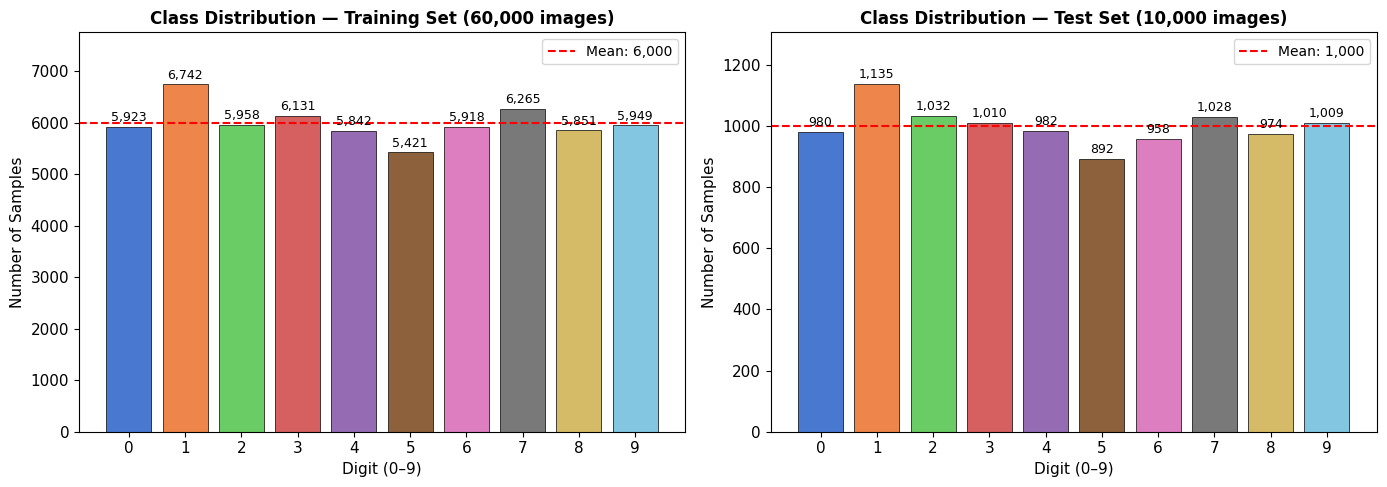


FINDING:
  - Sample count per class ranges from 5,421 to 6,742
  - Max-min difference: 1,321 images
  - Deviation from mean: 22.0%
  => Dataset is WELL-BALANCED. No oversampling or undersampling required.


In [5]:
# Visualize class distribution — Training and Test sets side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("muted", 10)

# --- Plot 1: Training Set ---
bars = axes[0].bar(unique_labels, train_counts, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution — Training Set (60,000 images)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Digit (0–9)', fontsize=11)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_xticks(unique_labels)
axes[0].set_ylim(0, max(train_counts) * 1.15)

for bar, count in zip(bars, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

mean_train = np.mean(train_counts)
axes[0].axhline(y=mean_train, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_train:,.0f}')
axes[0].legend(fontsize=10)

# --- Plot 2: Test Set ---
bars2 = axes[1].bar(unique_labels, test_counts, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Class Distribution — Test Set (10,000 images)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Digit (0–9)', fontsize=11)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].set_xticks(unique_labels)
axes[1].set_ylim(0, max(test_counts) * 1.15)

for bar, count in zip(bars2, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

mean_test = np.mean(test_counts)
axes[1].axhline(y=mean_test, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_test:,.0f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print()
print("FINDING:")
print(f"  - Sample count per class ranges from {min(train_counts):,} to {max(train_counts):,}")
print(f"  - Max-min difference: {max(train_counts) - min(train_counts):,} images")
print(f"  - Deviation from mean: {(max(train_counts)-min(train_counts))/mean_train*100:.1f}%")
print(f"  => Dataset is WELL-BALANCED. No oversampling or undersampling required.")

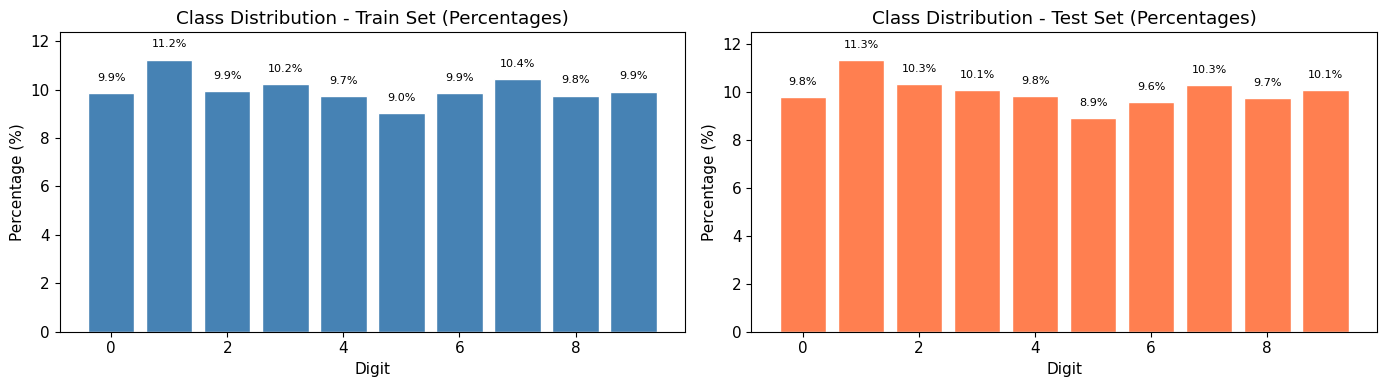

In [6]:
# In percentages
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Train set
counts_train = Counter(y_train)
total_train = sum(counts_train.values())
train_percentages = {k: (v / total_train) * 100 for k, v in counts_train.items()}

axes[0].bar(train_percentages.keys(), train_percentages.values(), color='steelblue', edgecolor='white')
axes[0].set_title("Class Distribution - Train Set (Percentages)")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, max(train_percentages.values()) * 1.1) # Adjust y-limit for better visualization
for k, v in train_percentages.items():
    axes[0].text(k, v + 0.5, f"{v:.1f}%", ha='center', fontsize=8) # Display percentages

# Test set
counts_test = Counter(y_test)
total_test = sum(counts_test.values())
test_percentages = {k: (v / total_test) * 100 for k, v in counts_test.items()}

axes[1].bar(test_percentages.keys(), test_percentages.values(), color='coral', edgecolor='white')
axes[1].set_title("Class Distribution - Test Set (Percentages)")
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Percentage (%)") # Add y-axis label for test set
axes[1].set_ylim(0, max(test_percentages.values()) * 1.1) # Adjust y-limit for better visualization
for k, v in test_percentages.items():
    axes[1].text(k, v + 0.5, f"{v:.1f}%", ha='center', fontsize=8) # Display percentages


plt.tight_layout()
plt.show()

## 1.3 Sample Visualization

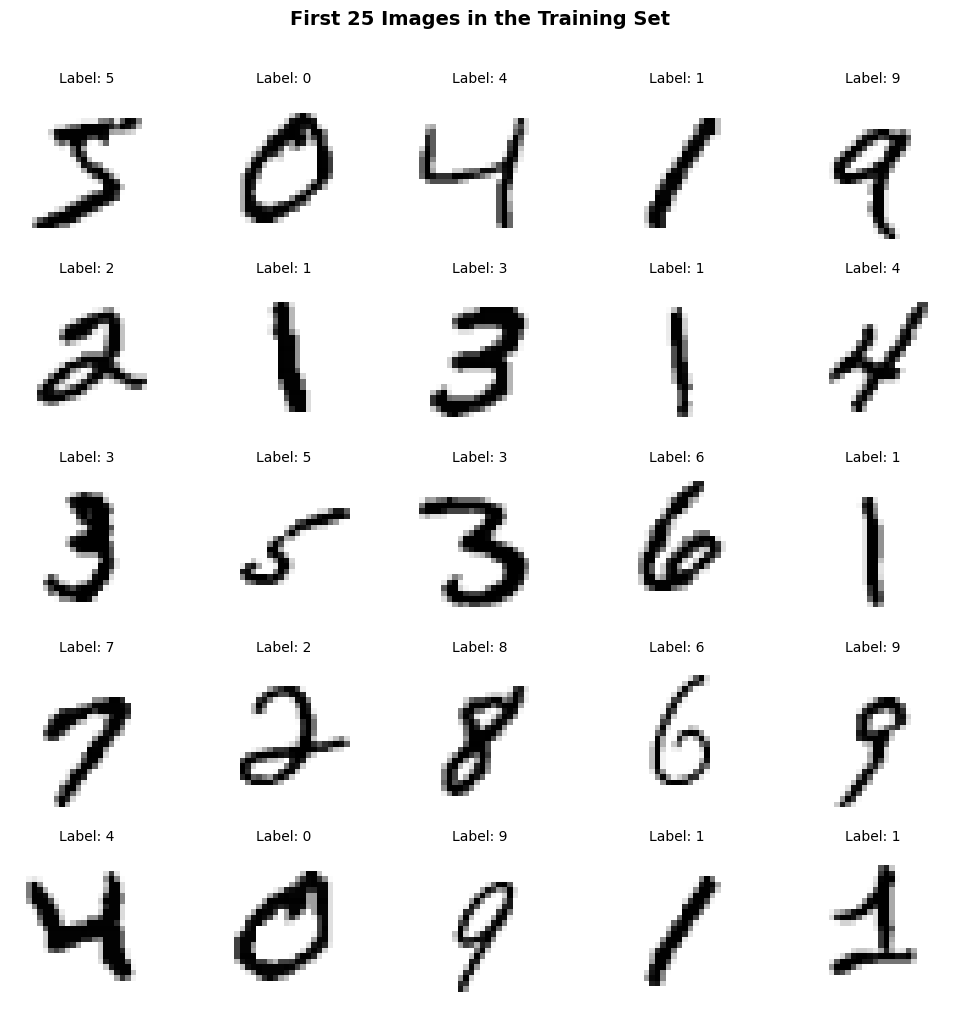

Observation: Digits are written in diverse styles — this is the real-world characteristic of handwritten data.


In [7]:
# Display the first 25 images from the training set in a 5x5 grid

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('First 25 Images in the Training Set', fontsize=14, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='binary')
    ax.set_title(f'Label: {y_train[i]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Observation: Digits are written in diverse styles — this is the real-world characteristic of handwritten data.")

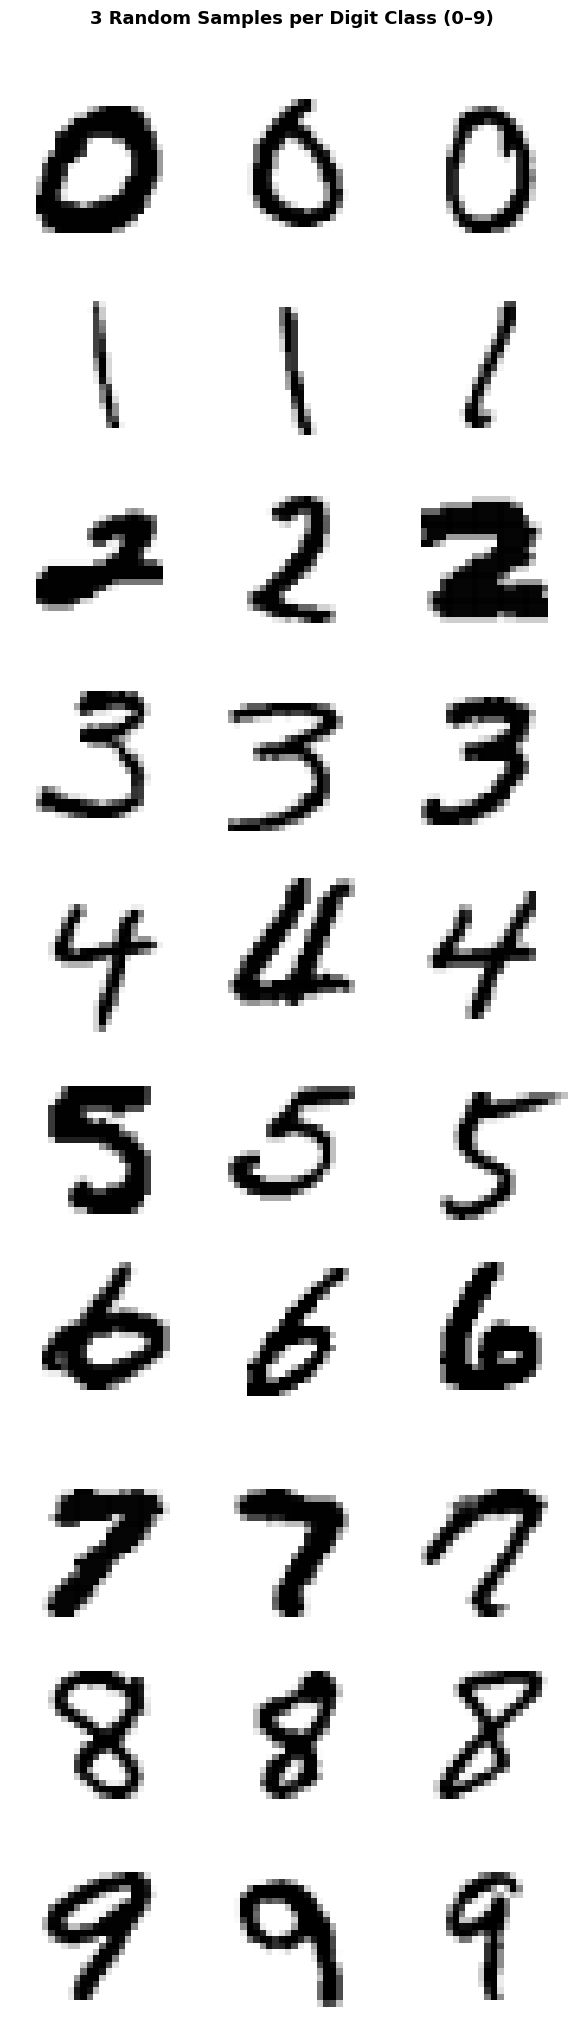

Observation: The same digit can appear in many stroke styles.
=> A good model must learn generalized features, not memorize specific handwriting.


In [8]:
# Display 3 random samples for each digit class (0–9)
# Purpose: visualize intra-class variation

fig, axes = plt.subplots(10, 3, figsize=(6, 20))
fig.suptitle('3 Random Samples per Digit Class (0–9)', fontsize=13, fontweight='bold', y=1.01)

np.random.seed(42)  # Fixed seed for reproducibility

for digit in range(10):
    indices = np.where(y_train == digit)[0]
    sample_indices = np.random.choice(indices, 3, replace=False)

    for col, idx in enumerate(sample_indices):
        axes[digit, col].imshow(X_train[idx], cmap='binary')
        axes[digit, col].axis('off')
        if col == 0:
            axes[digit, col].set_ylabel(f'Digit {digit}', fontsize=11,
                                        rotation=0, labelpad=35, va='center')

plt.tight_layout()
plt.show()
print("Observation: The same digit can appear in many stroke styles.")
print("=> A good model must learn generalized features, not memorize specific handwriting.")

## 1.4 Average Digit Images (Prototypical Shapes)

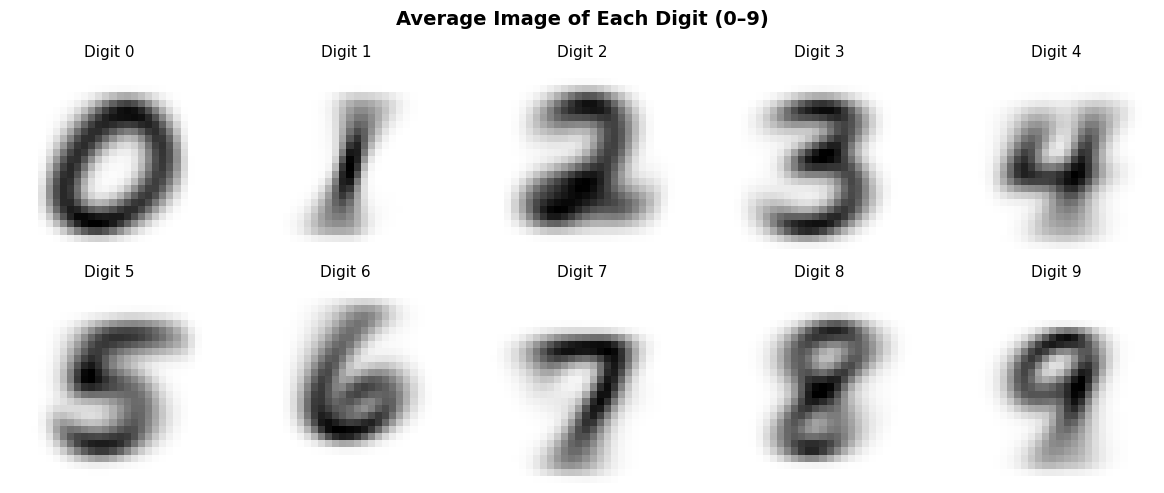

FINDING:
  - Clear, sharp average images indicate low intra-class variation (e.g., digit 1).
  - Blurry/diffuse average images indicate high variation in writing style (e.g., digit 2, 7).
  - Visually similar averages (e.g., 4 vs 9, 3 vs 8) suggest potential confusion points for the model.


In [9]:
# Save the original uint8 array before normalization (used here and in sparsity analysis)
X_train_original = X_train.copy()

# Compute and display the average image for each digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Average Image of Each Digit (0–9)', fontsize=14, fontweight='bold')

for digit in range(10):
    # Compute pixel-wise mean across all images of this digit
    avg_img = X_train_original[y_train == digit].mean(axis=0)  # shape: (28, 28)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(avg_img, cmap='binary')
    ax.set_title(f'Digit {digit}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("FINDING:")
print("  - Clear, sharp average images indicate low intra-class variation (e.g., digit 1).")
print("  - Blurry/diffuse average images indicate high variation in writing style (e.g., digit 2, 7).")
print("  - Visually similar averages (e.g., 4 vs 9, 3 vs 8) suggest potential confusion points for the model.")

## 1.5 Pixel Value Analysis

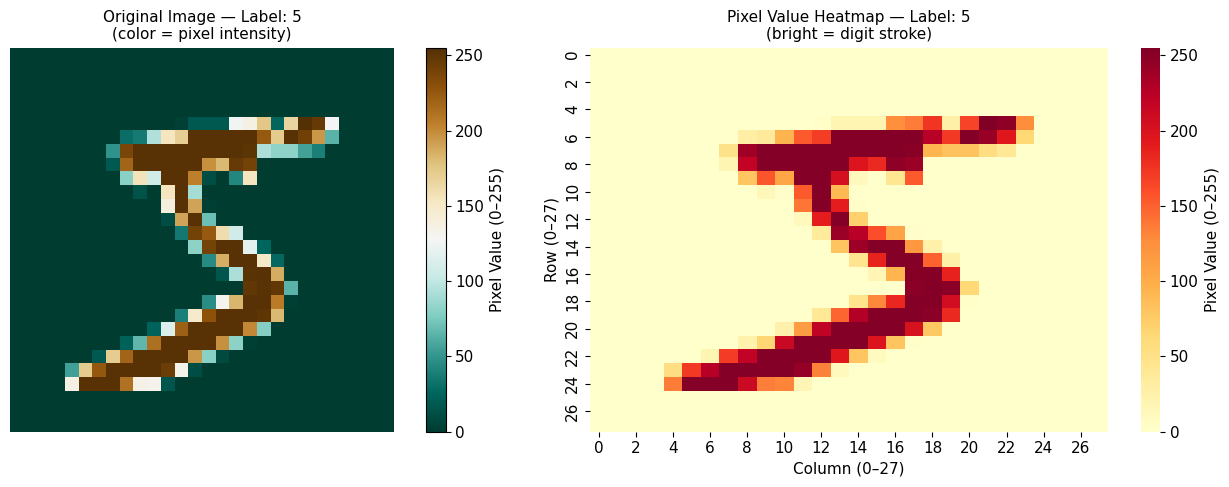

Pixel statistics for image #0 (label = 5):
  Min value       : 0
  Max value       : 255
  Mean            : 35.11
  Std deviation   : 79.65
  % pixels = 0    : 78.8% (background)


In [10]:
# Examine pixel values of the first image in detail

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Image with BrBG_r colormap (highlights stroke vs background contrast)
im1 = axes[0].imshow(X_train_original[0], cmap='BrBG_r')
axes[0].set_title(f'Original Image — Label: {y_train[0]}\n(color = pixel intensity)', fontsize=11)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Pixel Value (0–255)')

# Heatmap of pixel values
sns.heatmap(X_train_original[0], annot=False, cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Pixel Value (0–255)'})
axes[1].set_title(f'Pixel Value Heatmap — Label: {y_train[0]}\n(bright = digit stroke)', fontsize=11)
axes[1].set_xlabel('Column (0–27)')
axes[1].set_ylabel('Row (0–27)')

plt.tight_layout()
plt.show()

print(f"Pixel statistics for image #0 (label = {y_train[0]}):")
print(f"  Min value       : {X_train_original[0].min()}")
print(f"  Max value       : {X_train_original[0].max()}")
print(f"  Mean            : {X_train_original[0].mean():.2f}")
print(f"  Std deviation   : {X_train_original[0].std():.2f}")
print(f"  % pixels = 0    : {(X_train_original[0] == 0).sum() / X_train_original[0].size * 100:.1f}% (background)")

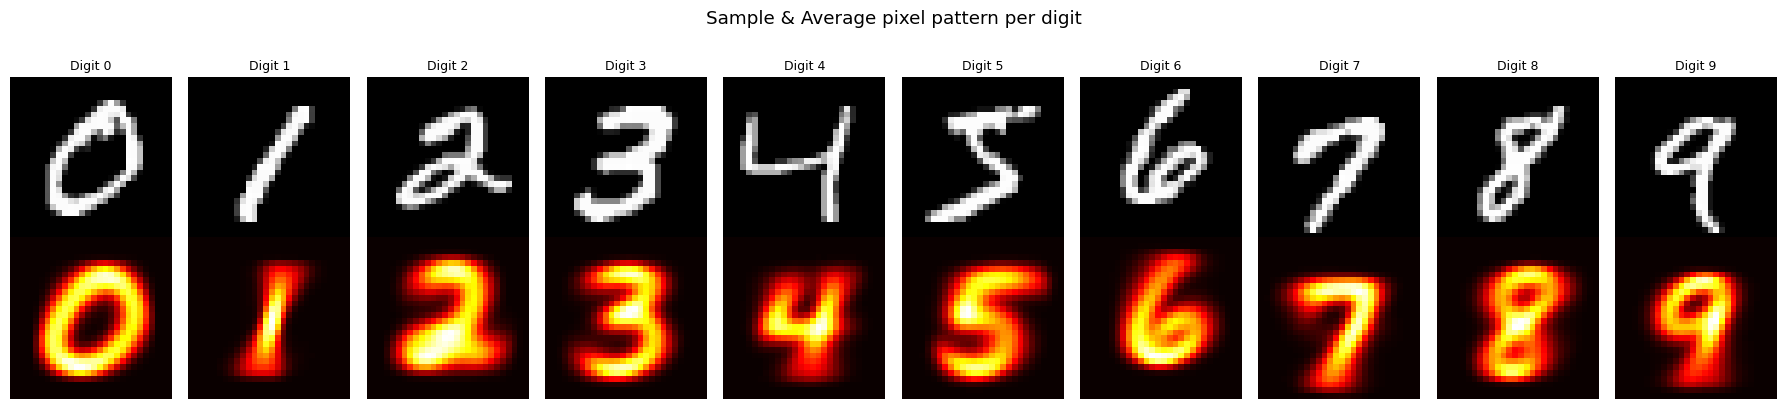

In [11]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))

for digit in range(10):
    idx = np.where(y_train == digit)[0]

    # Row 1: random sample value
    sample = X_train[idx[0]]
    axes[0, digit].imshow(sample, cmap='gray')
    axes[0, digit].set_title(f"Digit {digit}", fontsize=9)
    axes[0, digit].axis('off')

    # Row 2: Pixel mean
    mean_img = X_train[idx].mean(axis=0)
    axes[1, digit].imshow(mean_img, cmap='hot')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel("Sample", fontsize=9)
axes[1, 0].set_ylabel("Mean pixel", fontsize=9)
plt.suptitle("Sample & Average pixel pattern per digit", y=1.02)
plt.tight_layout()
plt.show()

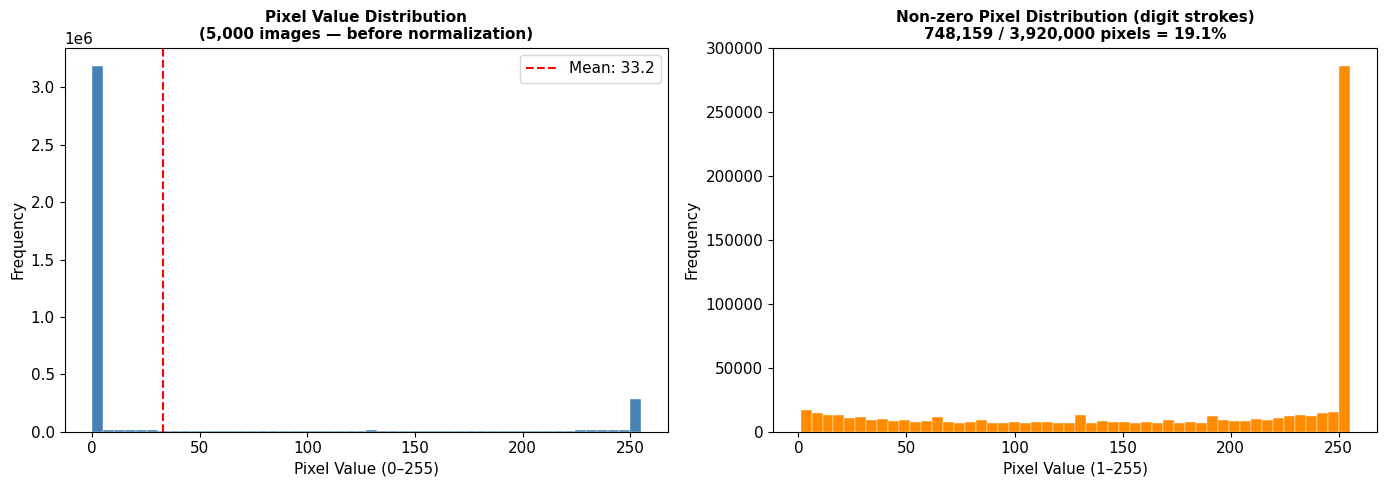

FINDING:
  - Background pixels (= 0): 80.9% of all pixels
  - Digit stroke pixels (> 0): 19.1%
  => Distribution is highly right-skewed — typical for handwritten digit images.
  => Normalization is essential for stable gradient descent.


In [12]:
# Pixel value distribution across 5,000 training images (sampled to avoid memory overload)

sample_pixels = X_train_original[:5000].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: all pixels (including background zeros)
axes[0].hist(sample_pixels, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Pixel Value Distribution\n(5,000 images — before normalization)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=sample_pixels.mean(), color='red', linestyle='--',
                label=f'Mean: {sample_pixels.mean():.1f}')
axes[0].legend()

# Histogram: non-zero pixels only (digit strokes)
nonzero_pixels = sample_pixels[sample_pixels > 0]
axes[1].hist(nonzero_pixels, bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title(
    f'Non-zero Pixel Distribution (digit strokes)\n{len(nonzero_pixels):,} / {len(sample_pixels):,} pixels = {len(nonzero_pixels)/len(sample_pixels)*100:.1f}%',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pixel Value (1–255)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("FINDING:")
print(f"  - Background pixels (= 0): {(sample_pixels==0).sum()/len(sample_pixels)*100:.1f}% of all pixels")
print(f"  - Digit stroke pixels (> 0): {len(nonzero_pixels)/len(sample_pixels)*100:.1f}%")
print(f"  => Distribution is highly right-skewed — typical for handwritten digit images.")
print(f"  => Normalization is essential for stable gradient descent.")

## 1.6 Sparsity Analysis

SPARSITY ANALYSIS
---------------------------------------------
  Mean % background pixels (whole dataset) : 80.9%
  Most sparse image (least ink)            : 95.7% zeros
  Most dense image (most ink)              : 55.2% zeros
  Std deviation across images              : 5.3%
---------------------------------------------


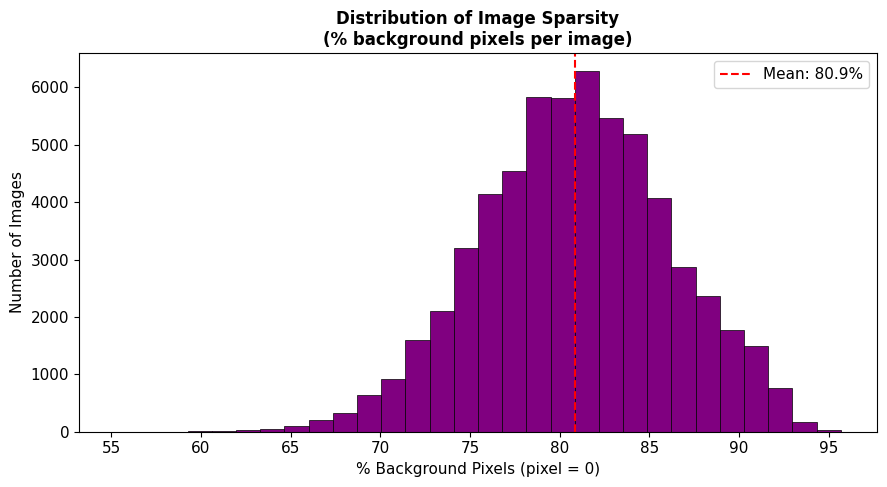


FINDING:
  - On average, 80.9% of each image is pure background.
  => Images are extremely sparse — only a small region contains digit information.
  => This sparsity directly justifies why normalization stabilizes gradient descent,
     and why CNN convolutional filters are effective at extracting localized features.


In [13]:
# Compute per-image sparsity: proportion of zero pixels for each image
# axis=(1,2) means we compute across height and width dimensions, keeping one value per image
zero_ratio = (X_train_original == 0).mean(axis=(1, 2))  # shape: (60000,)

print("SPARSITY ANALYSIS")
print("-" * 45)
print(f"  Mean % background pixels (whole dataset) : {zero_ratio.mean()*100:.1f}%")
print(f"  Most sparse image (least ink)            : {zero_ratio.max()*100:.1f}% zeros")
print(f"  Most dense image (most ink)              : {zero_ratio.min()*100:.1f}% zeros")
print(f"  Std deviation across images              : {zero_ratio.std()*100:.1f}%")
print("-" * 45)

# Distribution of sparsity across all training images
plt.figure(figsize=(9, 5))
plt.hist(zero_ratio * 100, bins=30, color='purple', edgecolor='black', linewidth=0.5)
plt.title('Distribution of Image Sparsity\n(% background pixels per image)', fontsize=12, fontweight='bold')
plt.xlabel('% Background Pixels (pixel = 0)')
plt.ylabel('Number of Images')
plt.axvline(zero_ratio.mean()*100, color='red', linestyle='--',
            label=f'Mean: {zero_ratio.mean()*100:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

print()
print("FINDING:")
print(f"  - On average, {zero_ratio.mean()*100:.1f}% of each image is pure background.")
print(f"  => Images are extremely sparse — only a small region contains digit information.")
print(f"  => This sparsity directly justifies why normalization stabilizes gradient descent,")
print(f"     and why CNN convolutional filters are effective at extracting localized features.")

## 1.7 Row & Column Activity Analysis

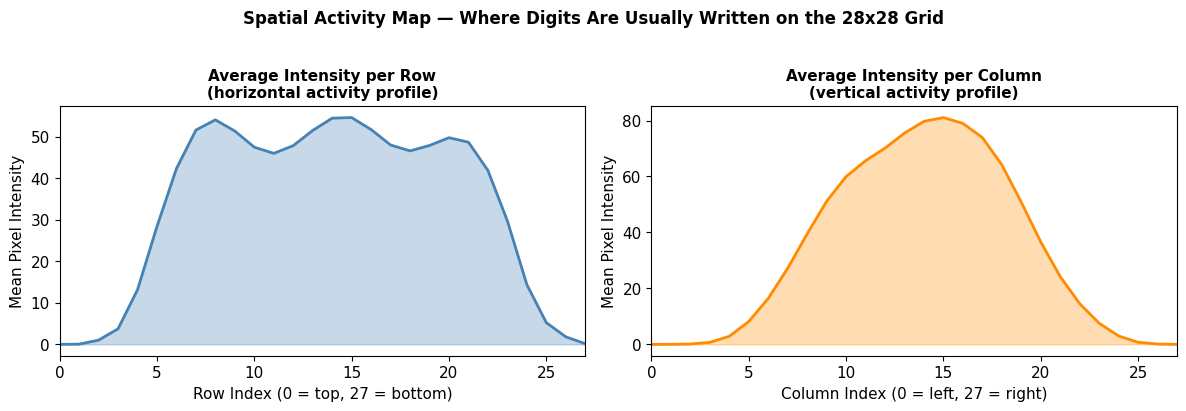

FINDING:
  - Most active row    : row 15 (digits are written in the vertical center)
  - Most active column : col 15 (digits are horizontally centered)
  - Border rows/cols (0–3 and 24–27) show near-zero activity — pure margin/padding.
  => Digits are well-centered on the canvas — no cropping or alignment preprocessing needed.


In [14]:
# Average intensity per row and per column across all training images
# axis=0 collapses the image dimension (60000 images)
# axis=(0,1) then collapses rows -> per-column profile
# axis=(0,2) then collapses columns -> per-row profile

mean_row = X_train_original.mean(axis=(0, 2))  # shape: (28,) — average across all images and columns
mean_col = X_train_original.mean(axis=(0, 1))  # shape: (28,) — average across all images and rows

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Row activity
axes[0].plot(range(28), mean_row, color='steelblue', linewidth=2)
axes[0].fill_between(range(28), mean_row, alpha=0.3, color='steelblue')
axes[0].set_title('Average Intensity per Row\n(horizontal activity profile)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Row Index (0 = top, 27 = bottom)')
axes[0].set_ylabel('Mean Pixel Intensity')
axes[0].set_xlim(0, 27)

# Column activity
axes[1].plot(range(28), mean_col, color='darkorange', linewidth=2)
axes[1].fill_between(range(28), mean_col, alpha=0.3, color='darkorange')
axes[1].set_title('Average Intensity per Column\n(vertical activity profile)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Column Index (0 = left, 27 = right)')
axes[1].set_ylabel('Mean Pixel Intensity')
axes[1].set_xlim(0, 27)

fig.suptitle('Spatial Activity Map — Where Digits Are Usually Written on the 28x28 Grid',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

most_active_row = np.argmax(mean_row)
most_active_col = np.argmax(mean_col)
print("FINDING:")
print(f"  - Most active row    : row {most_active_row} (digits are written in the vertical center)")
print(f"  - Most active column : col {most_active_col} (digits are horizontally centered)")
print(f"  - Border rows/cols (0–3 and 24–27) show near-zero activity — pure margin/padding.")
print(f"  => Digits are well-centered on the canvas — no cropping or alignment preprocessing needed.")

## 1.8 Normalization

In [15]:
# Apply normalization: cast to float32, then divide by 255
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print("Normalization complete!")
print()
print("BEFORE normalization:")
print(f"  Data type  : uint8")
print(f"  Value min  : {X_train_original.min()}")
print(f"  Value max  : {X_train_original.max()}")
print()
print("AFTER normalization:")
print(f"  Data type  : {X_train.dtype}")
print(f"  Value min  : {X_train.min():.4f}")
print(f"  Value max  : {X_train.max():.4f}")
print(f"  Mean       : {X_train.mean():.4f}")
print(f"  Std dev    : {X_train.std():.4f}")

Normalization complete!

BEFORE normalization:
  Data type  : uint8
  Value min  : 0
  Value max  : 255

AFTER normalization:
  Data type  : float32
  Value min  : 0.0000
  Value max  : 1.0000
  Mean       : 0.1307
  Std dev    : 0.3081


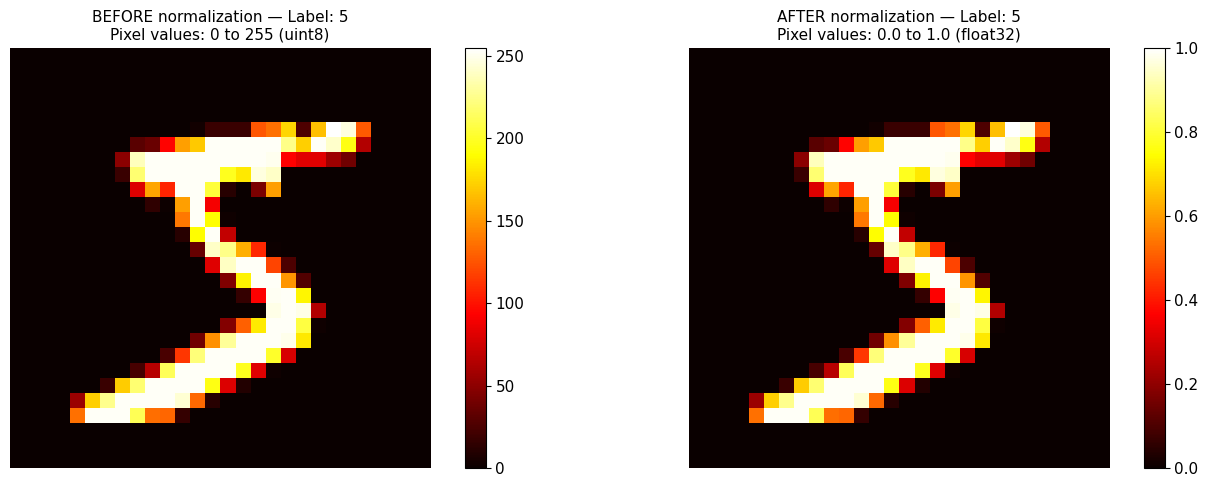

Note: Images look identical because normalization only rescales the numerical range.
      No visual information is changed — only the number scale is adjusted.

Sample normalized pixel values (rows 10–17, cols 10–17 — stroke region):
0.004 0.604 0.992 0.353 0.000 0.000 0.000 
0.000 0.545 0.992 0.745 0.008 0.000 0.000 
0.000 0.043 0.745 0.992 0.275 0.000 0.000 
0.000 0.000 0.137 0.945 0.882 0.627 0.424 
0.000 0.000 0.000 0.318 0.941 0.992 0.992 
0.000 0.000 0.000 0.000 0.176 0.729 0.992 
0.000 0.000 0.000 0.000 0.000 0.063 0.365 


In [16]:
# Visual comparison: before vs after normalization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(X_train_original[0], cmap='hot')
axes[0].set_title(f'BEFORE normalization — Label: {y_train[0]}\nPixel values: 0 to 255 (uint8)', fontsize=11)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(X_train[0], cmap='hot')
axes[1].set_title(f'AFTER normalization — Label: {y_train[0]}\nPixel values: 0.0 to 1.0 (float32)', fontsize=11)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()
print("Note: Images look identical because normalization only rescales the numerical range.")
print("      No visual information is changed — only the number scale is adjusted.")

# Show sample normalized pixel values (rows 10–17, cols 10–17 — where stroke is)
print()
print("Sample normalized pixel values (rows 10–17, cols 10–17 — stroke region):")
for row in X_train[0][10:17]:
    for pixel in row[10:17]:
        print("{:0.3f}".format(pixel), end=" ")
    print()

## 1.9 Reshape & Flatten

In [17]:
print("BEFORE reshape/flatten:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape : {X_test.shape}")
print()

# --- For CNN ---
# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], 28, 28, 1)

# --- For traditional ML (KNN, SVM, Random Forest) ---
# Flatten: (N, 28, 28) -> (N, 784)
# Using -1 lets numpy auto-calculate the second dimension (28*28 = 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("AFTER reshape/flatten:")
print("-" * 58)
print(f"  {'Format':<28} {'Train shape':<18} {'Test shape'}")
print("-" * 58)
print(f"  {'CNN — 4D tensor':<28} {str(X_train_cnn.shape):<18} {str(X_test_cnn.shape)}")
print(f"  {'ML models — 2D matrix':<28} {str(X_train_flat.shape):<18} {str(X_test_flat.shape)}")
print("-" * 58)
print()
print(f"Verification: 28 x 28 x 1 = {28*28*1} features — matches dim 2 of X_train_flat")
print(f"Normalization preserved: X_train_flat min={X_train_flat.min():.1f}, max={X_train_flat.max():.1f}")

BEFORE reshape/flatten:
  X_train shape: (60000, 28, 28)
  X_test shape : (10000, 28, 28)

AFTER reshape/flatten:
----------------------------------------------------------
  Format                       Train shape        Test shape
----------------------------------------------------------
  CNN — 4D tensor              (60000, 28, 28, 1) (10000, 28, 28, 1)
  ML models — 2D matrix        (60000, 784)       (10000, 784)
----------------------------------------------------------

Verification: 28 x 28 x 1 = 784 features — matches dim 2 of X_train_flat
Normalization preserved: X_train_flat min=0.0, max=1.0


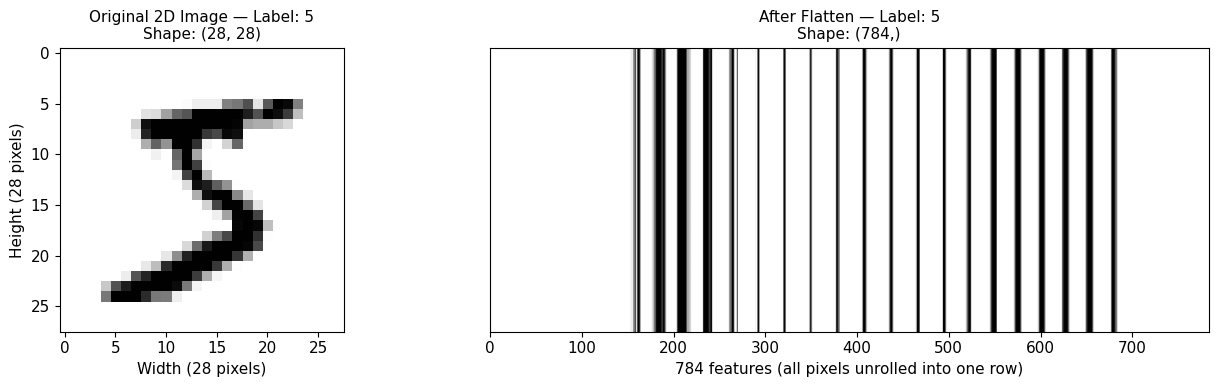

Note: Image information is fully preserved — only the data organization changes.
      KNN, SVM, and Random Forest will receive X_train_flat and X_test_flat as input.


In [18]:
# Visual illustration: original 2D image vs flattened 1D vector

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original 2D image
axes[0].imshow(X_train[0].reshape(28, 28), cmap='binary')
axes[0].set_title(f'Original 2D Image — Label: {y_train[0]}\nShape: (28, 28)', fontsize=11)
axes[0].set_xlabel('Width (28 pixels)')
axes[0].set_ylabel('Height (28 pixels)')

# Flattened 1D vector shown as a single-row heatmap
axes[1].imshow(X_train_flat[0].reshape(1, 784), cmap='binary', aspect='auto')
axes[1].set_title(f'After Flatten — Label: {y_train[0]}\nShape: (784,)', fontsize=11)
axes[1].set_xlabel('784 features (all pixels unrolled into one row)')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print("Note: Image information is fully preserved — only the data organization changes.")
print("      KNN, SVM, and Random Forest will receive X_train_flat and X_test_flat as input.")

**Data flow summary:**

```
Raw data: uint8, values 0–255, shape (N, 28, 28)
                    |
              Normalization
           float32, values 0.0–1.0
                    |
          __________|__________
         |                     |
       Reshape               Flatten
    (N, 28, 28, 1)           (N, 784)
         |                     |
        CNN             KNN / SVM / Random Forest

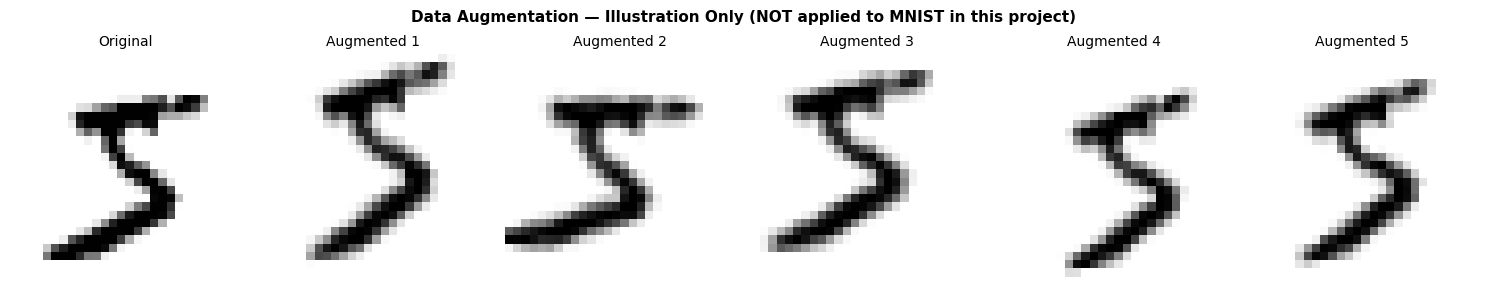

Conclusion: Augmentation is NOT applied.
  Reason: MNIST is already large, balanced, and achieves high accuracy without it.


In [19]:
# ILLUSTRATION ONLY — Data Augmentation is NOT applied to the actual training data

datagen_demo = ImageDataGenerator(
    rotation_range=10,       # Rotate image by up to ±10 degrees
    zoom_range=0.1,          # Zoom in/out by up to 10%
    width_shift_range=0.1,   # Shift horizontally by up to 10%
    height_shift_range=0.1   # Shift vertically by up to 10%
)

sample_img = X_train_cnn[0].reshape(1, 28, 28, 1)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(X_train_cnn[0].reshape(28, 28), cmap='binary')
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

gen = datagen_demo.flow(sample_img, batch_size=1)
for i in range(1, 6):
    aug_img = next(gen)[0].reshape(28, 28)
    axes[i].imshow(aug_img, cmap='binary')
    axes[i].set_title(f'Augmented {i}', fontsize=10)
    axes[i].axis('off')

fig.suptitle('Data Augmentation — Illustration Only (NOT applied to MNIST in this project)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Conclusion: Augmentation is NOT applied.")
print("  Reason: MNIST is already large, balanced, and achieves high accuracy without it.")

## 1.10 Phase Summary

In [20]:
print("[1] DATASET")
print(f"    Source         : MNIST (keras.datasets.mnist)")
print(f"    Training set   : {X_train_cnn.shape[0]:,} images")
print(f"    Test set       : {X_test_cnn.shape[0]:,} images")
print(f"    Image size     : 28 x 28 pixels, grayscale")
print(f"    Classes        : 10 (digits 0–9)")
print()
print("[2] EDA FINDINGS")
print(f"    Class balance  : BALANCED (~6,000 samples per class)")
print(f"    Avg sparsity   : ~{(X_train_original==0).mean()*100:.0f}% background pixels per image")
print(f"    Spatial layout : Digits centered; border rows/cols are inactive margins")
print(f"    Intra-class    : Visible variation in stroke style — model must generalize")
print()
print("[3] PREPROCESSING APPLIED")
print(f"    Normalization  : ÷ 255.0  =>  pixel values in [0.0, 1.0]")
print(f"    Data type      : uint8  =>  float32")
print(f"    Reshape (CNN)  : (N,28,28)  =>  (N,28,28,1)  [add channel dim]")
print(f"    Flatten (ML)   : (N,28,28)  =>  (N,784)      [unroll to vector]")
print(f"    Augmentation   : NOT applied (dataset is already large and balanced)")
print()
print("[4] OUTPUT VARIABLES FOR PHASE II")
print(f"    --- For CNN (TensorFlow/Keras) ---")
print(f"    X_train_cnn  : shape={X_train_cnn.shape},  dtype={X_train_cnn.dtype}")
print(f"    X_test_cnn   : shape={X_test_cnn.shape},   dtype={X_test_cnn.dtype}")
print(f"    --- For KNN / SVM / Random Forest (sklearn) ---")
print(f"    X_train_flat : shape={X_train_flat.shape}, dtype={X_train_flat.dtype}")
print(f"    X_test_flat  : shape={X_test_flat.shape},  dtype={X_test_flat.dtype}")
print(f"    --- Labels (shared across all models) ---")
print(f"    y_train      : shape={y_train.shape}")
print(f"    y_test       : shape={y_test.shape}")

[1] DATASET
    Source         : MNIST (keras.datasets.mnist)
    Training set   : 60,000 images
    Test set       : 10,000 images
    Image size     : 28 x 28 pixels, grayscale
    Classes        : 10 (digits 0–9)

[2] EDA FINDINGS
    Class balance  : BALANCED (~6,000 samples per class)
    Avg sparsity   : ~81% background pixels per image
    Spatial layout : Digits centered; border rows/cols are inactive margins
    Intra-class    : Visible variation in stroke style — model must generalize

[3] PREPROCESSING APPLIED
    Normalization  : ÷ 255.0  =>  pixel values in [0.0, 1.0]
    Data type      : uint8  =>  float32
    Reshape (CNN)  : (N,28,28)  =>  (N,28,28,1)  [add channel dim]
    Flatten (ML)   : (N,28,28)  =>  (N,784)      [unroll to vector]
    Augmentation   : NOT applied (dataset is already large and balanced)

[4] OUTPUT VARIABLES FOR PHASE II
    --- For CNN (TensorFlow/Keras) ---
    X_train_cnn  : shape=(60000, 28, 28, 1),  dtype=float32
    X_test_cnn   : shape=(1000

# 2. Machine Learning Models

## 2.1 PCA for Speeding up SVM and Learning Curves

In [21]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=3):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(.1, 1.0, 5), scoring='accuracy'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

## 2.2 KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

# Setting up
N_TRAIN = 60000
X_knn_train = X_train_flat[:N_TRAIN]
y_knn_train = y_train[:N_TRAIN]

# Train
knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
t0 = time.time()
knn.fit(X_knn_train, y_knn_train)
train_time = time.time() - t0

# Evaluate
t0 = time.time()
y_pred_knn = knn.predict(X_test_flat)
infer_time = time.time() - t0

acc = accuracy_score(y_test, y_pred_knn)
f1  = f1_score(y_test, y_pred_knn, average='weighted')

print(f"KNN Accuracy: {acc:.4f}")
print(f"KNN F1 Score: {f1:.4f}")
print(f"Train time  : {train_time:.2f}s")
print(f"Infer time  : {infer_time:.2f}s")

KNN Accuracy: 0.9705
KNN F1 Score: 0.9705
Train time  : 0.03s
Infer time  : 38.21s


## 2.3 SVM

In [23]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import time

# SVM với Regularization chặt hơn (C=0.5)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=0.5, gamma='scale', random_state=42))
])

N_TRAIN = 60000
X_svm_train = X_train_flat[:N_TRAIN]
y_svm_train = y_train[:N_TRAIN]

# Train
t0 = time.time()
svm_pipeline.fit(X_svm_train, y_svm_train)
train_time = time.time() - t0

# Evaluate
t0 = time.time()
y_pred_svm = svm_pipeline.predict(X_test_flat)
infer_time = time.time() - t0

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')

print(f"SVM Accuracy : {acc_svm:.4f}")
print(f"SVM F1 Score : {f1_svm:.4f}")
print(f"Train time   : {train_time:.2f}s")
print(f"Infer time   : {infer_time:.2f}s")

SVM Accuracy : 0.9596
SVM F1 Score : 0.9596
Train time   : 411.42s
Infer time   : 146.91s


## 2.4 Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
import time

# RF config
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

N_TRAIN = 60000
X_rf_train = X_train_flat[:N_TRAIN]
y_rf_train = y_train[:N_TRAIN]

# Train
t0 = time.time()
rf.fit(X_rf_train, y_rf_train)
train_time = time.time() - t0

# Evaluate
t0 = time.time()
y_pred_rf = rf.predict(X_test_flat)
infer_time = time.time() - t0

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"RF Accuracy : {acc_rf:.4f}")
print(f"RF F1 Score : {f1_rf:.4f}")
print(f"Train time  : {train_time:.2f}s")
print(f"Infer time  : {infer_time:.2f}s")

RF Accuracy : 0.9477
RF F1 Score : 0.9477
Train time  : 21.19s
Infer time  : 0.23s


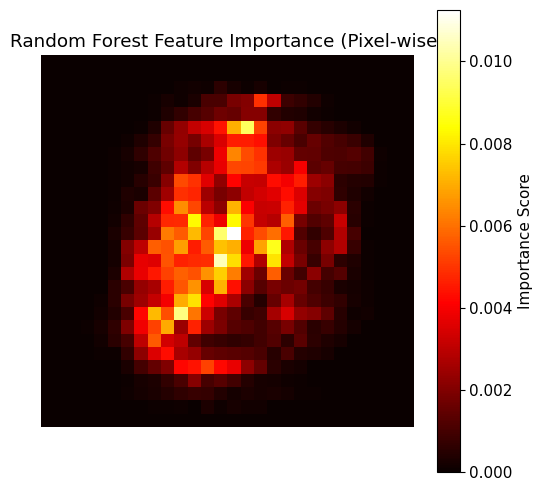

Saved: rf_feature_importance.png


In [25]:
importances = rf.feature_importances_
importances_img = importances.reshape(28, 28)

plt.figure(figsize=(6, 6))
plt.imshow(importances_img, cmap='hot')
plt.title("Random Forest Feature Importance (Pixel-wise)")
plt.colorbar(label='Importance Score')
plt.axis('off')

# Lưu ảnh Feature Importance
plt.savefig("rf_feature_importance.png")
plt.show()
print("Saved: rf_feature_importance.png")

## 2.5 Comparison

### 2.5.1 Confusion Matrix

,Accuracy,F1 Score (Weighted)
KNN,0.9705,0.970452
SVM,0.9596,0.959619
RF,0.9477,0.947686


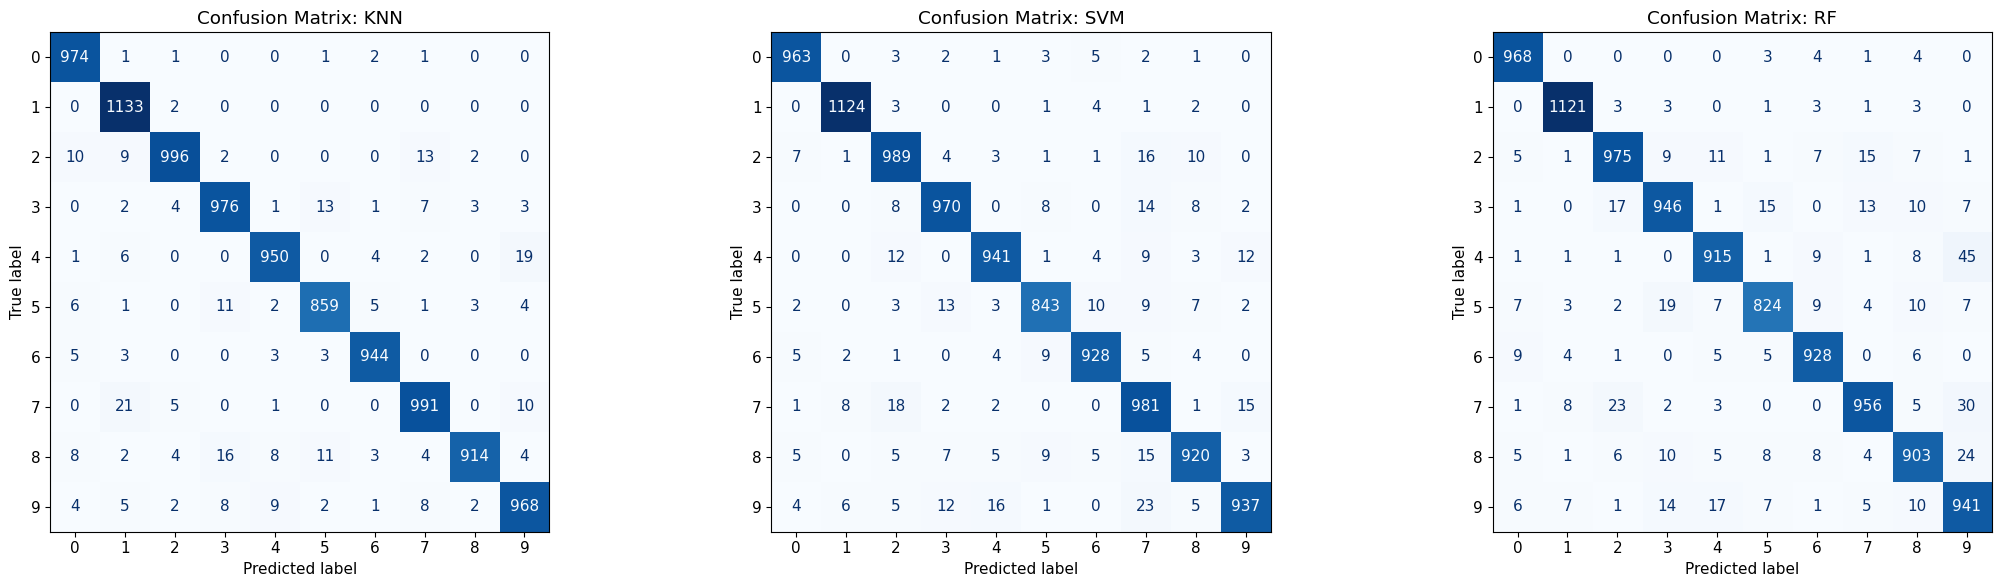

In [26]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

# Kết quả
final_results = {
    "KNN":      {"acc": accuracy_score(y_test, y_pred_knn),
                 "f1":  f1_score(y_test, y_pred_knn, average='weighted'),
                 "y_pred": y_pred_knn},
    "SVM":      {"acc": accuracy_score(y_test, y_pred_svm),
                  "f1":  f1_score(y_test, y_pred_svm, average='weighted'),
                  "y_pred": y_pred_svm},
    "RF" :      {"acc": accuracy_score(y_test, y_pred_rf),
                  "f1":  f1_score(y_test, y_pred_rf, average='weighted'),
                  "y_pred": y_pred_rf},
}

# Hiển thị bảng so sánh
df_compare = pd.DataFrame(final_results).T[['acc', 'f1']]
df_compare.columns = ['Accuracy', 'F1 Score (Weighted)']
display(df_compare)

# Vẽ Confusion Matrix so sánh giữa 3 mô hình
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for i, (name, m) in enumerate(final_results.items()):
    cm = confusion_matrix(y_test, m['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

### 2.5.2 Learning Curves

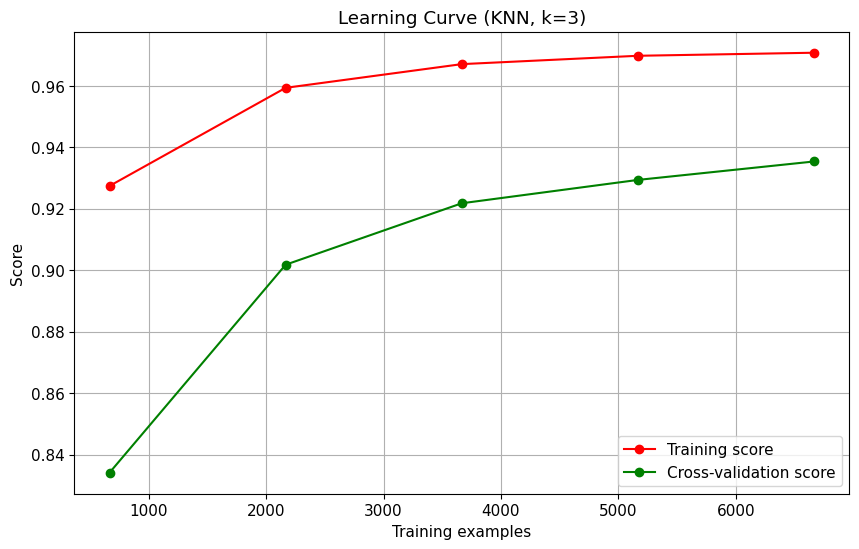

In [27]:
# Sử dụng tập con 10,000 mẫu để vẽ cho nhanh
SUBSET_SIZE = 10000
X_lc = X_train_flat[:SUBSET_SIZE]
y_lc = y_train[:SUBSET_SIZE]

# 1. Learning Curve cho KNN
plot_learning_curve(knn, "Learning Curve (KNN, k=3)", X_lc, y_lc)

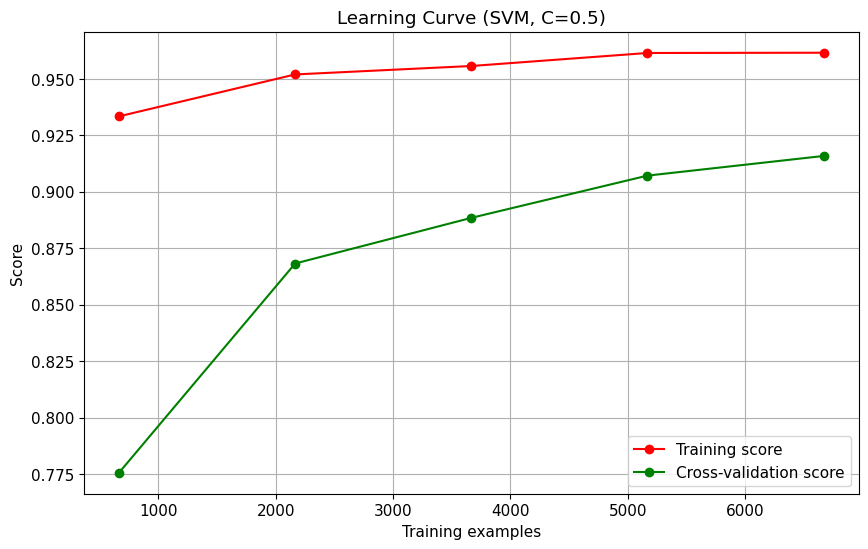

In [28]:
# 2. Learning Curve cho SVM (Đã giảm C=0.5 để bớt Overfit)
svm_regularized = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=0.5, gamma='scale', random_state=42))
])

plot_learning_curve(svm_regularized, "Learning Curve (SVM, C=0.5)", X_lc, y_lc)

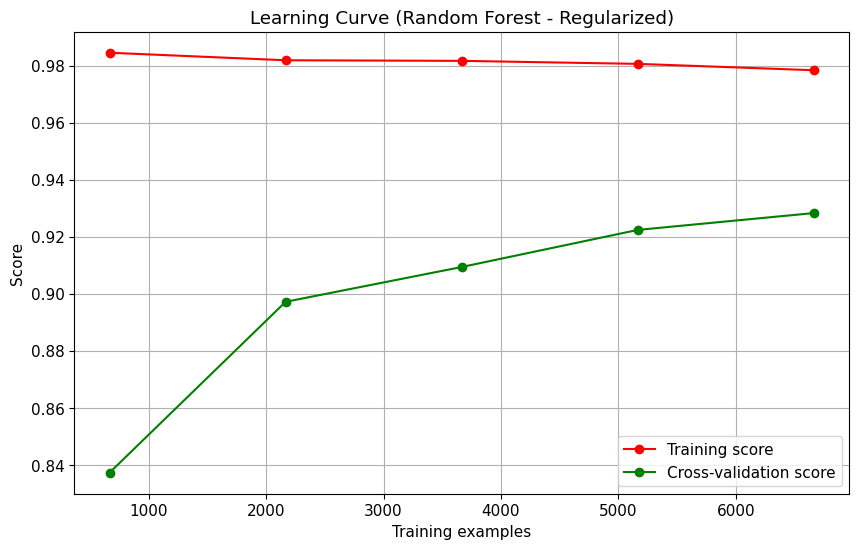

In [29]:
# 3. Learning Curve cho RF
rf_regularized = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

plot_learning_curve(rf_regularized, "Learning Curve (Random Forest - Regularized)", X_lc, y_lc)

# 3. Deep Learning Models

## 3.1 MLP - Multilayer Perceptron

### 3.1.1 Model Training

In [30]:
def build_pure_mlp():
    model = models.Sequential([
        layers.Input(shape=(784,), name="mlp_input"),
        layers.Dense(128, activation='relu', name="mlp_hidden_layer"),
        layers.Dense(10, activation='softmax', name="mlp_output_layer")
    ], name="Baseline_MLP_Rebuilt")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_pure_mlp()
mlp_model.summary()

Model: "Baseline_MLP_Rebuilt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mlp_hidden_layer (Dense)        │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_output_layer (Dense)        │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_mlp = mlp_model.fit(
    X_train_flat, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9103 - loss: 0.3206 - val_accuracy: 0.9562 - val_loss: 0.1505
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9555 - loss: 0.1523 - val_accuracy: 0.9688 - val_loss: 0.1096
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9689 - loss: 0.1065 - val_accuracy: 0.9720 - val_loss: 0.0935
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9767 - loss: 0.0800 - val_accuracy: 0.9743 - val_loss: 0.0864
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9821 - loss: 0.0623 - val_accuracy: 0.9755 - val_loss: 0.0834
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9863 - loss: 0.0493 - val_accuracy: 0.9763 - val_loss: 0.0813
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9899 - loss: 0.0391 - val_accuracy: 0.9792 - val_loss: 0.0812
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9922 - loss: 0.0309 - val_accuracy: 0.

### 3.1.2 Visualization

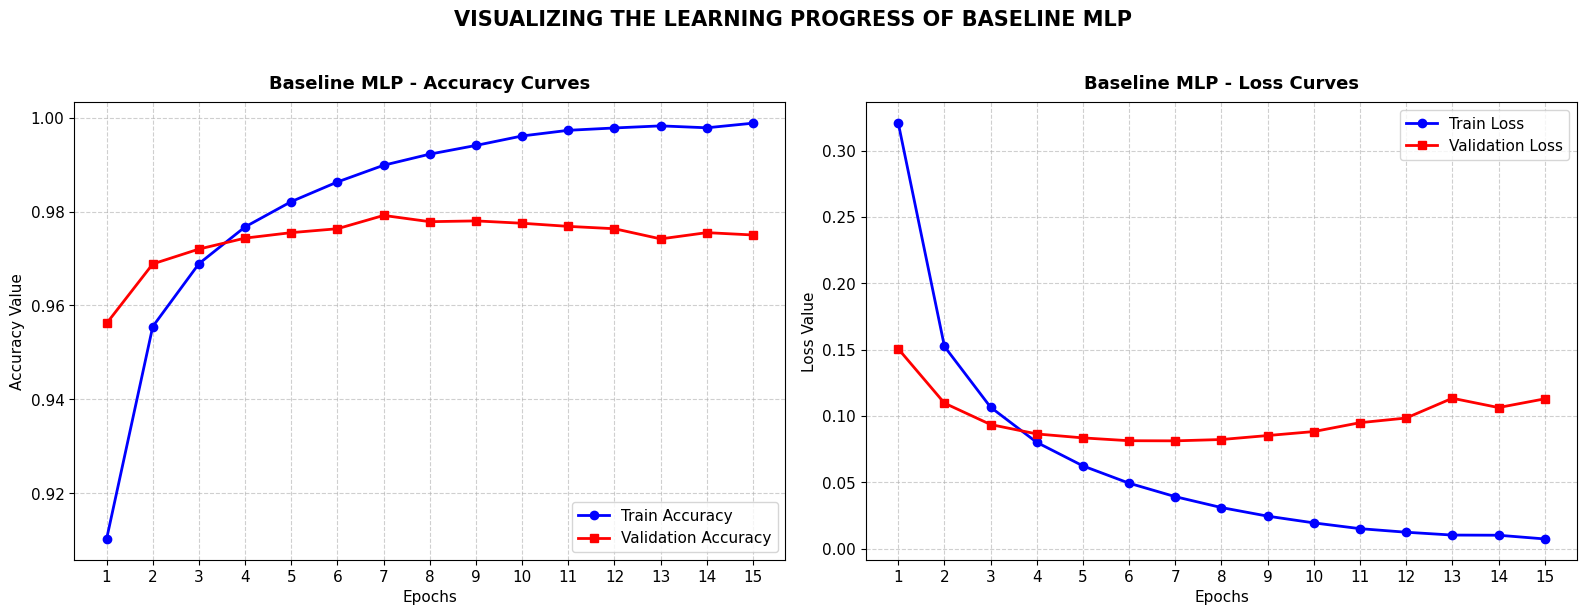

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(history_mlp.history['accuracy']) + 1)

# Accuracy graph
ax1.plot(epochs_range, history_mlp.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(epochs_range, history_mlp.history['val_accuracy'], 'r-s', label='Validation Accuracy', linewidth=2)
ax1.set_title('Baseline MLP - Accuracy Curves', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy Value')
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower right')

# Loss graph
ax2.plot(epochs_range, history_mlp.history['loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(epochs_range, history_mlp.history['val_loss'], 'r-s', label='Validation Loss', linewidth=2)
ax2.set_title('Baseline MLP - Loss Curves', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Value')
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.suptitle("VISUALIZING THE LEARNING PROGRESS OF BASELINE MLP", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

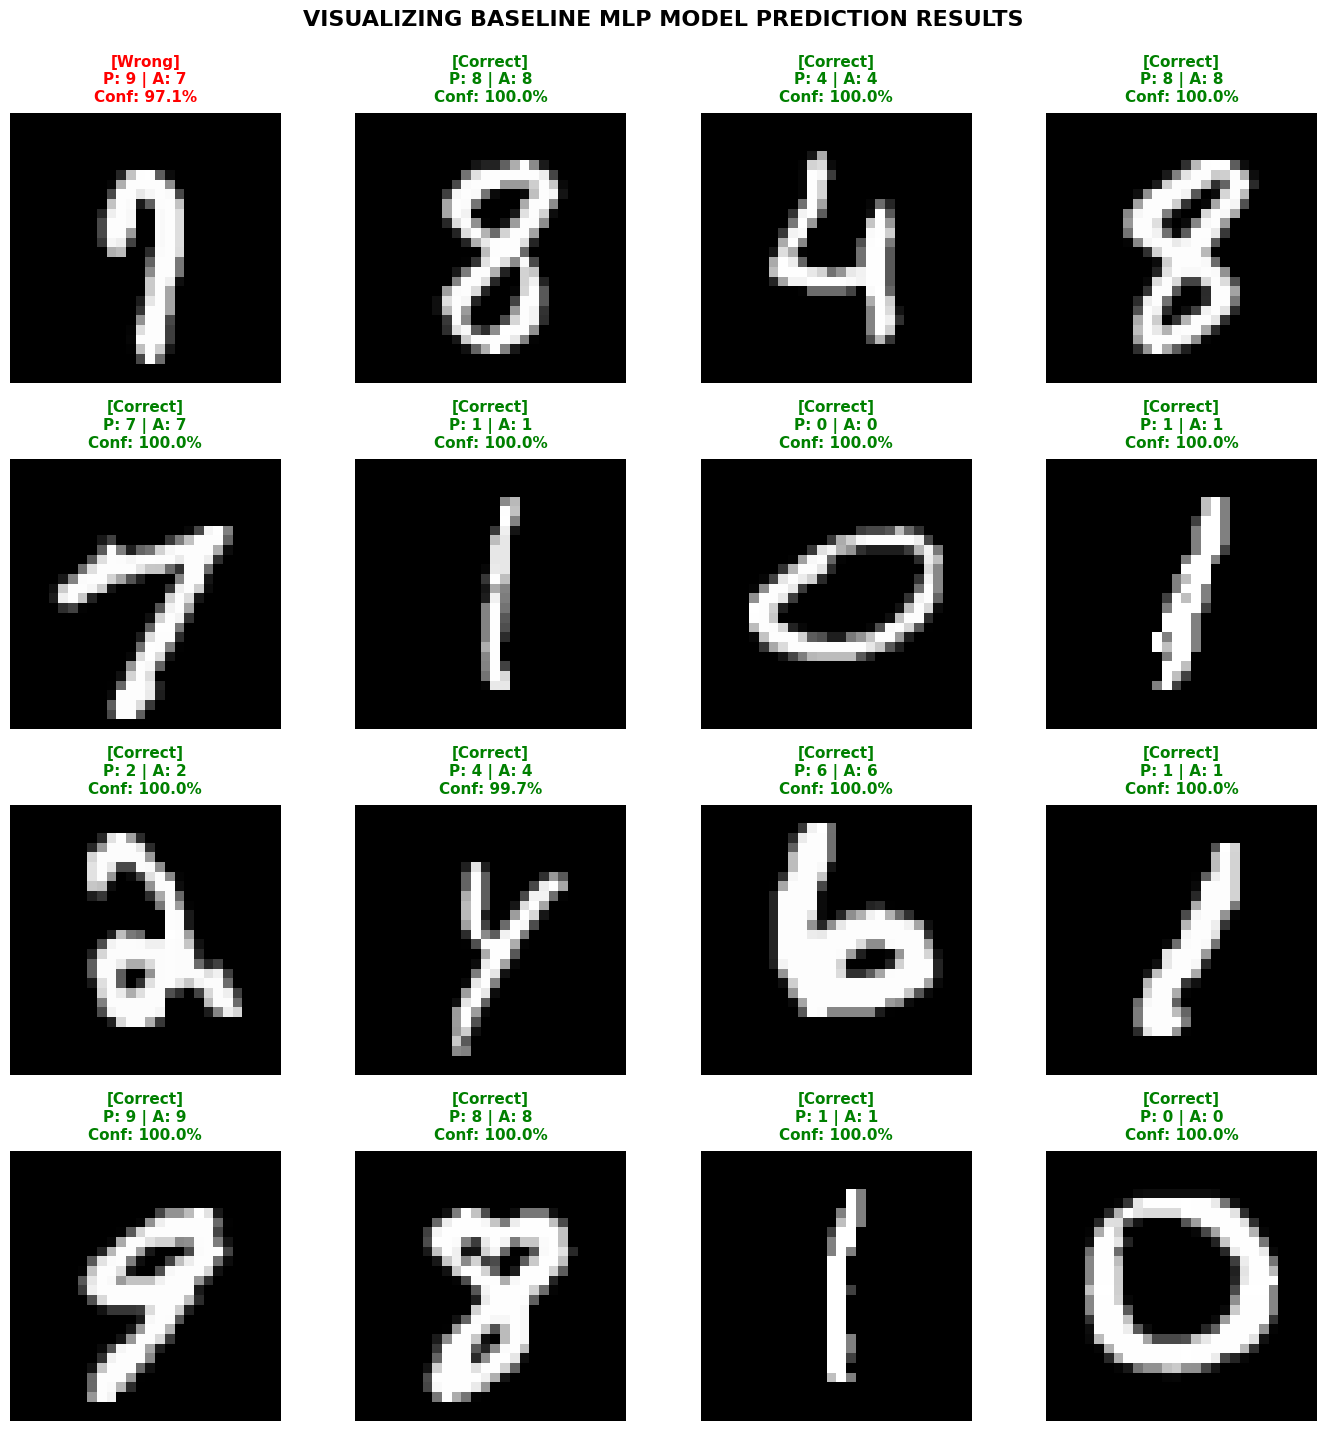

In [33]:
def plot_predictions_mlp(X_test_flat_images, y_true, y_pred, y_probs, num_rows=4, num_cols=4):

    total_images = len(X_test_flat_images)
    random_indices = np.random.choice(total_images, size=(num_rows * num_cols), replace=False)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(14, 14))
    axes = axes.ravel()

    for i, idx in enumerate(random_indices):
        #Restore the 784 vector to a 2D 28x28 matrix to display the original grayscale image
        img = X_test_flat_images[idx].reshape(28, 28)
        actual_label = y_true[idx]
        predicted_label = y_pred[idx]

        # Get the maximum confident probability
        confidence = np.max(y_probs[idx]) * 100

        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')

        # Dynamic title color change logic
        if predicted_label == actual_label:
            title_color = 'green'
            status_text = "Correct"
        else:
            title_color = 'red'
            status_text = "Wrong"

        title_string = f"[{status_text}]\nP: {predicted_label} | A: {actual_label}\nConf: {confidence:.1f}%"
        axes[i].set_title(title_string, color=title_color, fontsize=11, fontweight='bold', pad=8)

    plt.tight_layout()
    plt.suptitle("VISUALIZING BASELINE MLP MODEL PREDICTION RESULTS", fontsize=16, fontweight='bold', y=1.02)
    plt.show()

y_pred_probs_mlp = mlp_model.predict(X_test_flat, verbose=0)
y_pred_mlp = np.argmax(y_pred_probs_mlp, axis=1)


plot_predictions_mlp(X_test_flat, y_test, y_pred_mlp, y_pred_probs_mlp)

mlp_model.save('baseline_mnist_mlp.keras')


### 3.1.3 Parameter Tuning with Optuna

In [34]:
from sklearn.model_selection import train_test_split

(X_train_raw2, y_train_raw2), (X_test_raw2, y_test_raw2) = tf.keras.datasets.mnist.load_data()

X_all2 = np.concatenate((X_train_raw2, X_test_raw2), axis=0)
y_all2 = np.concatenate((y_train_raw2, y_test_raw2), axis=0)

X_all_norm2 = X_all2.astype('float32') / 255.0

X_train_val_raw2, X_test_raw_final2, y_train_val2, y_test2 = train_test_split(
    X_all_norm2, y_all2, test_size=0.10, random_state=42, stratify=y_all2
)

X_train_raw_final2, X_val_raw_final2, y_train2, y_val2 = train_test_split(
    X_train_val_raw2, y_train_val2, test_size=(1/9), random_state=42, stratify=y_train_val2
)


X_train_flat2 = X_train_raw_final2.reshape(-1, 784)
X_val_flat2 = X_val_raw_final2.reshape(-1, 784)
X_test_flat2 = X_test_raw_final2.reshape(-1, 784)

X_train_cnn2 = X_train_raw_final2.reshape(-1, 28, 28, 1)
X_val_cnn2 = X_val_raw_final2.reshape(-1, 28, 28, 1)
X_test_cnn2 = X_test_raw_final2.reshape(-1, 28, 28, 1)

In [35]:
import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def objective_mlp(trial):
    """
    Optuna objective function for tuning MLP hyperparameters.
    Perfectly synchronized with the CNN's structural design and search space.
    """
    # 1. Hyperparameter search space (Identical to your CNN setup)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_units_1 = trial.suggest_categorical('num_filters', [32, 64]) # Mapping filter count to hidden units
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # 2. Model Architecture - Synchronized with Batch Normalization
    model = models.Sequential([
        layers.Input(shape=(784,), name="mlp_input_layer"),

        # MLP Block 1 (Mirrors Conv Block 1)
        layers.Dense(units=num_units_1),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # MLP Block 2 (Mirrors Conv Block 2 & Fully Connected Layer)
        layers.Dense(units=128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(rate=dropout_rate),

        # Output Layer
        layers.Dense(10, activation='softmax', name="mlp_output_layer")
    ], name="Baseline_MLP_Synchronized")

    # 3. Compile Model with matching Adam configuration
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 4. Train Model using your 3-split validation set (or validation_split=0.1)
    history = model.fit(
        X_train_flat2, y_train2,
        epochs=3,
        batch_size=b_size,
        validation_data=(X_val_flat2, y_val2), # Clean split to prevent test data leakage
        verbose=0
    )

    return max(history.history['val_accuracy'])

# --- Initialize and Execute Optuna Study for MLP ---
study_mlp = optuna.create_study(direction='maximize')
print("--- Starting Hyperparameter Optimization for MLP with Optuna (5 Trials) ---")
study_mlp.optimize(objective_mlp, n_trials=5)

# Print optimization results
print("\nOPTUNA MLP OPTIMIZATION RESULTS ")
print(f"Best MLP Validation Accuracy: {study_mlp.best_value:.4f}")
print("Best MLP Hyperparameters:")
for key, value in study_mlp.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-19 09:28:59,544] A new study created in memory with name: no-name-1f1aae3e-4bde-48ce-b3d5-adec7cc4baff


--- Starting Hyperparameter Optimization for MLP with Optuna (5 Trials) ---


[I 2026-06-19 09:29:10,695] Trial 0 finished with value: 0.9584285616874695 and parameters: {'learning_rate': 0.0024611149185770047, 'num_filters': 32, 'dropout_rate': 0.4167545381058021, 'batch_size': 128}. Best is trial 0 with value: 0.9584285616874695.
[I 2026-06-19 09:29:23,215] Trial 1 finished with value: 0.9675714373588562 and parameters: {'learning_rate': 0.0037735385672322303, 'num_filters': 64, 'dropout_rate': 0.33420215154356203, 'batch_size': 64}. Best is trial 1 with value: 0.9675714373588562.
[I 2026-06-19 09:29:33,695] Trial 2 finished with value: 0.9642857313156128 and parameters: {'learning_rate': 0.006244443139922331, 'num_filters': 64, 'dropout_rate': 0.2678489148875173, 'batch_size': 128}. Best is trial 1 with value: 0.9675714373588562.
[I 2026-06-19 09:29:54,117] Trial 3 finished with value: 0.9682857394218445 and parameters: {'learning_rate': 0.005005767634607148, 'num_filters': 64, 'dropout_rate': 0.3899620300057893, 'batch_size': 32}. Best is trial 3 with value:


OPTUNA MLP OPTIMIZATION RESULTS 
Best MLP Validation Accuracy: 0.9683
Best MLP Hyperparameters:
  - learning_rate: 0.005005767634607148
  - num_filters: 64
  - dropout_rate: 0.3899620300057893
  - batch_size: 32


In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# Retrieve best parameters from the Optuna study (assuming study_mlp has been run)
best_mlp_num_filters = study_mlp.best_params['num_filters'] # Corrected hyperparameter name
best_mlp_dropout = study_mlp.best_params['dropout_rate']
best_mlp_lr = study_mlp.best_params['learning_rate']
best_mlp_batch = study_mlp.best_params['batch_size']

# Recreate the model with the best hyperparameters and matching architecture
mlp_model_final = models.Sequential([
    layers.Input(shape=(784,), name="mlp_input_layer"),

    # MLP Block 1 (Mirrors Conv Block 1 from objective_mlp)
    layers.Dense(units=best_mlp_num_filters),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    # MLP Block 2 (Mirrors Conv Block 2 & Fully Connected Layer from objective_mlp)
    layers.Dense(units=128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(rate=best_mlp_dropout),

    # Output Layer
    layers.Dense(10, activation='softmax', name="mlp_output_layer")
])

mlp_model_final.compile(
    optimizer=optimizers.Adam(learning_rate=best_mlp_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mlp_final = mlp_model_final.fit(
    X_train_flat2, y_train2,
    epochs=10,
    batch_size=best_mlp_batch,
    validation_data=(X_val_flat2, y_val2),
    verbose=1
)

Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9100 - loss: 0.2946 - val_accuracy: 0.9607 - val_loss: 0.1371
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9483 - loss: 0.1718 - val_accuracy: 0.9663 - val_loss: 0.1155
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9576 - loss: 0.1383 - val_accuracy: 0.9653 - val_loss: 0.1167
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9641 - loss: 0.1163 - val_accuracy: 0.9690 - val_loss: 0.1116
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9687 - loss: 0.1018 - val_accuracy: 0.9711 - val_loss: 0.1014
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9715 - loss: 0.0886 - val_accuracy: 0.9717 - val_loss: 0.1103
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9743 - loss: 0.0796 - val_accuracy: 0.9716 - val_loss: 0.1116
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9754 - loss: 0.0760 -

In [37]:
import time
import numpy as np
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get the optimal parameters obtained from Optuna
best_num_filters = study_mlp.best_params['num_filters'] # Corrected hyperparameter name
best_dropout = study_mlp.best_params['dropout_rate']
best_lr = study_mlp.best_params['learning_rate']
best_batch_size = study_mlp.best_params['batch_size']

# 1. Start the MLP model optimization process
tuned_mlp = models.Sequential([
    layers.Input(shape=(784,), name="mlp_input_layer"),

    # MLP Block 1 (Mirrors Conv Block 1 from objective_mlp)
    layers.Dense(units=best_num_filters),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    # MLP Block 2 (Mirrors Conv Block 2 & Fully Connected Layer from objective_mlp)
    layers.Dense(units=128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(rate=best_dropout),

    # Output Layer
    layers.Dense(10, activation='softmax', name="mlp_output_layer")
])

tuned_mlp.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train the model and measure TRAINING TIME
start_train_time = time.time()

epochs_to_run = 15 # Explicitly defining the number of epochs
history_tuned_mlp = tuned_mlp.fit(
    X_train_flat2, y_train2,
    epochs=epochs_to_run,
    batch_size=best_batch_size, # Use tuned batch size
    validation_data=(X_val_flat2, y_val2), # Use defined validation set
    verbose=1
)

end_train_time = time.time()
training_time = end_train_time - start_train_time

# 3.INFERENCE TIME
start_inf_time = time.time()
y_pred_probs = tuned_mlp.predict(X_test_flat2, verbose=0)
end_inf_time = time.time()

inference_time = end_inf_time - start_inf_time
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Evaluation Metrics
accuracy = accuracy_score(y_test2, y_pred)
precision = precision_score(y_test2, y_pred, average='macro')
recall = recall_score(y_test2, y_pred, average='macro')
f1 = f1_score(y_test2, y_pred, average='macro')

print("\n" + "="*50)
print("   REPORT BASELINE MLP TUNED   ")

print(f"[-] Training Time  : {training_time:.2f} seconds ")
print(f"[-] Inference Time    : {inference_time:.4f} seconds (trên {len(X_test_flat)} sample)")
print(f"[-] Average processing time/image     : {(inference_time/len(X_test_flat))*1000:.4f} ms/image")

print(f"[>] Accuracy      : {accuracy * 100:.2f}%")
print(f"[>] Precision     : {precision * 100:.2f}%")
print(f"[>] Recall   : {recall * 100:.2f}%")
print(f"[>] F1-score  : {f1 * 100:.2f}%")


# Storage
tuned_mlp.save('tuned_mnist_mlp.keras')

Epoch 1/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9090 - loss: 0.2977 - val_accuracy: 0.9590 - val_loss: 0.1342
Epoch 2/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9474 - loss: 0.1756 - val_accuracy: 0.9670 - val_loss: 0.1153
Epoch 3/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9572 - loss: 0.1377 - val_accuracy: 0.9704 - val_loss: 0.1064
Epoch 4/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9637 - loss: 0.1154 - val_accuracy: 0.9701 - val_loss: 0.1082
Epoch 5/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9684 - loss: 0.1015 - val_accuracy: 0.9730 - val_loss: 0.0967
Epoch 6/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9714 - loss: 0.0902 - val_accuracy: 0.9750 - val_loss: 0.0989
Epoch 7/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9748 - loss: 0.0813 - val_accuracy: 0.9726 - val_loss: 0.1051
Epoch 8/15
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9757 - loss: 0.0716 

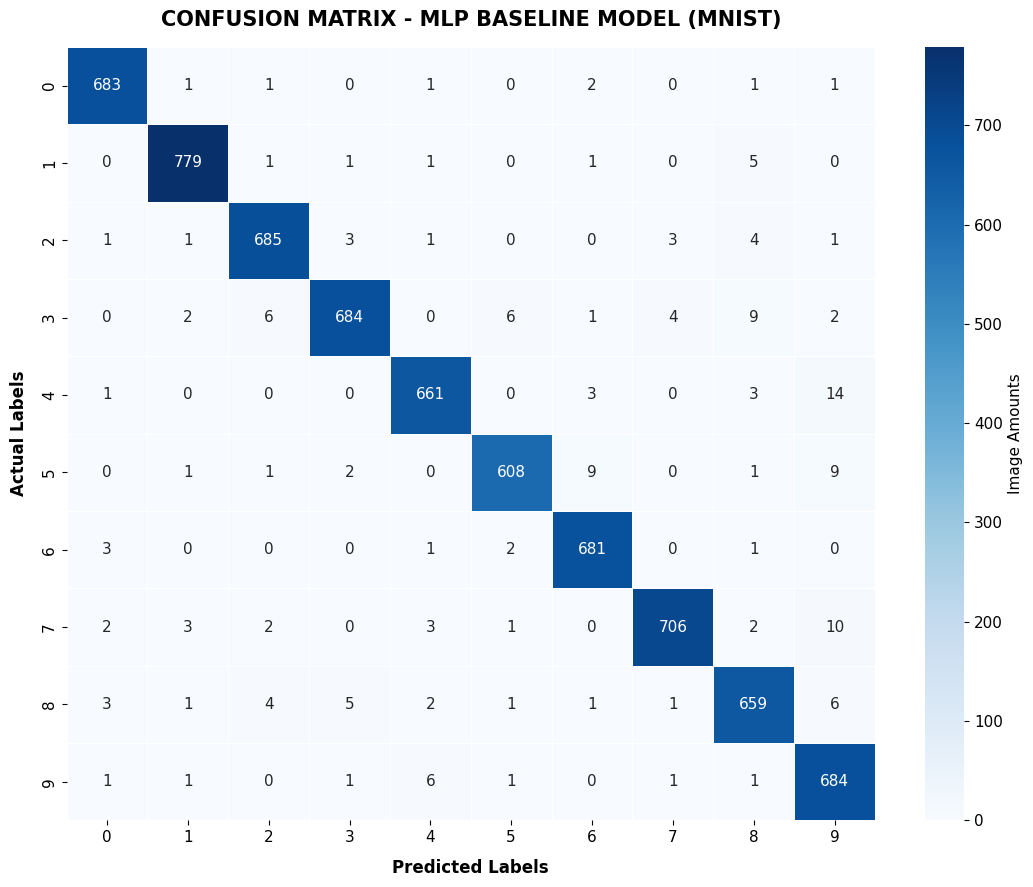

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix from the actual label and the MLP predicted label
cm = confusion_matrix(y_test2, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.5,
    cbar_kws={'label': 'Image Amounts'}
)

plt.title('CONFUSION MATRIX - MLP BASELINE MODEL (MNIST)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Actual Labels', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

## 3.2 CNN

### 3.2.1 Hyperparameter Optimization with Optuna

In [39]:
from sklearn.model_selection import train_test_split

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_cnn, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [40]:
import optuna
from tensorflow.keras import models, layers, optimizers

def objective(trial):
    """Optuna objective function for tuning CNN hyperparameters over 10 epochs."""
    # Hyperparameter search space
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_filters_1 = trial.suggest_categorical('num_filters', [32, 64])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Model architecture - Perfectly synchronized with Batch Normalization
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1), name="input_layer"),

        # Conv Block 1
        layers.Conv2D(filters=num_filters_1, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Conv Block 2 (Target conv layer for later Grad-CAM)
        layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        # Fully Connected Layer
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(rate=dropout_rate),

        # Output Layer
        layers.Dense(10, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train model for exactly 10 epochs
    # history = model.fit(
    #     X_train_cnn, y_train,
    #     epochs=10,                      # 10 epochs active
    #     batch_size=b_size,
    #     validation_split=0.1,
    #     verbose=0
    # )

    history = model.fit(
        X_train_final, y_train_final,
        validation_data=(X_val_final, y_val_final),
        batch_size=b_size,
        epochs=10,
        verbose=0,
    )

    return max(history.history['val_accuracy'])

# Initialize Optuna study (Pure maximization without pruner dependency)
study = optuna.create_study(direction='maximize')

print("--- Starting Hyperparameter Optimization with Optuna (5 Trials @ 10 Epochs) ---")
study.optimize(objective, n_trials=5)

# Print optimization results
print("\n--- OPTUNA OPTIMIZATION RESULTS ---")
print(f"Best Validation Accuracy: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")


[I 2026-06-19 09:32:31,995] A new study created in memory with name: no-name-521c188f-aa2f-4355-afd9-e7532c76d259


--- Starting Hyperparameter Optimization with Optuna (5 Trials @ 10 Epochs) ---


[I 2026-06-19 09:33:56,065] Trial 0 finished with value: 0.9900000095367432 and parameters: {'learning_rate': 0.0038937865660337396, 'num_filters': 64, 'dropout_rate': 0.25190382539010125, 'batch_size': 32}. Best is trial 0 with value: 0.9900000095367432.
[I 2026-06-19 09:34:37,842] Trial 1 finished with value: 0.9893333315849304 and parameters: {'learning_rate': 0.002419679472935486, 'num_filters': 64, 'dropout_rate': 0.3293128631201104, 'batch_size': 128}. Best is trial 0 with value: 0.9900000095367432.
[I 2026-06-19 09:35:59,074] Trial 2 finished with value: 0.9908333420753479 and parameters: {'learning_rate': 0.000592722162589376, 'num_filters': 64, 'dropout_rate': 0.46111831736933134, 'batch_size': 32}. Best is trial 2 with value: 0.9908333420753479.
[I 2026-06-19 09:37:18,694] Trial 3 finished with value: 0.9886666536331177 and parameters: {'learning_rate': 0.00011805244489484353, 'num_filters': 64, 'dropout_rate': 0.23547651436292835, 'batch_size': 32}. Best is trial 2 with valu


--- OPTUNA OPTIMIZATION RESULTS ---
Best Validation Accuracy: 0.9908
Best Hyperparameters:
  - learning_rate: 0.000592722162589376
  - num_filters: 64
  - dropout_rate: 0.46111831736933134
  - batch_size: 32


**Optuna Visualization**

In [41]:
import optuna.visualization as vis
import plotly.express as px

# 1. Plot Optimization History
fig_history = vis.plot_optimization_history(study)
if fig_history.data:
    fig_history.data[0].line.color = '#4D96FF'
    if len(fig_history.data) > 1:
        fig_history.data[1].marker.color = '#FF6B6B'
fig_history.update_layout(
    title="<b>Optimization History</b>",
    xaxis_title="Trials",
    yaxis_title="Validation Accuracy",
    template="plotly_white"
)
fig_history.show()

# 2. Plot Hyperparameter Importances
fig_importance = vis.plot_param_importances(study)
if fig_importance.data:
    fig_importance.update_traces(marker=dict(color='#FF6B6B'))
fig_importance.update_layout(
    title="<b>Hyperparameter Importances</b>",
    xaxis_title="Importance",
    yaxis_title="Hyperparameters",
    template="plotly_white"
)
fig_importance.show()

# 3. Plot High-Dimensional Parameter Relationships
fig_parallel = vis.plot_parallel_coordinate(study)
if fig_parallel.data:
    fig_parallel.data[0].line.colorscale = px.colors.sequential.Plasma
    fig_parallel.data[0].line.showscale = True
fig_parallel.update_layout(
    title="<b>Parallel Coordinate Plot</b>",
    template="plotly_white"
)
fig_parallel.show()

### 3.2.2 Model Training

In [42]:
# Extract optimal hyperparameters from Optuna study
best_lr = study.best_params['learning_rate']
best_filters = study.best_params['num_filters']
best_dropout = study.best_params['dropout_rate']
best_batch = study.best_params['batch_size']

# 1. Initialize Standard CNN (Baseline Model)
standard_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1), name="input_layer"),

    # Conv Block 1
    layers.Conv2D(filters=best_filters, kernel_size=(3, 3), padding='same', name="conv_block_1"),
    layers.BatchNormalization(name="batch_norm_1"),
    layers.Activation('relu', name="act_1"),
    layers.MaxPooling2D(pool_size=(2, 2), name="max_pool_1"),

    # Conv Block 2 (Target layer for Grad-CAM visualization)
    layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', name="target_conv_layer"),
    layers.BatchNormalization(name="batch_norm_2"),
    layers.Activation('relu', name="target_activation"),
    layers.MaxPooling2D(pool_size=(2, 2), name="max_pool_2"),

    # Flatten spatial features
    layers.Flatten(name="flatten_layer"),

    # Fully Connected Layer
    layers.Dense(units=128, name="fc_layer"),
    layers.BatchNormalization(name="batch_norm_fc"),
    layers.Activation('relu', name="act_fc"),
    layers.Dropout(rate=best_dropout, name="dropout_layer"),

    # Output Layer for 10 MNIST classes
    layers.Dense(units=10, activation='softmax', name="output_layer")
])

# 2. Compile baseline model
standard_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

standard_cnn.summary()

# Configure dynamic learning rate scheduler
my_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
]

# 3. Train Standard CNN for a full 15 epochs
print("\n--- Training Standard CNN (Baseline Model) ---")
history_standard = standard_cnn.fit(
    X_train_final, y_train_final,
    epochs=15,
    batch_size=best_batch,
    validation_data=(X_val_final, y_val_final),
    callbacks=my_callbacks,
    verbose=1
)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block_1 (Conv2D)           │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_conv_layer (Conv2D)      │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_activation (Activation)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_layer (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_fc                   │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_fc (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 441,418 (1.68 MB)

 Trainable params: 440,906 (1.68 MB)

 Non-trainable params: 512 (2.00 KB)


--- Training Standard CNN (Baseline Model) ---
Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9574 - loss: 0.1565 - val_accuracy: 0.9822 - val_loss: 0.0602 - learning_rate: 5.9272e-04
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9811 - loss: 0.0668 - val_accuracy: 0.9878 - val_loss: 0.0426 - learning_rate: 5.9272e-04
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0498 - val_accuracy: 0.9872 - val_loss: 0.0436 - learning_rate: 5.9272e-04
Epoch 4/15
1684/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9875 - loss: 0.0404
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00011854443000629545.
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9880 - loss: 0.0393 - val_accuracy: 0.9868 - val_loss: 0.0449 - learning_rate: 5.9272e-04
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9930 - loss: 0.0225 - val_accuracy: 0.9908 - val_loss: 0.0296 - learning_rate: 1.1854e-04
Epoch 

## 3.3 ResNet-9 (Mini-ResNet)

### 3.3.1 Hyperparameter Tuning

In [43]:
import optuna
from tensorflow.keras import models, layers, optimizers

def objective_resnet(trial):
    """Optuna objective function for Custom ResNet."""
    # Hyperparameter search space
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_filters_1 = trial.suggest_categorical('num_filters', [32, 64])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Helper function for Residual Block
    def res_block_optuna(x, filters):
        shortcut = x
        x = layers.Conv2D(filters, 3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, 1, strides=1, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.add([x, shortcut])
        x = layers.Activation('relu')(x)
        return x

    # Architecture
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(filters=num_filters_1, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = res_block_optuna(x, filters=num_filters_1)
    x = res_block_optuna(x, filters=64)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(rate=dropout_rate)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_cnn, y_train,
        epochs=10,
        batch_size=b_size,
        validation_split=0.1,
        verbose=0
    )
    return max(history.history['val_accuracy'])

# Run Study
study_resnet = optuna.create_study(direction='maximize')
print("--- Starting Optuna Tuning for ResNet-9 (5 Trials @ 10 Epochs) ---")
study_resnet.optimize(objective_resnet, n_trials=5)

print("\n--- RESNET-9 OPTIMIZATION RESULTS ---")
print(f"Best Val Accuracy: {study_resnet.best_value:.4f}")
for key, value in study_resnet.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-19 09:40:23,307] A new study created in memory with name: no-name-b952349e-bc45-4738-8716-ef4d9e30019d


--- Starting Optuna Tuning for ResNet-9 (5 Trials @ 10 Epochs) ---


[I 2026-06-19 09:41:32,292] Trial 0 finished with value: 0.9923333525657654 and parameters: {'learning_rate': 0.00012069621278410984, 'num_filters': 64, 'dropout_rate': 0.3024415332136592, 'batch_size': 128}. Best is trial 0 with value: 0.9923333525657654.
[I 2026-06-19 09:42:41,546] Trial 1 finished with value: 0.9925000071525574 and parameters: {'learning_rate': 0.0005086559778620894, 'num_filters': 32, 'dropout_rate': 0.27989881228124147, 'batch_size': 64}. Best is trial 1 with value: 0.9925000071525574.
[I 2026-06-19 09:44:26,846] Trial 2 finished with value: 0.9931666851043701 and parameters: {'learning_rate': 0.004499019093537163, 'num_filters': 64, 'dropout_rate': 0.39585632169388263, 'batch_size': 32}. Best is trial 2 with value: 0.9931666851043701.
[I 2026-06-19 09:45:40,684] Trial 3 finished with value: 0.9926666617393494 and parameters: {'learning_rate': 0.009910027045382084, 'num_filters': 64, 'dropout_rate': 0.3555545916935693, 'batch_size': 128}. Best is trial 2 with valu


--- RESNET-9 OPTIMIZATION RESULTS ---
Best Val Accuracy: 0.9935
  - learning_rate: 0.00025573519254832775
  - num_filters: 64
  - dropout_rate: 0.40988646695112707
  - batch_size: 64


### 3.3.2 Model Training

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, optimizers, callbacks

# 1. ASSIGN OPTIMIZED HYPERPARAMETERS FROM RESNET-9 OPTUNA STUDY
best_lr_resnet = 0.003117802499283948
best_filters_resnet = 32
best_dropout_resnet = 0.22150869266027387
best_batch_resnet = 64

# 2. DEFINE A NAMED RESIDUAL BLOCK FOR GRAD-CAM
def residual_block(x, filters, block_name, kernel_size=3, stride=1):
    """Residual block with stable names for later XAI feature extraction."""
    shortcut = x

    x = layers.Conv2D(
        filters, kernel_size, strides=stride, padding='same',
        name=f"{block_name}_conv1"
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation('relu', name=f"{block_name}_act1")(x)

    x = layers.Conv2D(
        filters, kernel_size, strides=1, padding='same',
        name=f"{block_name}_conv2"
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride, padding='same',
            name=f"{block_name}_shortcut_conv"
        )(shortcut)
        shortcut = layers.BatchNormalization(
            name=f"{block_name}_shortcut_bn"
        )(shortcut)

    x = layers.Add(name=f"{block_name}_add")([x, shortcut])
    x = layers.Activation('relu', name=f"{block_name}_out")(x)
    return x

# 3. BUILD CUSTOM RESNET MODEL
inputs = layers.Input(shape=(28, 28, 1), name="input_layer")

x = layers.Conv2D(
    filters=best_filters_resnet,
    kernel_size=3,
    padding='same',
    name="init_conv"
)(inputs)
x = layers.BatchNormalization(name="init_bn")(x)
x = layers.Activation('relu', name="init_act")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="init_pool")(x)

x = residual_block(x, filters=best_filters_resnet, block_name="res_block_1")
x = residual_block(x, filters=64, block_name="res_block_2")
x = layers.MaxPooling2D(pool_size=(2, 2), name="resnet_final_pool")(x)

x = layers.Flatten(name="flatten_layer")(x)
x = layers.Dense(128, name="fc_layer")(x)
x = layers.BatchNormalization(name="fc_bn")(x)
x = layers.Activation('relu', name="fc_act")(x)
x = layers.Dropout(rate=best_dropout_resnet, name="dropout_layer")(x)
outputs = layers.Dense(10, activation='softmax', name="output_layer")(x)

resnet_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Custom_ResNet"
)

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr_resnet),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

resnet_callbacks = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2,
        min_lr=1e-6, verbose=1
    )
]

print("\n--- Training Custom ResNet (Evolution Model) ---")
history_resnet = resnet_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    batch_size=best_batch_resnet,
    callbacks=resnet_callbacks,
    epochs=15,
    verbose=1,
)


Model: "Custom_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_conv (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_bn             │ (None, 28, 28,    │        128 │ init_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_act            │ (None, 28, 28,    │          0 │ init_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_pool           │ (None, 14, 14,    │          0 │ init_act[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_conv1   │ (None, 14, 14,    │      9,248 │ init_pool[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_bn1     │ (None, 14, 14,    │        128 │ res_block_1_conv… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_act1    │ (None, 14, 14,    │          0 │ res_block_1_bn1[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_conv2   │ (None, 14, 14,    │      9,248 │ res_block_1_act1… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_bn2     │ (None, 14, 14,    │        128 │ res_block_1_conv… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_add     │ (None, 14, 14,    │          0 │ res_block_1_bn2[… │
│ (Add)               │ 32)               │            │ init_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_out     │ (None, 14, 14,    │          0 │ res_block_1_add[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_2_conv1   │ (None, 14, 14,    │     18,496 │ res_block_1_out[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_2_bn1     │ (None, 14, 14,    │        256 │ res_block_2_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_2_act1    │ (None, 14, 14,    │          0 │ res_block_2_bn1[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_2_conv2   │ (None, 14, 14,    │     36,928 │ res_block_2_act1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_2_shortc… │ (None, 14, 14,    │      2,112 │ res_block_1_out[

 Total params: 480,842 (1.83 MB)

 Trainable params: 480,010 (1.83 MB)

 Non-trainable params: 832 (3.25 KB)


--- Training Custom ResNet (Evolution Model) ---
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9726 - loss: 0.0915 - val_accuracy: 0.9780 - val_loss: 0.0775 - learning_rate: 0.0031
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9877 - loss: 0.0400 - val_accuracy: 0.9853 - val_loss: 0.0511 - learning_rate: 0.0031
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9909 - loss: 0.0294 - val_accuracy: 0.9890 - val_loss: 0.0410 - learning_rate: 0.0031
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9926 - loss: 0.0230 - val_accuracy: 0.9900 - val_loss: 0.0368 - learning_rate: 0.0031
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9935 - loss: 0.0190 - val_accuracy: 0.9848 - val_loss: 0.0552 - learning_rate: 0.0031
Epoch 6/15
840/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9946 - loss: 0.0156
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0006235605105757713.
844/844 ━━━━━━━━━━━━━━━━━━

## 3.4 Tiny-ViT (Vision Transformer)

### 3.4.1 Hyperparameter tuning

In [45]:
import optuna
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers

def objective_tinyvit(trial):
    """Optuna objective function for TinyViT."""
    # Hyperparameter search space
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Fixed architecture space components
    patch_size = 4
    num_patches = (28 // patch_size) ** 2
    projection_dim = 64
    num_heads = 4
    transformer_layers = 2

    # Architecture
    inputs = layers.Input(shape=(28, 28, 1))
    patches = layers.Conv2D(filters=projection_dim, kernel_size=patch_size, strides=patch_size)(inputs)
    flat_patches = layers.Reshape(target_shape=(num_patches, projection_dim))(patches)

    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = flat_patches + pos_embedding

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x1, x1)
        attention_output = layers.Dropout(rate=dropout_rate)(attention_output)
        x2 = layers.add([attention_output, x])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        mlp_output = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
        mlp_output = layers.Dropout(rate=dropout_rate)(mlp_output)
        mlp_output = layers.Dense(projection_dim, activation=tf.nn.gelu)(mlp_output)
        x = layers.add([mlp_output, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(x)
    representation = layers.GlobalAveragePooling1D()(representation)
    representation = layers.Dropout(rate=dropout_rate)(representation)
    logits = layers.Dense(10, activation='softmax')(representation)

    model = models.Model(inputs=inputs, outputs=logits)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_cnn, y_train,
        epochs=10,
        batch_size=b_size,
        validation_split=0.1,
        verbose=0
    )
    return max(history.history['val_accuracy'])

# Run Study
study_tinyvit = optuna.create_study(direction='maximize')
print("--- Starting Optuna Tuning for TinyViT (5 Trials @ 10 Epochs) ---")
study_tinyvit.optimize(objective_tinyvit, n_trials=5)

print("\n--- TINYVIT OPTIMIZATION RESULTS ---")
print(f"Best Val Accuracy: {study_tinyvit.best_value:.4f}")
for key, value in study_tinyvit.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-19 09:49:02,520] A new study created in memory with name: no-name-1a71eea9-c232-4e7c-87c7-cf4f11741050


--- Starting Optuna Tuning for TinyViT (5 Trials @ 10 Epochs) ---


[I 2026-06-19 09:50:34,362] Trial 0 finished with value: 0.9636666774749756 and parameters: {'learning_rate': 0.001415217531273237, 'dropout_rate': 0.3820131532393502, 'batch_size': 64}. Best is trial 0 with value: 0.9636666774749756.
[I 2026-06-19 09:51:58,334] Trial 1 finished with value: 0.9570000171661377 and parameters: {'learning_rate': 0.002105485033465923, 'dropout_rate': 0.4833480512795978, 'batch_size': 64}. Best is trial 0 with value: 0.9636666774749756.
[I 2026-06-19 09:53:09,883] Trial 2 finished with value: 0.9629999995231628 and parameters: {'learning_rate': 0.00015605226863085877, 'dropout_rate': 0.3204314387093554, 'batch_size': 128}. Best is trial 0 with value: 0.9636666774749756.
[I 2026-06-19 09:54:34,776] Trial 3 finished with value: 0.8791666626930237 and parameters: {'learning_rate': 0.0041162408102602, 'dropout_rate': 0.37126566808387806, 'batch_size': 64}. Best is trial 0 with value: 0.9636666774749756.
[I 2026-06-19 09:55:44,996] Trial 4 finished with value: 0


--- TINYVIT OPTIMIZATION RESULTS ---
Best Val Accuracy: 0.9637
  - learning_rate: 0.001415217531273237
  - dropout_rate: 0.3820131532393502
  - batch_size: 64


### 3.4.2 Model training

In [46]:
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, callbacks

# 1. ASSIGN OPTIMIZED HYPERPARAMETERS FROM TINYVIT OPTUNA STUDY
best_lr_vit = 0.0004511621607310748
best_dropout_vit = 0.25444330590087644
best_batch_vit = 64

# --- TinyViT Architecture Config ---
patch_size = 4
num_patches = (28 // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_layers = 2
dense_units = 128

def create_vit_classifier():
    inputs = layers.Input(shape=(28, 28, 1), name="input_layer")

    # 1. Patch Extraction & Projection
    patches = layers.Conv2D(filters=projection_dim, kernel_size=patch_size, strides=patch_size, name="patch_conv")(inputs)
    flat_patches = layers.Reshape(target_shape=(num_patches, projection_dim))(patches)

    # 2. Positional Embedding
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = flat_patches + pos_embedding

    # 3. Transformer Encoder Blocks
    for i in range(transformer_layers):
        # Layer Normalization 1 + Multi-Head Attention
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x1, x1)
        attention_output = layers.Dropout(rate=best_dropout_vit)(attention_output)
        x2 = layers.add([attention_output, x])

        # Layer Normalization 2 + MLP
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        mlp_output = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
        mlp_output = layers.Dropout(rate=best_dropout_vit)(mlp_output)
        mlp_output = layers.Dense(projection_dim, activation=tf.nn.gelu)(mlp_output)
        x = layers.add([mlp_output, x2])

    # 4. Classifier Head
    representation = layers.LayerNormalization(epsilon=1e-6)(x)
    representation = layers.GlobalAveragePooling1D()(representation)
    representation = layers.Dropout(rate=best_dropout_vit)(representation)

    logits = layers.Dense(10, activation='softmax', name="output_layer")(representation)

    return models.Model(inputs=inputs, outputs=logits, name="TinyViT")

# 2. INITIALIZE AND COMPILE MODEL
tinyvit_model = create_vit_classifier()

tinyvit_model.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr_vit),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tinyvit_model.summary()

# 3. TRAINING CONFIGURATION
vit_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
]

print("\n--- Training TinyViT (Next-Gen Attention Model) ---")
# history_tinyvit = tinyvit_model.fit(
#     X_train_cnn, y_train,
#     epochs=15,
#     batch_size=best_batch_vit,
#     validation_split=0.1,
#     callbacks=vit_callbacks,
#     verbose=1
# )

history_tinyvit = tinyvit_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_final, y_val_final),
    batch_size=best_batch_vit,
    epochs=15,
    callbacks=vit_callbacks,
    verbose=1,
)

Model: "TinyViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_conv (Conv2D) │ (None, 7, 7, 64)  │      1,088 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 49, 64)    │          0 │ patch_conv[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_35 (Add)        │ (None, 49, 64)    │          0 │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_35[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 49, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 49, 64)    │          0 │ dropout_53[0][0], │
│                     │                   │            │ add_35[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_36[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 49, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 49, 128)   │          0 │ dense_59[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 49, 64)    │      8,256 │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 49, 64)    │          0 │ dense_60[0][0],   │
│                     │                   │            │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_37[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 49, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_38 (Add)        │ (None, 49, 64)    │          0 │ dropout_56[0][0], │
│                     │                   │            │ add_37[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_38[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 168,266 (657.29 KB)

 Trainable params: 168,266 (657.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Training TinyViT (Next-Gen Attention Model) ---
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.7788 - loss: 0.6607 - val_accuracy: 0.8898 - val_loss: 0.3645 - learning_rate: 4.5116e-04
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.9020 - loss: 0.3099 - val_accuracy: 0.9093 - val_loss: 0.3186 - learning_rate: 4.5116e-04
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9294 - loss: 0.2280 - val_accuracy: 0.9430 - val_loss: 0.1918 - learning_rate: 4.5116e-04
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9388 - loss: 0.1958 - val_accuracy: 0.9508 - val_loss: 0.1544 - learning_rate: 4.5116e-04
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9468 - loss: 0.1700 - val_accuracy: 0.9528 - val_loss: 0.1502 - learning_rate: 4.5116e-04
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9541 - loss: 0.1494 - val_accuracy: 0.9590 - val_loss: 0.1340 - learning_rate: 4.5116e-04
Epoch 7/

# 4. Evaluation & Comparision

## 4.1. Performance Statistics & Metrics Benchmark

In [47]:
def evaluate_model_performance(model, custom_name, X_test, y_test):
    """Evaluates inference time, accuracy, loss, and Macro F1-Score."""

    start_time = time.time()
    y_pred_probs = model.predict(X_test, verbose=0)
    inference_time = time.time() - start_time

    y_pred = np.argmax(y_pred_probs, axis=1)

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    avg_time_per_img = (inference_time / len(X_test)) * 1000

    print(f"\n REPORT: {custom_name.upper()}")
    print(f" Test Loss    : {loss:.4f}")
    print(f" Test Accuracy: {accuracy*100:.2f}%")
    print(f" Macro F1     : {macro_f1:.4f}")
    print(f" Latency/Image: {avg_time_per_img:.4f} ms/img")

    return {
        "Model Architecture": custom_name,
        "Loss": round(loss, 4),
        "Accuracy (%)": round(accuracy * 100, 2),
        "Macro F1-Score": round(macro_f1, 4),
        "Total Latency (s)": round(inference_time, 4),
        "Avg Latency (ms/img)": round(avg_time_per_img, 4)
    }

# --- EXECUTE BENCHMARK ---

results = []

results.append(evaluate_model_performance(standard_cnn, "Standard CNN (Baseline)", X_test_cnn, y_test))
results.append(evaluate_model_performance(resnet_model, "Custom ResNet-9", X_test_cnn, y_test))
results.append(evaluate_model_performance(tinyvit_model, "TinyViT (Attention)", X_test_cnn, y_test))

# --- DISPLAY FINAL COMPARISON ---
print("\n" + "="*50)
print("       FINAL ARCHITECTURE BENCHMARK SUMMARY")
print("="*50)
df_compare = pd.DataFrame(results)
print(df_compare.to_markdown(index=False))



 REPORT: STANDARD CNN (BASELINE)
 Test Loss    : 0.0198
 Test Accuracy: 99.43%
 Macro F1     : 0.9943
 Latency/Image: 0.1492 ms/img

 REPORT: CUSTOM RESNET-9
 Test Loss    : 0.0174
 Test Accuracy: 99.48%
 Macro F1     : 0.9948
 Latency/Image: 0.3058 ms/img

 REPORT: TINYVIT (ATTENTION)
 Test Loss    : 0.0811
 Test Accuracy: 97.83%
 Macro F1     : 0.9781
 Latency/Image: 0.3838 ms/img

       FINAL ARCHITECTURE BENCHMARK SUMMARY
| Model Architecture      |   Loss |   Accuracy (%) |   Macro F1-Score |   Total Latency (s) |   Avg Latency (ms/img) |
|:------------------------|-------:|---------------:|-----------------:|--------------------:|-----------------------:|
| Standard CNN (Baseline) | 0.0198 |          99.43 |           0.9943 |              1.4924 |                 0.1492 |
| Custom ResNet-9         | 0.0174 |          99.48 |           0.9948 |              3.0583 |                 0.3058 |
| TinyViT (Attention)     | 0.0811 |          97.83 |           0.9781 |              3.

## 4.2 Comparative Learning Curves

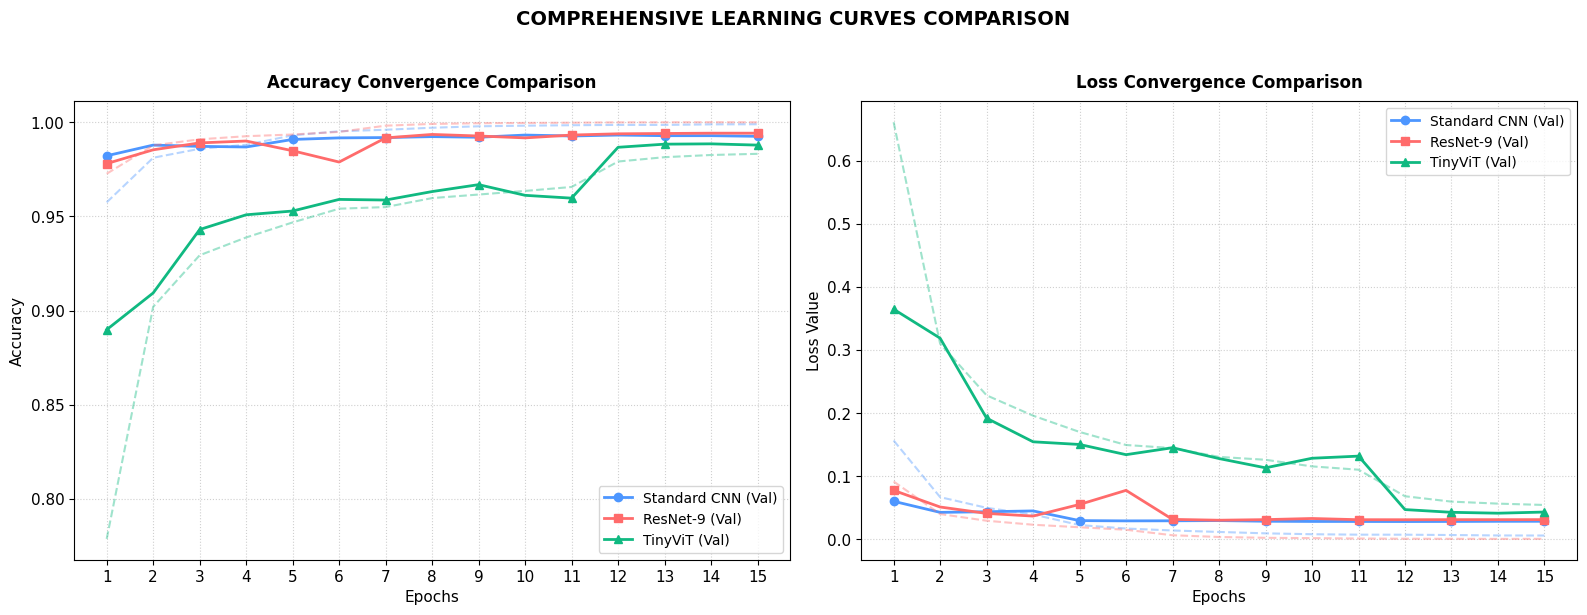

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(history_standard.history['accuracy']) + 1)
colors = {'standard': '#4D96FF', 'resnet': '#FF6B6B', 'tinyvit': '#10B981'}

# 1. ACCURACY CURVES COMPARISON
ax1.plot(epochs_range, history_standard.history['accuracy'], color=colors['standard'], linestyle='--', alpha=0.4)
ax1.plot(epochs_range, history_standard.history['val_accuracy'], label='Standard CNN (Val)', color=colors['standard'], marker='o', markevery=2, linewidth=2)

ax1.plot(epochs_range, history_resnet.history['accuracy'], color=colors['resnet'], linestyle='--', alpha=0.4)
ax1.plot(epochs_range, history_resnet.history['val_accuracy'], label='ResNet-9 (Val)', color=colors['resnet'], marker='s', markevery=2, linewidth=2)

ax1.plot(epochs_range, history_tinyvit.history['accuracy'], color=colors['tinyvit'], linestyle='--', alpha=0.4)
ax1.plot(epochs_range, history_tinyvit.history['val_accuracy'], label='TinyViT (Val)', color=colors['tinyvit'], marker='^', markevery=2, linewidth=2)

ax1.set_title('Accuracy Convergence Comparison', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', fontsize=10)

# 2. LOSS CURVES COMPARISON
ax2.plot(epochs_range, history_standard.history['loss'], color=colors['standard'], linestyle='--', alpha=0.4)
ax2.plot(epochs_range, history_standard.history['val_loss'], label='Standard CNN (Val)', color=colors['standard'], marker='o', markevery=2, linewidth=2)

ax2.plot(epochs_range, history_resnet.history['loss'], color=colors['resnet'], linestyle='--', alpha=0.4)
ax2.plot(epochs_range, history_resnet.history['val_loss'], label='ResNet-9 (Val)', color=colors['resnet'], marker='s', markevery=2, linewidth=2)

ax2.plot(epochs_range, history_tinyvit.history['loss'], color=colors['tinyvit'], linestyle='--', alpha=0.4)
ax2.plot(epochs_range, history_tinyvit.history['val_loss'], label='TinyViT (Val)', color=colors['tinyvit'], marker='^', markevery=2, linewidth=2)

ax2.set_title('Loss Convergence Comparison', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Value')
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=10)

plt.suptitle("COMPREHENSIVE LEARNING CURVES COMPARISON", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.3 Deep Error & Confusion Matrix Analysis

Generating predictions for deep analysis...


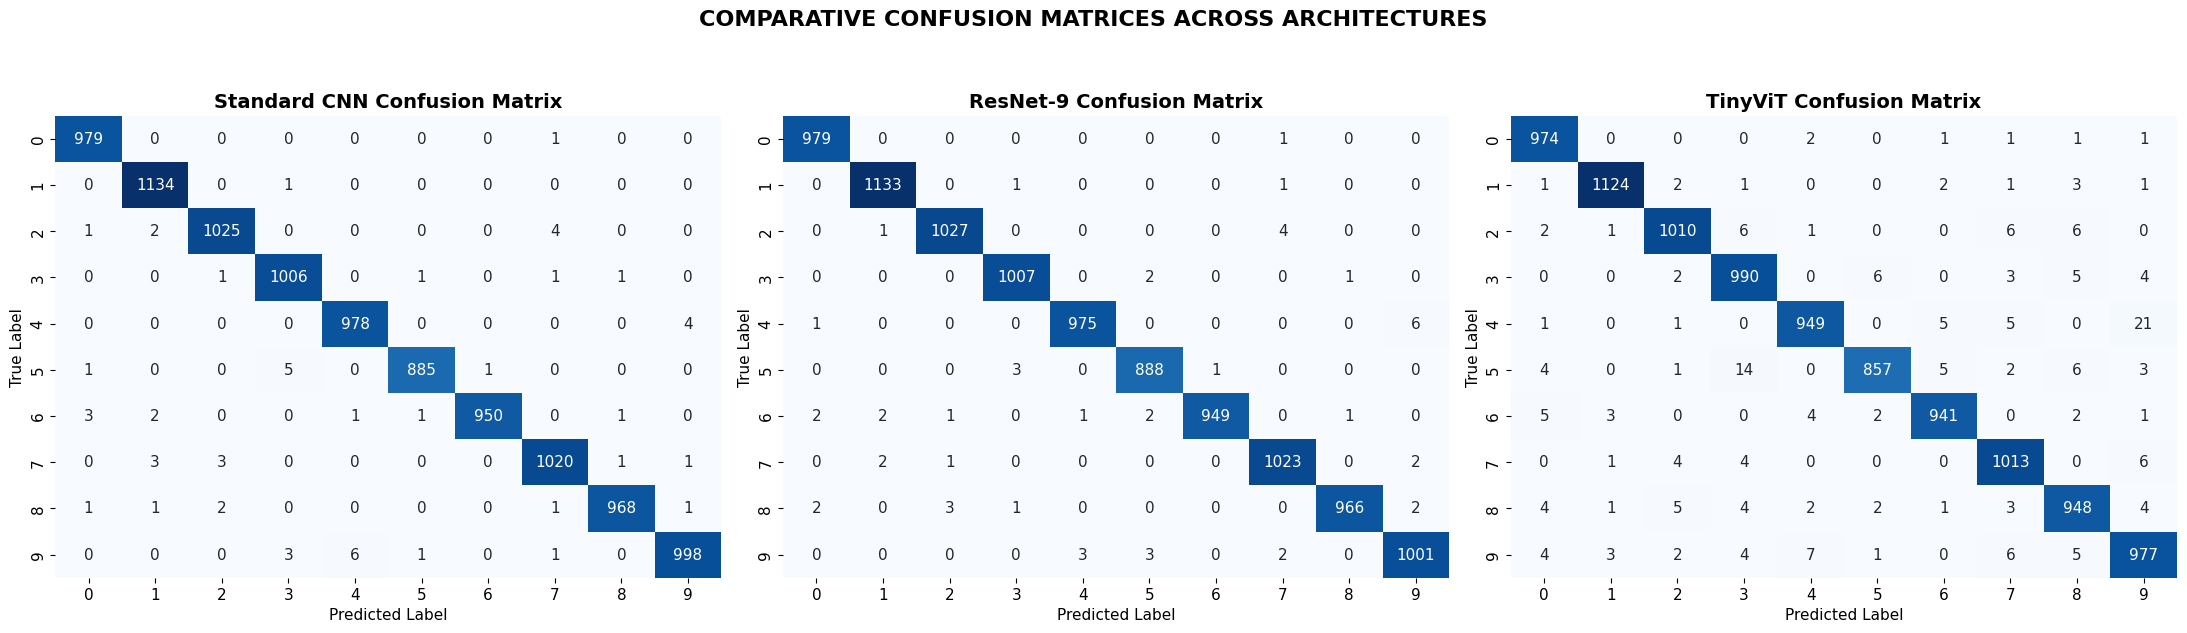


Total misclassified images by Standard CNN: 57
Plotting top 8 sample errors for comparative analysis...


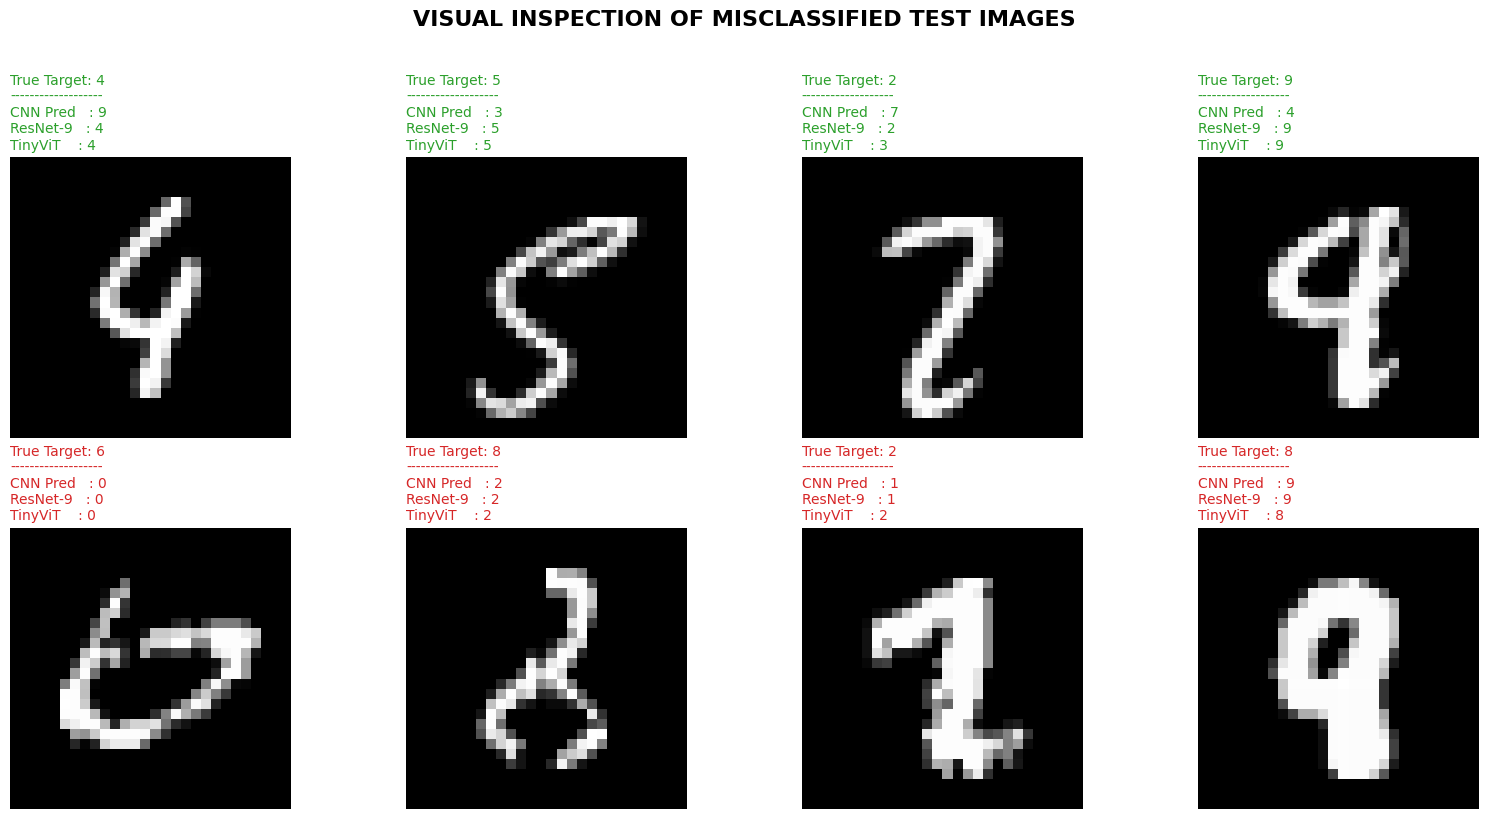

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating predictions for deep analysis...")
pred_standard = np.argmax(standard_cnn.predict(X_test_cnn, verbose=0), axis=1)
pred_resnet = np.argmax(resnet_model.predict(X_test_cnn, verbose=0), axis=1)
pred_tinyvit = np.argmax(tinyvit_model.predict(X_test_cnn, verbose=0), axis=1)

models_preds = [pred_standard, pred_resnet, pred_tinyvit]
model_names = ['Standard CNN', 'ResNet-9', 'TinyViT']

# STEP 1: SIDE-BY-SIDE CONFUSION MATRIX VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, (pred, name) in enumerate(zip(models_preds, model_names)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.suptitle("COMPARATIVE CONFUSION MATRICES ACROSS ARCHITECTURES", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# STEP 2: MISCLASSIFIED IMAGES ANALYSIS (ERROR ANALYSIS)
# Find common failure indices
misclassified_idx = np.where(pred_standard != y_test)[0]

print(f"\nTotal misclassified images by Standard CNN: {len(misclassified_idx)}")
print("Plotting top 8 sample errors for comparative analysis...")

plt.figure(figsize=(16, 8))
for i, idx in enumerate(misclassified_idx[:8]):
    plt.subplot(2, 4, i + 1)
    # Reshape back to 28x28 grayscale image for display
    plt.imshow(X_test_cnn[idx].reshape(28, 28), cmap='gray')

    # Label formatting showing True Target vs Predictions of each model
    label_text = (
        f"True Target: {y_test[idx]}\n"
        f"-------------------\n"
        f"CNN Pred   : {pred_standard[idx]}\n"
        f"ResNet-9   : {pred_resnet[idx]}\n"
        f"TinyViT    : {pred_tinyvit[idx]}"
    )
    plt.title(label_text, fontsize=10, loc='left', color='#D62728' if y_test[idx] != pred_resnet[idx] else '#2CA02C')
    plt.axis('off')

plt.suptitle("VISUAL INSPECTION OF MISCLASSIFIED TEST IMAGES", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.4 Multi-Model Random Predictions Visualization

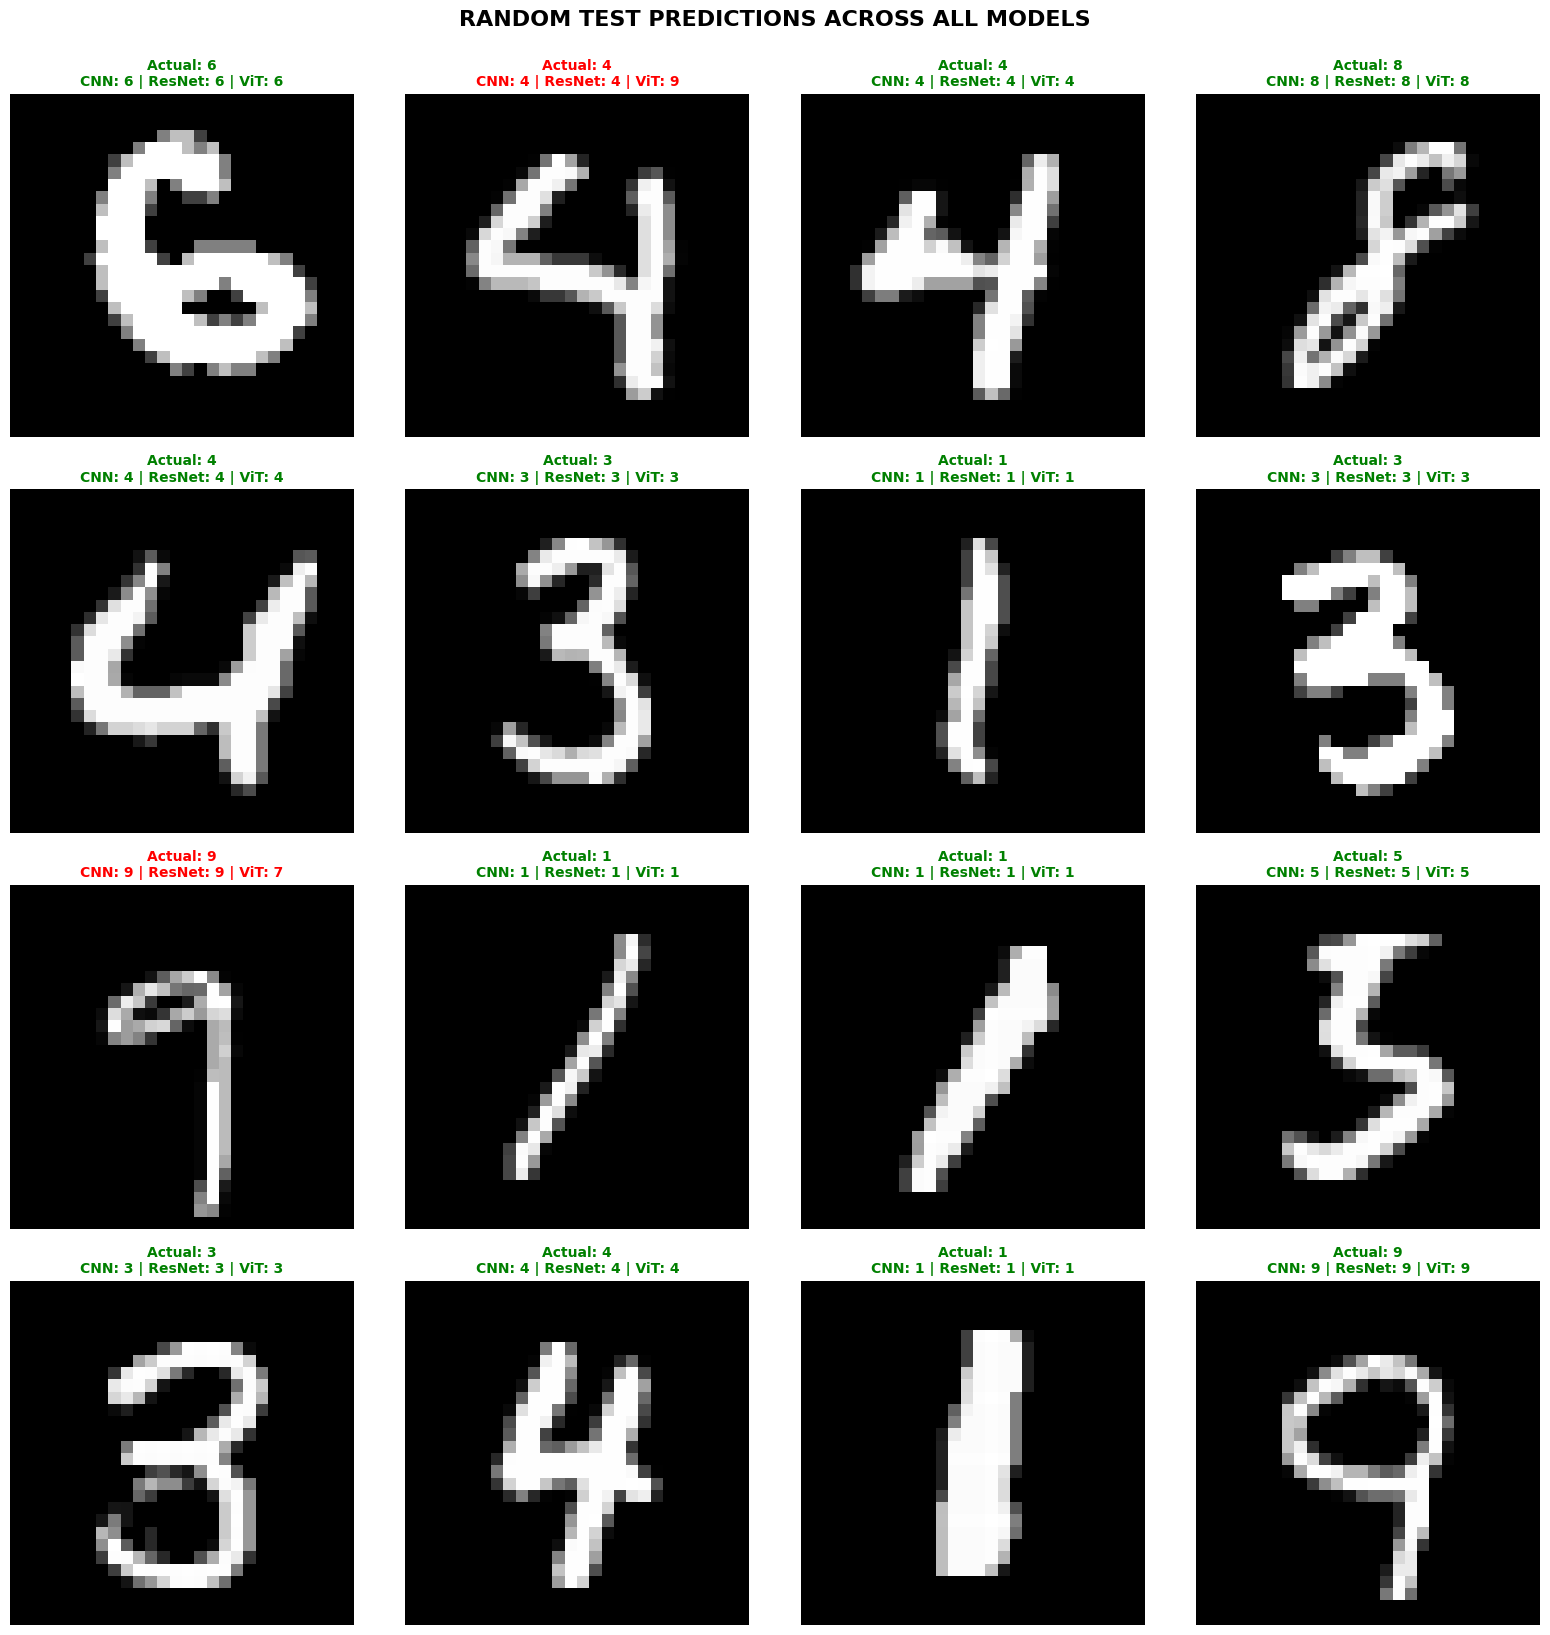

In [50]:
def plot_multi_model_predictions(X_test_images, y_true, pred_cnn, pred_resnet, pred_vit, num_rows=4, num_cols=4):
    """Plots a 4x4 grid of random test images with predictions from all 3 models."""
    total_images = len(X_test_images)
    random_indices = np.random.choice(total_images, size=(num_rows * num_cols), replace=False)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 16))
    axes = axes.ravel()

    for i, idx in enumerate(random_indices):
        img = X_test_images[idx].reshape(28, 28)
        actual = y_true[idx]
        p_cnn = pred_cnn[idx]
        p_res = pred_resnet[idx]
        p_vit = pred_vit[idx]

        # Determine title color: green if ALL models are correct, red otherwise
        all_correct = (p_cnn == actual) and (p_res == actual) and (p_vit == actual)
        title_color = 'green' if all_correct else 'red'

        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')

        title_string = f"Actual: {actual}\nCNN: {p_cnn} | ResNet: {p_res} | ViT: {p_vit}"
        axes[i].set_title(title_string, color=title_color, fontsize=10, fontweight='bold', pad=6)

    plt.tight_layout()
    plt.suptitle("RANDOM TEST PREDICTIONS ACROSS ALL MODELS", fontsize=16, fontweight='bold', y=1.02)
    plt.show()

plot_multi_model_predictions(X_test_cnn, y_test, pred_standard, pred_resnet, pred_tinyvit)

## 4.5 Single Sample Deep Dive with Model Saving

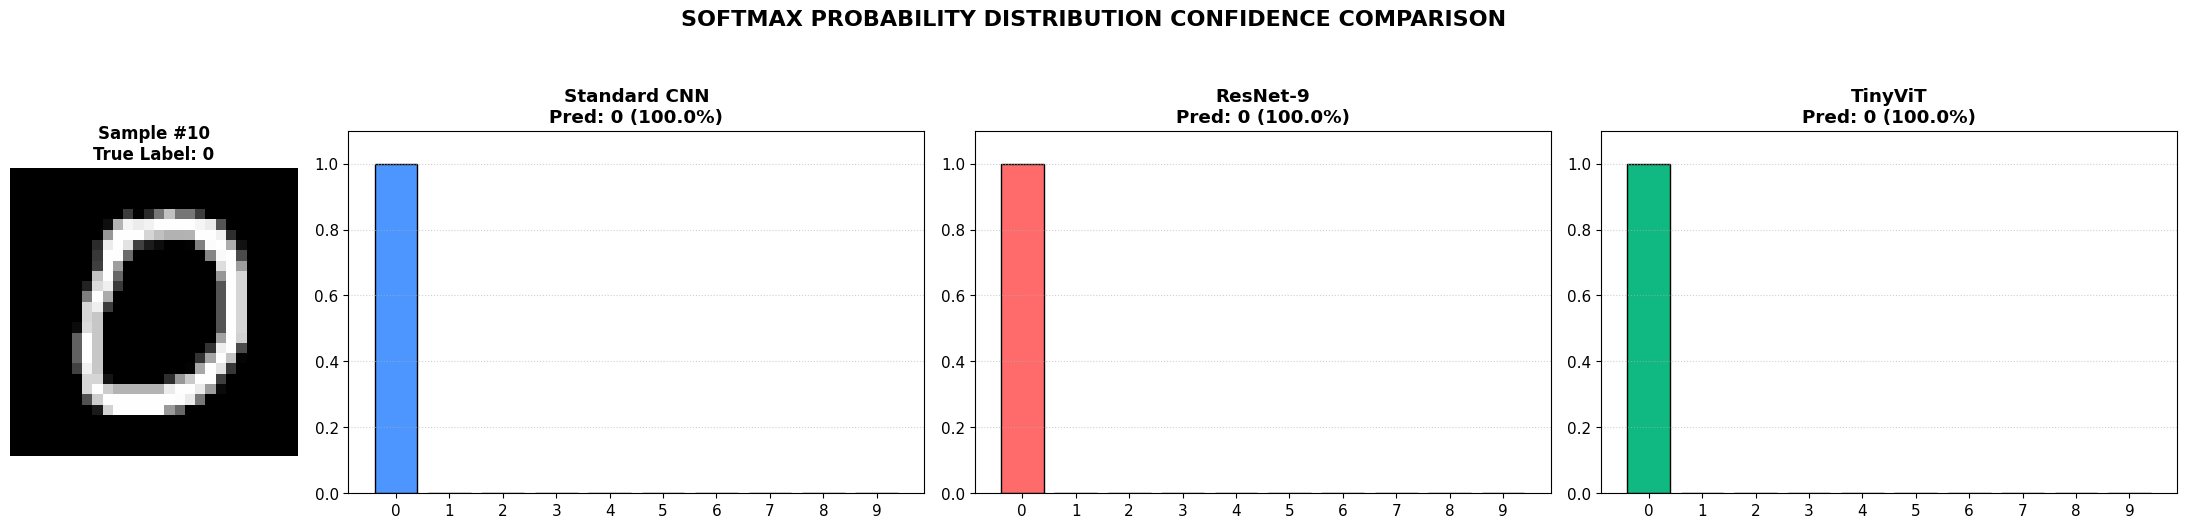


--- ALL MODELS SAVED SUCCESSFULLY FOR NEXT PHASES ---


In [51]:
sample_idx = 10
test_sample_image = X_test_cnn[sample_idx].reshape(28, 28)
actual_digit = y_test[sample_idx]

# 1. Get prediction probability distributions
prob_cnn = standard_cnn.predict(X_test_cnn[sample_idx:sample_idx+1], verbose=0)[0]
prob_res = resnet_model.predict(X_test_cnn[sample_idx:sample_idx+1], verbose=0)[0]
prob_vit = tinyvit_model.predict(X_test_cnn[sample_idx:sample_idx+1], verbose=0)[0]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), gridspec_kw={'width_ratios': [1, 2, 2, 2]})

# Plot 1: Input Image
axes[0].imshow(test_sample_image, cmap='gray')
axes[0].set_title(f"Sample #{sample_idx}\nTrue Label: {actual_digit}", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Common configuration for probability bar charts
classes = np.arange(10)
colors = {'cnn': '#4D96FF', 'resnet': '#FF6B6B', 'tinyvit': '#10B981'}

# Plot 2: Standard CNN Distribution
axes[1].bar(classes, prob_cnn, color=colors['cnn'], edgecolor='black')
axes[1].set_title(f"Standard CNN\nPred: {np.argmax(prob_cnn)} ({np.max(prob_cnn)*100:.1f}%)", fontweight='bold')
axes[1].set_xticks(classes)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

# Plot 3: ResNet-9 Distribution
axes[2].bar(classes, prob_res, color=colors['resnet'], edgecolor='black')
axes[2].set_title(f"ResNet-9\nPred: {np.argmax(prob_res)} ({np.max(prob_res)*100:.1f}%)", fontweight='bold')
axes[2].set_xticks(classes)
axes[2].set_ylim(0, 1.1)
axes[2].grid(axis='y', linestyle=':', alpha=0.6)

# Plot 4: TinyViT Distribution
axes[3].bar(classes, prob_vit, color=colors['tinyvit'], edgecolor='black')
axes[3].set_title(f"TinyViT\nPred: {np.argmax(prob_vit)} ({np.max(prob_vit)*100:.1f}%)", fontweight='bold')
axes[3].set_xticks(classes)
axes[3].set_ylim(0, 1.1)
axes[3].grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle("SOFTMAX PROBABILITY DISTRIBUTION CONFIDENCE COMPARISON", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# STEP 3: SAVE ALL MODELS FOR NEXT PHASES

standard_cnn.save('best_standard_cnn.keras')
resnet_model.save('best_resnet9.keras')
tinyvit_model.save('best_tinyvit.keras')

print("\n--- ALL MODELS SAVED SUCCESSFULLY FOR NEXT PHASES ---")

# 5. Explainable AI

## 5.1 XAI Objectives and Methodology

This section explains **why each model predicts a digit**, rather than reporting accuracy alone.

The reduced XAI workflow uses four complementary perspectives:

1. **Model-specific explanations**: nearest neighbors for KNN, global pixel importance for Random Forest, occlusion sensitivity for SVM, Grad-CAM for CNN/ResNet-9, and attention rollout for Tiny-ViT.
2. **Shared deep-learning attribution**: Vanilla Saliency and Integrated Gradients are applied to CNN, ResNet-9, and Tiny-ViT using the same representative images and target-class rules.
3. **Cross-model error analysis**: one model-disagreement case compares predicted-class and true-class Integrated Gradients across all deep-learning models.
4. **Faithfulness demonstration**: one representative high-confidence sample is used for a lightweight guided-vs-random deletion test.

All explanation functions receive one normalized image with shape `(28, 28, 1)`. Traditional ML adapters flatten it internally to `(1, 784)`.


## 5.2 Common Utilities and Reproducible Sample Selection

The following cells validate the variables created earlier in the notebook, register all models, construct pre-softmax logit models for gradient-based XAI, and select a fixed set of representative test images.


### 5.2.1 Imports, reproducibility, and notebook-state validation

In [52]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.patches import Rectangle
from tensorflow.keras import layers, models

XAI_RANDOM_SEED = 42
np.random.seed(XAI_RANDOM_SEED)
tf.random.set_seed(XAI_RANDOM_SEED)

required_variables = [
    "X_train_flat", "X_test_flat", "X_train_cnn", "X_test_cnn",
    "y_train", "y_test", "knn", "svm_pipeline", "rf",
    "standard_cnn", "resnet_model", "tinyvit_model"
]

missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Run all notebook cells from Sections 1-4 first. Missing variables: "
        + ", ".join(missing_variables)
    )

assert X_train_flat.ndim == 2 and X_train_flat.shape[1] == 784
assert X_test_flat.ndim == 2 and X_test_flat.shape[1] == 784
assert X_train_cnn.shape[1:] == (28, 28, 1)
assert X_test_cnn.shape[1:] == (28, 28, 1)
assert len(X_test_cnn) == len(y_test)

ML_MODELS = {
    "KNN": knn,
    "SVM": svm_pipeline,
    "Random Forest": rf,
}

DL_MODELS = {
    "CNN": standard_cnn,
    "ResNet-9": resnet_model,
    "Tiny-ViT": tinyvit_model,
}

CNN_GRADCAM_LAYER = "target_activation"
RESNET_GRADCAM_LAYER = "res_block_2_out"

print("XAI environment is ready.")
print(f"ML models: {list(ML_MODELS.keys())}")
print(f"DL models: {list(DL_MODELS.keys())}")


XAI environment is ready.
ML models: ['KNN', 'SVM', 'Random Forest']
DL models: ['CNN', 'ResNet-9', 'Tiny-ViT']


### 5.2.2 Common image preparation and prediction adapters

In [53]:
# @title
def prepare_xai_image(image):
    """Return one normalized MNIST image with shape (1, 28, 28, 1)."""
    image = np.asarray(image, dtype=np.float32)

    if image.shape == (784,):
        image = image.reshape(28, 28, 1)
    elif image.shape == (28, 28):
        image = image[..., np.newaxis]
    elif image.shape == (1, 28, 28):
        image = np.transpose(image, (1, 2, 0))
    elif image.shape == (1, 28, 28, 1):
        image = image[0]

    if image.shape != (28, 28, 1):
        raise ValueError(
            f"Expected (784,), (28,28), or (28,28,1); received {image.shape}."
        )

    # Keep compatibility with external uint8 images used later in Streamlit.
    if image.max() > 1.0:
        image = image / 255.0

    return image[np.newaxis, ...]


def flatten_xai_batch(images):
    """Convert image batch to the (N, 784) format used by ML models."""
    images = np.asarray(images, dtype=np.float32)
    if images.ndim == 3:
        images = images[np.newaxis, ...]
    return images.reshape(images.shape[0], -1)


def stable_softmax(scores):
    """Convert arbitrary class scores to a normalized display distribution."""
    scores = np.asarray(scores, dtype=np.float64)
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def normalize_xai_map(importance_map, percentile=99):
    """Normalize a non-negative attribution map to [0, 1]."""
    importance_map = np.asarray(importance_map, dtype=np.float32)
    importance_map = np.maximum(importance_map, 0)

    scale = np.percentile(importance_map, percentile)

    if scale <= 1e-12:
        return np.zeros_like(importance_map)

    return np.clip(importance_map / scale, 0, 1)


def get_signed_scale(attribution_map, percentile=99):
    """Return a stable symmetric color scale for signed attribution maps."""
    attribution_map = np.asarray(attribution_map, dtype=np.float32)
    scale = np.percentile(np.abs(attribution_map), percentile)

    if scale <= 1e-12:
        scale = 1.0

    return float(scale)


def predict_scores(model_name, images):
    """
    Return an (N, 10) class-score matrix.

    KNN/RF return native probabilities. SVM decision scores are transformed
    with softmax only for comparable visualization; they are not calibrated
    probabilities. Deep models return their softmax outputs.
    """
    images = np.asarray(images, dtype=np.float32)
    if images.ndim == 3:
        images = images[np.newaxis, ...]

    if model_name in DL_MODELS:
        return DL_MODELS[model_name](images, training=False).numpy()

    flat_images = flatten_xai_batch(images)
    model = ML_MODELS[model_name]

    if model_name in {"KNN", "Random Forest"}:
        return model.predict_proba(flat_images)

    if model_name == "SVM":
        return stable_softmax(model.decision_function(flat_images))

    raise KeyError(f"Unknown model name: {model_name}")


def predict_one(model_name, image):
    """Return predicted class, display confidence, and all class scores."""
    image_batch = prepare_xai_image(image)
    scores = predict_scores(model_name, image_batch)[0]
    predicted_class = int(np.argmax(scores))
    confidence = float(scores[predicted_class])
    return predicted_class, confidence, scores

# Smoke test with the notebook's existing sample index.
_smoke_image = X_test_cnn[sample_idx] if "sample_idx" in globals() else X_test_cnn[0]
for _name in list(ML_MODELS) + list(DL_MODELS):
    _pred, _confidence, _ = predict_one(_name, _smoke_image)
    print(f"{_name:<14} -> class {_pred}, display score {_confidence:.4f}")


KNN            -> class 0, display score 1.0000
SVM            -> class 0, display score 0.6405
Random Forest  -> class 0, display score 0.9696
CNN            -> class 0, display score 1.0000
ResNet-9       -> class 0, display score 1.0000
Tiny-ViT       -> class 0, display score 1.0000


### 5.2.3 Build pre-softmax logit models for gradient-based explanations

In [54]:
# @title
def build_logit_model(probability_model):
    """
    Copy the trained final Dense layer without its softmax activation.
    The original model and its weights are not modified.
    """
    final_layer = probability_model.layers[-1]
    if not isinstance(final_layer, tf.keras.layers.Dense):
        raise TypeError(
            f"The final layer of {probability_model.name} must be Dense. "
            f"Received {type(final_layer).__name__}."
        )

    penultimate_output = probability_model.layers[-2].output
    linear_layer = layers.Dense(
        units=final_layer.units,
        activation=None,
        use_bias=final_layer.use_bias,
        name=f"{probability_model.name}_xai_logits"
    )
    logits = linear_layer(penultimate_output)

    logit_model = models.Model(
        inputs=probability_model.inputs,
        outputs=logits,
        name=f"{probability_model.name}_LogitModel"
    )
    linear_layer.set_weights(final_layer.get_weights())
    linear_layer.trainable = False
    return logit_model

DL_LOGIT_MODELS = {
    name: build_logit_model(model)
    for name, model in DL_MODELS.items()
}

# Verify that argmax(logits) matches argmax(softmax output).
verification_batch = X_test_cnn[:32]
for name, model in DL_MODELS.items():
    prob_pred = np.argmax(model(verification_batch, training=False).numpy(), axis=1)
    logit_pred = np.argmax(DL_LOGIT_MODELS[name](verification_batch, training=False).numpy(), axis=1)
    if not np.array_equal(prob_pred, logit_pred):
        raise RuntimeError(f"Logit reconstruction failed for {name}.")
    print(f"{name}: logit model verified on 32 test images.")


CNN: logit model verified on 32 test images.
ResNet-9: logit model verified on 32 test images.
Tiny-ViT: logit model verified on 32 test images.


### 5.2.4 Select reproducible XAI samples from the test set

In [55]:
# @title
DL_PROBABILITIES = {
    name: model(X_test_cnn, training=False).numpy()
    for name, model in DL_MODELS.items()
}
DL_PREDICTIONS = {
    name: np.argmax(probabilities, axis=1)
    for name, probabilities in DL_PROBABILITIES.items()
}

prediction_matrix = np.column_stack(list(DL_PREDICTIONS.values()))
all_correct_mask = np.all(prediction_matrix == y_test[:, None], axis=1)
disagreement_mask = np.any(
    prediction_matrix != prediction_matrix[:, [0]],
    axis=1
)
any_error_mask = np.any(prediction_matrix != y_test[:, None], axis=1)

# Mean confidence assigned to the true class across CNN, ResNet-9, and Tiny-ViT.
true_class_confidence = np.mean(
    np.column_stack([
        probs[np.arange(len(y_test)), y_test]
        for probs in DL_PROBABILITIES.values()
    ]),
    axis=1
)

# Mean top-1 minus top-2 margin. Smaller margin means greater ambiguity.
model_margins = []
for probs in DL_PROBABILITIES.values():
    sorted_probs = np.sort(probs, axis=1)
    model_margins.append(sorted_probs[:, -1] - sorted_probs[:, -2])
mean_margin = np.mean(np.column_stack(model_margins), axis=1)

# One high-confidence, unanimously correct example for each digit.
high_confidence_correct = []
for digit in range(10):
    candidates = np.where((y_test == digit) & all_correct_mask)[0]
    if len(candidates) == 0:
        continue
    best_index = candidates[np.argmax(true_class_confidence[candidates])]
    high_confidence_correct.append(int(best_index))

# Deterministic ranking for the remaining categories.
misclassified = np.where(any_error_mask)[0]
misclassified = misclassified[np.argsort(true_class_confidence[misclassified])][:8]

low_confidence = np.argsort(mean_margin)[:8]

disagreement = np.where(disagreement_mask)[0]
disagreement = disagreement[np.argsort(mean_margin[disagreement])][:8]

XAI_SAMPLE_INDICES = {
    "high_confidence_correct": high_confidence_correct,
    "misclassified": misclassified.astype(int).tolist(),
    "low_confidence": low_confidence.astype(int).tolist(),
    "model_disagreement": disagreement.astype(int).tolist(),
}

sample_rows = []
for category, indices in XAI_SAMPLE_INDICES.items():
    for idx in indices:
        sample_rows.append({
            "category": category,
            "index": idx,
            "true_label": int(y_test[idx]),
            "cnn_prediction": int(DL_PREDICTIONS["CNN"][idx]),
            "resnet_prediction": int(DL_PREDICTIONS["ResNet-9"][idx]),
            "tinyvit_prediction": int(DL_PREDICTIONS["Tiny-ViT"][idx]),
            "mean_margin": float(mean_margin[idx]),
        })

xai_sample_table = pd.DataFrame(sample_rows).drop_duplicates(
    subset=["category", "index"]
).reset_index(drop=True)

print("Selected XAI sample counts:")
for category, indices in XAI_SAMPLE_INDICES.items():
    print(f"  {category:<26}: {len(indices)}")

display(xai_sample_table.head(20))


Selected XAI sample counts:
  high_confidence_correct   : 10
  misclassified             : 8
  low_confidence            : 8
  model_disagreement        : 8


,category,index,true_label,cnn_prediction,resnet_prediction,tinyvit_prediction,mean_margin
0,high_confidence_correct,9367,0,0,0,0,0.999996
1,high_confidence_correct,5588,1,1,1,1,0.999996
2,high_confidence_correct,980,2,2,2,2,0.999990
3,high_confidence_correct,7374,3,3,3,3,0.999988
4,high_confidence_correct,8790,4,4,4,4,0.999992
5,high_confidence_correct,9702,5,5,5,5,0.999994
6,high_confidence_correct,5057,6,6,6,6,0.999994
7,high_confidence_correct,1784,7,7,7,7,0.999980
8,high_confidence_correct,7961,8,8,8,8,0.999988
9,high_confidence_correct,7199,9,9,9,9,0.999984


### 5.2.5 Visual inspection of selected sample groups

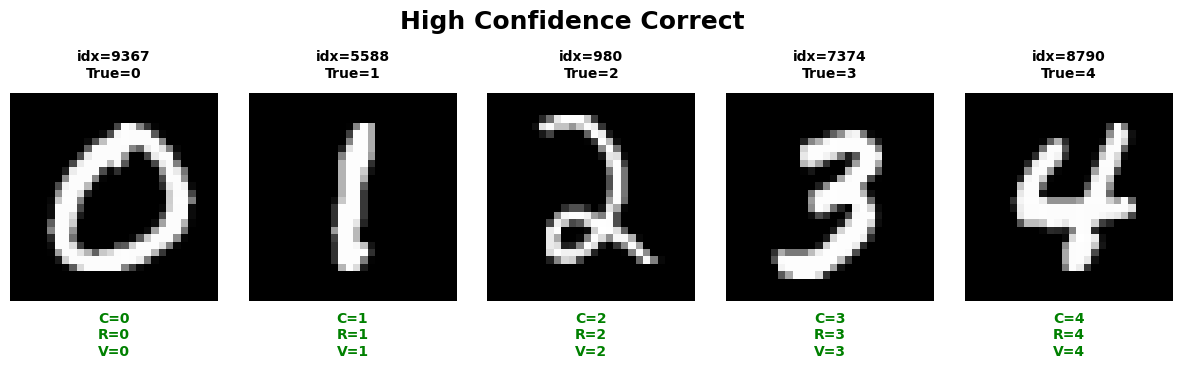

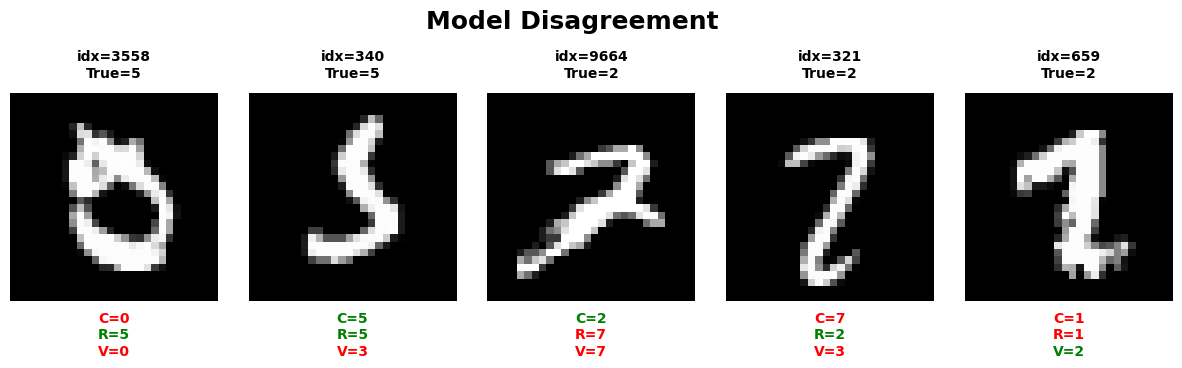

In [56]:
# @title
# 5.2.5 Visual inspection of selected sample groups
MODEL_COLORS = {
    True: "green",
    False: "red"
}

def plot_xai_sample_group(category, max_images=8):
    indices = XAI_SAMPLE_INDICES[category][:max_images]
    if len(indices) == 0:
        print(f"No samples available for category: {category}")
        return
    n = len(indices)
    fig, axes = plt.subplots(
        1,
        n,
        figsize=(3 * n, 4)
    )
    axes = np.atleast_1d(axes)
    for ax, idx in zip(axes, indices):
        image = X_test_cnn[idx].squeeze()
        true_label = y_test[idx]
        cnn_pred = DL_PREDICTIONS["CNN"][idx]
        res_pred = DL_PREDICTIONS["ResNet-9"][idx]
        vit_pred = DL_PREDICTIONS["Tiny-ViT"][idx]
        ax.imshow(image, cmap="gray")
        ax.axis("off")

        # Main title
        ax.set_title(
            f"idx={idx}\nTrue={true_label}",
            fontsize=10,
            pad=12,
            fontweight="bold"
        )

        # Colored prediction text
        ax.text(
            0.5, -0.10,
            f"C={cnn_pred}",
            transform=ax.transAxes,
            ha="center",
            color=MODEL_COLORS[cnn_pred == true_label],
            fontsize=10,
            fontweight="bold"
        )
        ax.text(
            0.5, -0.18,
            f"R={res_pred}",
            transform=ax.transAxes,
            ha="center",
            color=MODEL_COLORS[res_pred == true_label],
            fontsize=10,
            fontweight="bold"
        )
        ax.text(
            0.5, -0.26,
            f"V={vit_pred}",
            transform=ax.transAxes,
            ha="center",
            color=MODEL_COLORS[vit_pred == true_label],
            fontsize=10,
            fontweight="bold"
        )

    # Group title
    fig.suptitle(
        category.replace("_", " ").title(),
        fontsize=18,
        fontweight="bold",
        y=0.98
    )
    plt.subplots_adjust(
        top=0.82,
        bottom=0.20,
        wspace=0.15
    )
    plt.show()

plot_xai_sample_group(
    "high_confidence_correct",
    max_images=5
)

plot_xai_sample_group(
    "model_disagreement",
    max_images=5
)


## 5.3 Explainability for Traditional Machine Learning

Traditional machine-learning models process each MNIST image as a flattened
784-dimensional feature vector. Therefore, their explanations differ from
feature-map-based methods such as Grad-CAM.

This section uses:

- **KNN:** example-based explanation through nearest training samples.
- **Random Forest:** global pixel importance from fitted feature importances.
- **SVM:** model-agnostic occlusion sensitivity using decision-function scores.

The same MNIST test images and preprocessing pipeline from the previous sections
are retained to ensure consistency.


In [57]:
# @title
# 5.3.0 Common utilities for traditional ML explanations
def _get_existing_prediction(variable_name, model):
    """
    Reuse predictions already computed earlier in the notebook.
    If unavailable, compute them from X_test_flat.
    """
    if variable_name in globals():
        return np.asarray(globals()[variable_name])

    return np.asarray(model.predict(X_test_flat))

ML_PREDICTIONS = {
    "KNN": _get_existing_prediction("y_pred_knn", knn),
    "SVM": _get_existing_prediction("y_pred_svm", svm_pipeline),
    "Random Forest": _get_existing_prediction("y_pred_rf", rf),
}

def get_ml_example_index(model_name, correct=True):
    """
    Select a deterministic test sample for a specific ML model.

    Priority:
    1. Use samples already included in XAI_SAMPLE_INDICES.
    2. Fall back to the complete MNIST test set.
    """
    if model_name not in ML_PREDICTIONS:
        raise KeyError(
            f"Unknown model: {model_name}. "
            f"Available models: {list(ML_PREDICTIONS.keys())}"
        )

    predictions = ML_PREDICTIONS[model_name]

    if correct:
        preferred_categories = [
            "high_confidence_correct",
            "low_confidence",
            "model_disagreement",
        ]
        condition = predictions == y_test
    else:
        preferred_categories = [
            "misclassified",
            "model_disagreement",
            "low_confidence",
        ]
        condition = predictions != y_test

    # First search among the reproducible XAI sample groups.
    for category in preferred_categories:
        for idx in XAI_SAMPLE_INDICES.get(category, []):
            if condition[idx]:
                return int(idx)

    # Fall back to the full test set.
    candidates = np.where(condition)[0]

    if len(candidates) == 0:
        return None

    return int(candidates[0])



print("Traditional ML predictions are ready.")

for model_name, predictions in ML_PREDICTIONS.items():
    correct_idx = get_ml_example_index(model_name, correct=True)
    wrong_idx = get_ml_example_index(model_name, correct=False)

    print(
        f"{model_name:<14} | "
        f"correct sample: {correct_idx} | "
        f"incorrect sample: {wrong_idx}"
    )

Traditional ML predictions are ready.
KNN            | correct sample: 9367 | incorrect sample: 1014
SVM            | correct sample: 9367 | incorrect sample: 1014
Random Forest  | correct sample: 9367 | incorrect sample: 1014


### 5.3.1 KNN neighbor-based explanation

In [58]:
# @title
# 5.3.1 KNN neighbor-based explanation

def get_knn_training_reference():
    """
    Return the exact training data used by the fitted KNN model.
    """
    if "X_knn_train" in globals() and "y_knn_train" in globals():
        return np.asarray(X_knn_train), np.asarray(y_knn_train)

    # Fallback to fitted sklearn attributes.
    if hasattr(knn, "_fit_X") and hasattr(knn, "_y"):
        return np.asarray(knn._fit_X), np.asarray(knn._y)

    raise RuntimeError(
        "Unable to locate the training samples used by KNN. "
        "Run the KNN training cell again."
    )


def explain_knn(test_index, n_neighbors=None):
    """
    Generate a local example-based explanation for one MNIST test image.

    Parameters
    ----------
    test_index : int
        Index of the image in X_test_cnn / X_test_flat.

    n_neighbors : int or None
        Number of neighbors shown. By default, use the same k as the
        fitted KNN model so the visualization represents the actual decision.
    """
    if not 0 <= test_index < len(X_test_cnn):
        raise IndexError(f"Invalid test index: {test_index}")

    X_reference, y_reference = get_knn_training_reference()

    if n_neighbors is None:
        n_neighbors = int(knn.n_neighbors)

    query_image = X_test_cnn[test_index]
    query_flat = query_image.reshape(1, -1)

    distances, neighbor_indices = knn.kneighbors(
        query_flat,
        n_neighbors=n_neighbors,
        return_distance=True
    )

    distances = distances[0]
    neighbor_indices = neighbor_indices[0]
    neighbor_labels = y_reference[neighbor_indices]

    prediction = int(knn.predict(query_flat)[0])
    true_label = int(y_test[test_index])

    unique_labels, vote_counts = np.unique(
        neighbor_labels,
        return_counts=True
    )

    vote_distribution = {
        int(label): int(count)
        for label, count in zip(unique_labels, vote_counts)
    }

    return {
        "test_index": int(test_index),
        "query_image": query_image.squeeze(),
        "true_label": true_label,
        "prediction": prediction,
        "correct": prediction == true_label,
        "neighbor_indices": neighbor_indices,
        "neighbor_images": X_reference[neighbor_indices].reshape(-1, 28, 28),
        "neighbor_labels": neighbor_labels,
        "neighbor_distances": distances,
        "vote_distribution": vote_distribution,
    }


def plot_knn_explanation(test_index, n_neighbors=None):
    explanation = explain_knn(
        test_index=test_index,
        n_neighbors=n_neighbors
    )

    k = len(explanation["neighbor_labels"])

    fig = plt.figure(figsize=(3.0 * (k + 2), 4.4))

    grid = fig.add_gridspec(
        1,
        k + 2,
        width_ratios=[1.15] + [1] * k + [1.25],
        wspace=0.35
    )

    # Query image

    query_ax = fig.add_subplot(grid[0, 0])

    query_ax.imshow(
        explanation["query_image"],
        cmap="gray"
    )

    query_color = (
        "green" if explanation["correct"] else "red"
    )

    query_ax.set_title(
        f"Query idx={test_index}\n"
        f"True={explanation['true_label']} | "
        f"Pred={explanation['prediction']}",
        color=query_color,
        fontsize=11,
        fontweight="bold",
        pad=10
    )

    query_ax.axis("off")

    # Actual nearest neighbors
    for rank in range(k):
        ax = fig.add_subplot(grid[0, rank + 1])

        neighbor_label = int(
            explanation["neighbor_labels"][rank]
        )

        distance = float(
            explanation["neighbor_distances"][rank]
        )

        supports_prediction = (
            neighbor_label == explanation["prediction"]
        )

        title_color = "green" if supports_prediction else "red"

        ax.imshow(
            explanation["neighbor_images"][rank],
            cmap="gray"
        )

        ax.set_title(
            f"Neighbor {rank + 1}\n"
            f"Label={neighbor_label}\n"
            f"Distance={distance:.3f}",
            color=title_color,
            fontsize=10,
            fontweight="bold"
        )

        ax.axis("off")

    # Vote distribution
    vote_ax = fig.add_subplot(grid[0, -1])

    vote_labels = list(
        explanation["vote_distribution"].keys()
    )

    vote_counts = list(
        explanation["vote_distribution"].values()
    )

    vote_colors = [
        "green"
        if label == explanation["prediction"]
        else "red"
        for label in vote_labels
    ]

    vote_ax.bar(
        [str(label) for label in vote_labels],
        vote_counts,
        color=vote_colors,
        alpha=0.8
    )

    vote_ax.set_title(
        "Neighbor Votes",
        fontsize=11,
        fontweight="bold"
    )

    vote_ax.set_xlabel("Digit")
    vote_ax.set_ylabel("Votes")
    vote_ax.set_ylim(0, k + 0.5)
    vote_ax.grid(axis="y", alpha=0.25)

    status = "Correct prediction" if explanation["correct"] else "Incorrect prediction"

    fig.suptitle(
        f"KNN Local Explanation — {status}",
        fontsize=16,
        fontweight="bold",
        y=0.98
    )

    plt.subplots_adjust(
        top=0.76,
        bottom=0.15
    )

    plt.show()

    return explanation

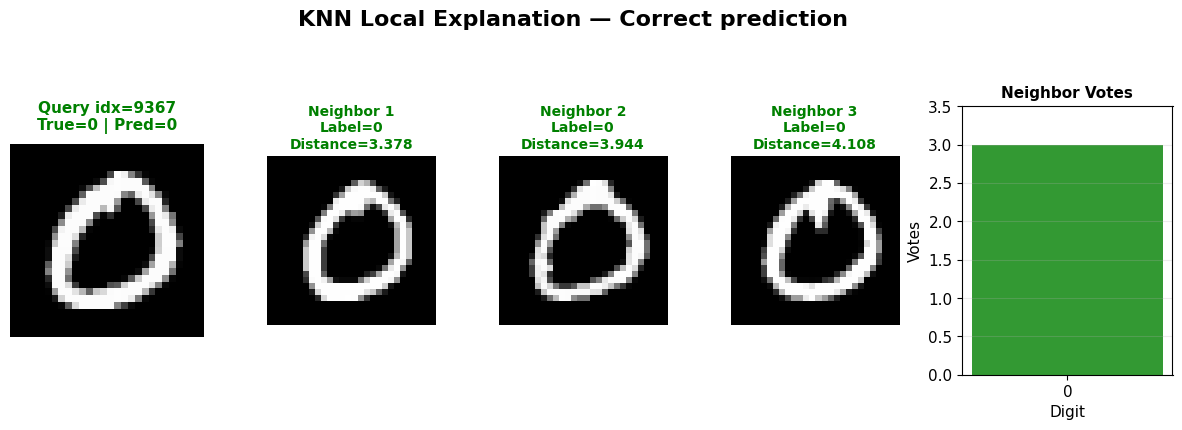

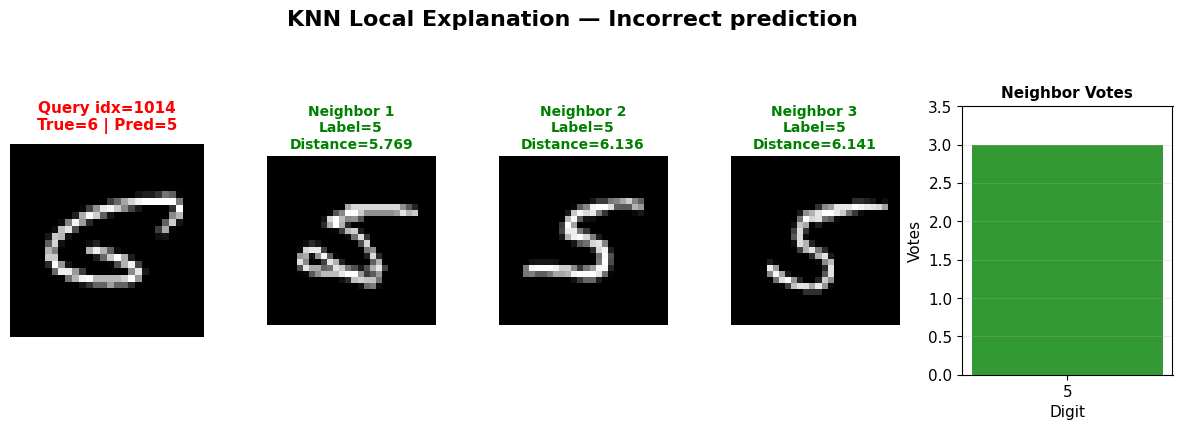

In [59]:
# @title
# Correct KNN prediction
knn_correct_idx = get_ml_example_index(
    "KNN",
    correct=True
)

if knn_correct_idx is not None:
    knn_correct_explanation = plot_knn_explanation(
        knn_correct_idx
    )


# Incorrect KNN prediction
knn_wrong_idx = get_ml_example_index(
    "KNN",
    correct=False
)

if knn_wrong_idx is not None:
    knn_wrong_explanation = plot_knn_explanation(
        knn_wrong_idx
    )
else:
    print("No incorrect KNN sample was found.")

### 5.3.2 Random Forest global pixel importance

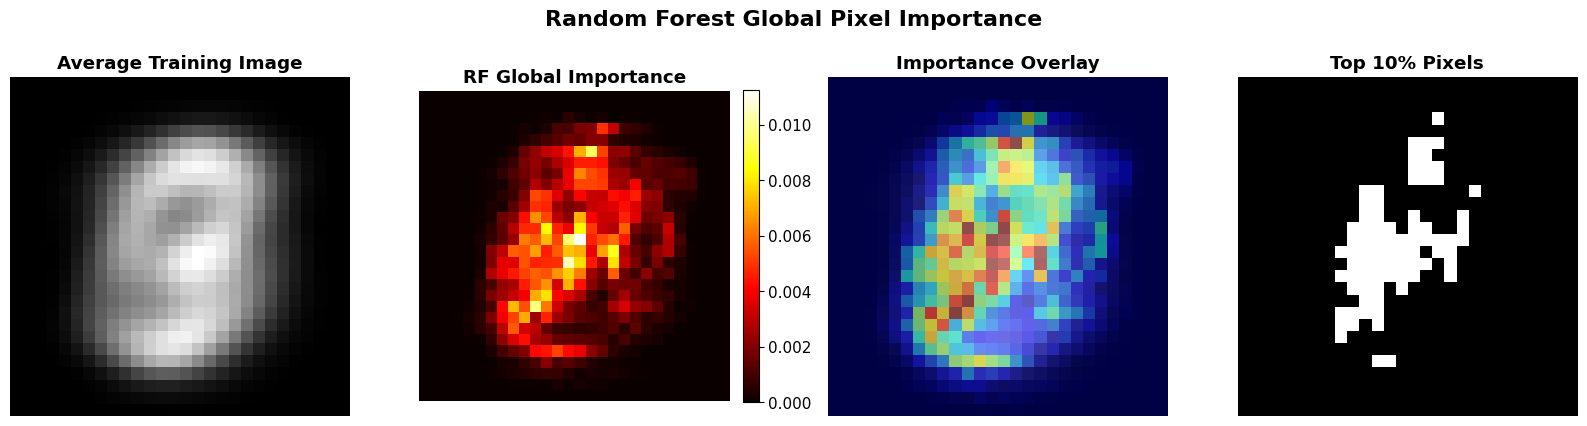

Importance located on average foreground strokes: 93.13%


In [60]:
# @title
# 5.3.2 Random Forest global pixel importance

def plot_rf_global_importance(
    rf_model=rf,
    percentile_threshold=90
):
    """
    Visualize global Random Forest pixel importance.
    """
    if not hasattr(rf_model, "feature_importances_"):
        raise AttributeError(
            "The Random Forest model does not contain feature_importances_."
        )

    pixel_importance = rf_model.feature_importances_.reshape(28, 28)

    normalized_importance = normalize_xai_map(
        pixel_importance
    )

    average_digit = np.mean(
        X_train_cnn,
        axis=0
    ).squeeze()

    threshold = np.percentile(
        pixel_importance,
        percentile_threshold
    )

    important_pixel_mask = pixel_importance >= threshold

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4.2)
    )

    # Average MNIST image
    axes[0].imshow(
        average_digit,
        cmap="gray"
    )
    axes[0].set_title(
        "Average Training Image",
        fontweight="bold"
    )
    axes[0].axis("off")

    # Raw importance
    importance_display = axes[1].imshow(
        pixel_importance,
        cmap="hot"
    )
    axes[1].set_title(
        "RF Global Importance",
        fontweight="bold"
    )
    axes[1].axis("off")

    fig.colorbar(
        importance_display,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    # Overlay
    axes[2].imshow(
        average_digit,
        cmap="gray"
    )
    axes[2].imshow(
        normalized_importance,
        cmap="jet",
        alpha=0.55
    )
    axes[2].set_title(
        "Importance Overlay",
        fontweight="bold"
    )
    axes[2].axis("off")

    # Top important pixels
    axes[3].imshow(
        important_pixel_mask,
        cmap="gray"
    )
    axes[3].set_title(
        f"Top {100 - percentile_threshold}% Pixels",
        fontweight="bold"
    )
    axes[3].axis("off")

    fig.suptitle(
        "Random Forest Global Pixel Importance",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

    total_importance = float(pixel_importance.sum())

    stroke_mask = average_digit > 0.1

    stroke_importance = float(
        pixel_importance[stroke_mask].sum()
    )

    foreground_ratio = (
        stroke_importance / total_importance
        if total_importance > 0
        else 0
    )

    print(
        f"Importance located on average foreground strokes: "
        f"{foreground_ratio:.2%}"
    )

    return pixel_importance

RF_GLOBAL_IMPORTANCE = plot_rf_global_importance()

### 5.3.3 Plot and display SVM occlusion explanation

In [61]:
# @title
# 5.3.3 SVM occlusion sensitivity - debug-safe version


def get_svm_estimator_from_pipeline():
    """
    Locate the actual SVM/SVC estimator inside svm_pipeline.
    This avoids depending on a fixed pipeline step name such as 'svm'.
    """
    if hasattr(svm_pipeline, "named_steps"):
        for step_name, step in svm_pipeline.named_steps.items():
            if hasattr(step, "classes_") and hasattr(step, "decision_function"):
                return step_name, step

    if hasattr(svm_pipeline, "classes_") and hasattr(svm_pipeline, "decision_function"):
        return "svm_pipeline", svm_pipeline

    raise RuntimeError(
        "Could not find an SVM estimator with classes_ and decision_function."
    )


SVM_STEP_NAME, SVM_ESTIMATOR = get_svm_estimator_from_pipeline()

print(f"Detected SVM step: {SVM_STEP_NAME}")
print(f"SVM classes: {SVM_ESTIMATOR.classes_}")


def get_svm_class_scores(image_batch):
    """
    Return raw SVM decision-function scores and their class order.
    Input shape: (N, 28, 28, 1)
    """
    image_batch = np.asarray(image_batch, dtype=np.float32)

    if image_batch.ndim == 3:
        image_batch = image_batch[..., np.newaxis]

    flat_batch = image_batch.reshape(len(image_batch), -1)

    scores = svm_pipeline.decision_function(flat_batch)
    scores = np.asarray(scores)

    if scores.ndim == 1:
        scores = scores[:, np.newaxis]

    return scores, np.asarray(SVM_ESTIMATOR.classes_)


def create_patch_positions(image_height, image_width, patch_size, stride):
    y_positions = list(range(0, image_height - patch_size + 1, stride))
    x_positions = list(range(0, image_width - patch_size + 1, stride))

    last_y = image_height - patch_size
    last_x = image_width - patch_size

    if len(y_positions) == 0 or y_positions[-1] != last_y:
        y_positions.append(last_y)

    if len(x_positions) == 0 or x_positions[-1] != last_x:
        x_positions.append(last_x)

    return [(y, x) for y in y_positions for x in x_positions]


def compute_svm_occlusion(
    test_index,
    target_class=None,
    patch_size=4,
    stride=2,
    baseline=0.0,
    verbose=True
):
    """
    Compute a signed occlusion sensitivity map for one SVM prediction.
    """
    test_index = int(test_index)

    if not 0 <= test_index < len(X_test_cnn):
        raise IndexError(f"Invalid test_index: {test_index}")

    image = np.asarray(X_test_cnn[test_index], dtype=np.float32)

    if image.ndim == 2:
        image = image[..., np.newaxis]

    original_flat = image.reshape(1, -1)

    prediction = int(svm_pipeline.predict(original_flat)[0])
    true_label = int(y_test[test_index])

    if target_class is None:
        target_class = prediction

    target_class = int(target_class)

    original_scores, svm_classes = get_svm_class_scores(image[np.newaxis, ...])

    target_positions = np.where(svm_classes == target_class)[0]

    if len(target_positions) == 0:
        raise ValueError(
            f"Target class {target_class} was not found in SVM classes {svm_classes}."
        )

    target_position = int(target_positions[0])
    original_target_score = float(original_scores[0, target_position])

    patch_positions = create_patch_positions(
        image_height=28,
        image_width=28,
        patch_size=patch_size,
        stride=stride
    )

    if verbose:
        print(
            f"SVM occlusion | idx={test_index} | "
            f"true={true_label} | pred={prediction} | "
            f"target={target_class} | patches={len(patch_positions)}"
        )

    occluded_images = []

    for y, x in patch_positions:
        occluded = image.copy()
        occluded[y:y + patch_size, x:x + patch_size, 0] = baseline
        occluded_images.append(occluded)

    occluded_images = np.asarray(occluded_images, dtype=np.float32)

    occluded_scores, _ = get_svm_class_scores(occluded_images)

    score_drops = original_target_score - occluded_scores[:, target_position]

    heatmap_sum = np.zeros((28, 28), dtype=np.float32)
    coverage_count = np.zeros((28, 28), dtype=np.float32)

    for (y, x), score_drop in zip(patch_positions, score_drops):
        heatmap_sum[y:y + patch_size, x:x + patch_size] += score_drop
        coverage_count[y:y + patch_size, x:x + patch_size] += 1

    heatmap = np.divide(
        heatmap_sum,
        coverage_count,
        out=np.zeros_like(heatmap_sum),
        where=coverage_count > 0
    )

    most_important_patch_index = int(np.argmax(score_drops))
    most_important_position = patch_positions[most_important_patch_index]

    return {
        "test_index": test_index,
        "image": image.squeeze(),
        "true_label": true_label,
        "prediction": prediction,
        "target_class": target_class,
        "original_target_score": original_target_score,
        "heatmap": heatmap,
        "score_drops": score_drops,
        "patch_positions": patch_positions,
        "most_important_position": most_important_position,
        "patch_size": int(patch_size),
        "stride": int(stride),
        "baseline": float(baseline),
    }


print("SVM occlusion computation functions are ready.")

Detected SVM step: svm
SVM classes: [0 1 2 3 4 5 6 7 8 9]
SVM occlusion computation functions are ready.


SVM correct samples: 9596
SVM wrong samples: 404
Selected correct idx: 9367
Selected wrong idx: 1014
SVM occlusion | idx=9367 | true=0 | pred=0 | target=0 | patches=169


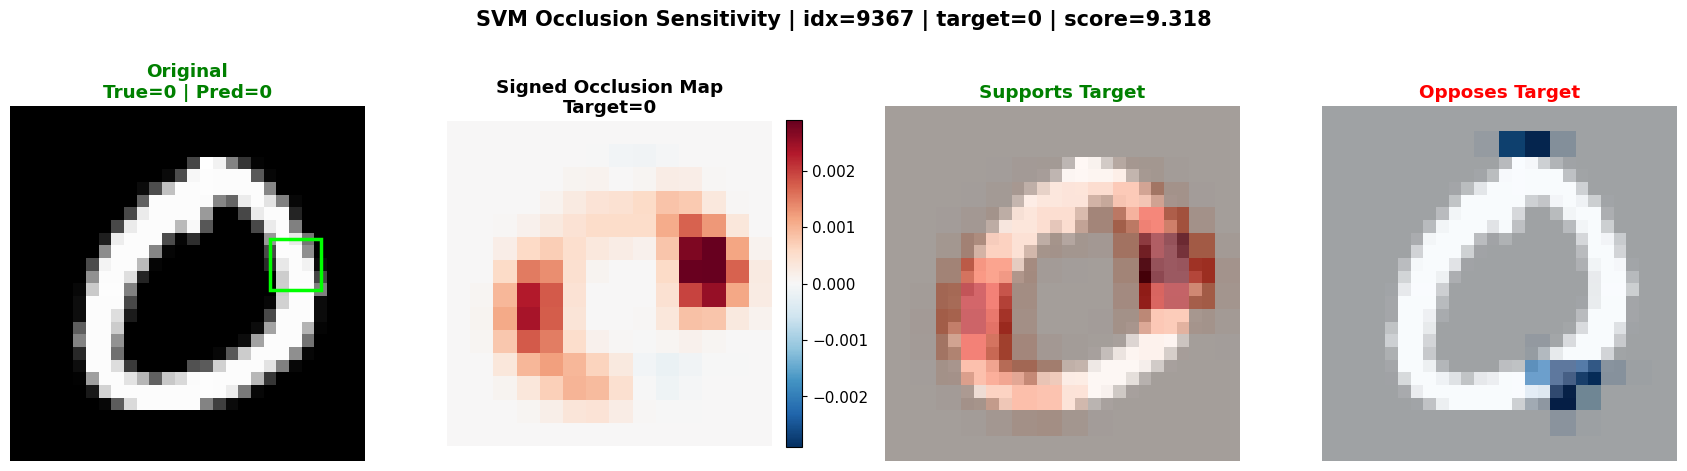

SVM occlusion | idx=1014 | true=6 | pred=5 | target=5 | patches=169


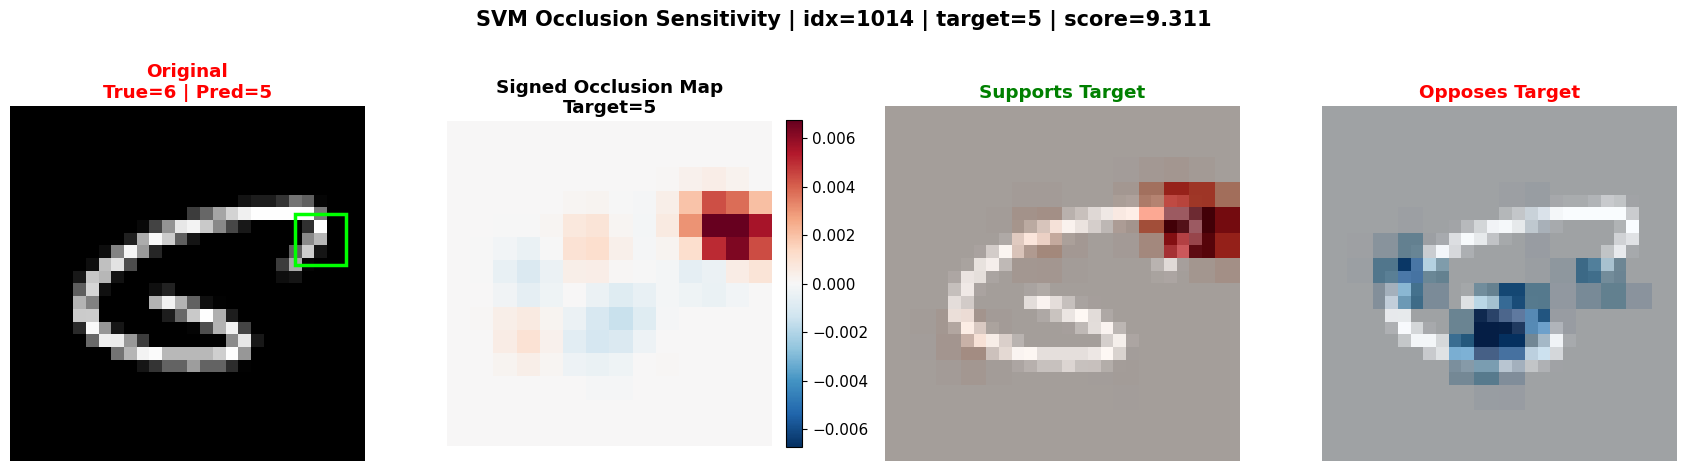

In [62]:
# @title
# 5.3.3 Plot and display SVM occlusion explanation

def plot_svm_occlusion(
    test_index,
    target_class=None,
    patch_size=4,
    stride=2,
    baseline=0.0
):
    explanation = compute_svm_occlusion(
        test_index=test_index,
        target_class=target_class,
        patch_size=patch_size,
        stride=stride,
        baseline=baseline,
        verbose=True
    )

    image = explanation["image"]
    heatmap = explanation["heatmap"]

    signed_scale = np.percentile(np.abs(heatmap), 99)

    if signed_scale <= 1e-12:
        signed_scale = 1.0

    positive_map = np.maximum(heatmap, 0)
    negative_map = np.maximum(-heatmap, 0)

    positive_map = positive_map / (np.percentile(positive_map, 99) + 1e-12)
    negative_map = negative_map / (np.percentile(negative_map, 99) + 1e-12)

    positive_map = np.clip(positive_map, 0, 1)
    negative_map = np.clip(negative_map, 0, 1)

    top_y, top_x = explanation["most_important_position"]

    fig, axes = plt.subplots(1, 4, figsize=(17, 4.8))

    axes[0].imshow(image, cmap="gray")

    rectangle = Rectangle(
        (top_x, top_y),
        explanation["patch_size"],
        explanation["patch_size"],
        linewidth=2.5,
        edgecolor="lime",
        facecolor="none"
    )

    axes[0].add_patch(rectangle)

    axes[0].set_title(
        f"Original\nTrue={explanation['true_label']} | "
        f"Pred={explanation['prediction']}",
        color=(
            "green"
            if explanation["prediction"] == explanation["true_label"]
            else "red"
        ),
        fontweight="bold"
    )

    axes[0].axis("off")

    signed_display = axes[1].imshow(
        heatmap,
        cmap="RdBu_r",
        vmin=-signed_scale,
        vmax=signed_scale
    )

    axes[1].set_title(
        f"Signed Occlusion Map\nTarget={explanation['target_class']}",
        fontweight="bold"
    )

    axes[1].axis("off")

    fig.colorbar(
        signed_display,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    axes[2].imshow(image, cmap="gray")
    axes[2].imshow(positive_map, cmap="Reds", alpha=0.65)
    axes[2].set_title(
        "Supports Target",
        color="green",
        fontweight="bold"
    )
    axes[2].axis("off")

    axes[3].imshow(image, cmap="gray")
    axes[3].imshow(negative_map, cmap="Blues", alpha=0.65)
    axes[3].set_title(
        "Opposes Target",
        color="red",
        fontweight="bold"
    )
    axes[3].axis("off")

    fig.suptitle(
        f"SVM Occlusion Sensitivity | "
        f"idx={explanation['test_index']} | "
        f"target={explanation['target_class']} | "
        f"score={explanation['original_target_score']:.3f}",
        fontsize=15,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()
    plt.show()

    return explanation

# Select samples robustly
svm_predictions = np.asarray(svm_pipeline.predict(X_test_flat))

svm_correct_candidates = np.where(svm_predictions == y_test)[0]
svm_wrong_candidates = np.where(svm_predictions != y_test)[0]

print(f"SVM correct samples: {len(svm_correct_candidates)}")
print(f"SVM wrong samples: {len(svm_wrong_candidates)}")


# Prefer XAI sample groups, but always fall back to full test set.
svm_correct_idx = get_ml_example_index("SVM", correct=True)

if svm_correct_idx is None and len(svm_correct_candidates) > 0:
    svm_correct_idx = int(svm_correct_candidates[0])

svm_wrong_idx = get_ml_example_index("SVM", correct=False)

if svm_wrong_idx is None and len(svm_wrong_candidates) > 0:
    svm_wrong_idx = int(svm_wrong_candidates[0])


print(f"Selected correct idx: {svm_correct_idx}")
print(f"Selected wrong idx: {svm_wrong_idx}")


# Plot correct sample
if svm_correct_idx is not None:
    svm_correct_occlusion = plot_svm_occlusion(
        svm_correct_idx,
        patch_size=4,
        stride=2
    )
else:
    print("No correct SVM sample was found.")

# Plot incorrect sample
if svm_wrong_idx is not None:
    svm_wrong_prediction = int(svm_predictions[svm_wrong_idx])
    svm_wrong_true_class = int(y_test[svm_wrong_idx])

    svm_wrong_predicted_occlusion = plot_svm_occlusion(
        svm_wrong_idx,
        target_class=svm_wrong_prediction,
        patch_size=4,
        stride=2
    )
else:
    print("No incorrect SVM sample was found.")

## 5.4 Input Attribution for Deep Learning

In [63]:
# @title
# Config
if "DL_MODELS" not in globals():
    DL_MODELS = {
        "CNN": standard_cnn,
        "ResNet-9": resnet_model,
        "Tiny-ViT": tinyvit_model,
    }

if "DL_LOGIT_MODELS" not in globals():
    if "build_logit_model" not in globals():
        raise RuntimeError(
            "Re-run pre-softmax logit models cell in Section 5.2.3."
        )

    DL_LOGIT_MODELS = {
        name: build_logit_model(model)
        for name, model in DL_MODELS.items()
    }

DL_MODEL_NAMES = [
    "CNN",
    "ResNet-9",
    "Tiny-ViT"
]


def get_dl_prediction(model_name, image):
    image_batch = prepare_xai_image(image)

    probabilities = DL_MODELS[model_name](
        image_batch,
        training=False
    ).numpy()[0]

    prediction = int(np.argmax(probabilities))
    confidence = float(probabilities[prediction])

    return {
        "probabilities": probabilities,
        "prediction": prediction,
        "confidence": confidence,
    }


def select_dl_xai_index(category, fallback_category=None):
    indices = XAI_SAMPLE_INDICES.get(category, [])

    if len(indices) > 0:
        return int(indices[0])

    if fallback_category is not None:
        fallback_indices = XAI_SAMPLE_INDICES.get(
            fallback_category,
            []
        )

        if len(fallback_indices) > 0:
            return int(fallback_indices[0])

    return 0


print("Deep-learning XAI models are ready.")

for model_name in DL_MODEL_NAMES:
    print(
        f"{model_name:<10} | "
        f"probability model: {DL_MODELS[model_name].name} | "
        f"logit model: {DL_LOGIT_MODELS[model_name].name}"
    )

Deep-learning XAI models are ready.
CNN        | probability model: sequential_7 | logit model: sequential_7_LogitModel
ResNet-9   | probability model: Custom_ResNet | logit model: Custom_ResNet_LogitModel
Tiny-ViT   | probability model: TinyViT | logit model: TinyViT_LogitModel


### 5.4.1 Vanilla Saliency

In [64]:
# @title
# Vanilla Saliency computation
def compute_vanilla_saliency(
    model_name,
    image,
    target_class=None,
    absolute=True
):
    if model_name not in DL_LOGIT_MODELS:
        raise KeyError(
            f"Unknown model: {model_name}. "
            f"Available models: {list(DL_LOGIT_MODELS.keys())}"
        )

    image_batch = prepare_xai_image(image)
    image_tensor = tf.convert_to_tensor(
        image_batch,
        dtype=tf.float32
    )

    prediction_info = get_dl_prediction(
        model_name,
        image
    )

    prediction = prediction_info["prediction"]
    confidence = prediction_info["confidence"]

    if target_class is None:
        target_class = prediction

    target_class = int(target_class)

    logit_model = DL_LOGIT_MODELS[model_name]

    with tf.GradientTape() as tape:
        tape.watch(image_tensor)

        logits = logit_model(
            image_tensor,
            training=False
        )

        target_score = logits[:, target_class]

    gradients = tape.gradient(
        target_score,
        image_tensor
    )

    if gradients is None:
        raise RuntimeError(
            f"Gradient could not be computed for {model_name}."
        )

    gradients = gradients.numpy()[0]

    signed_saliency = gradients.squeeze()

    if absolute:
        saliency = np.abs(signed_saliency)
    else:
        saliency = signed_saliency

    normalized_saliency = normalize_xai_map(
        np.abs(saliency)
    )

    return {
        "model_name": model_name,
        "image": image_batch[0].squeeze(),
        "prediction": prediction,
        "confidence": confidence,
        "target_class": target_class,
        "target_score": float(target_score.numpy()[0]),
        "signed_saliency": signed_saliency,
        "saliency": saliency,
        "normalized_saliency": normalized_saliency,
    }

In [65]:
# @title
# Plot Vanilla Saliency for 3 Model
def plot_saliency_comparison(
    test_index,
    target_mode="predicted"
):
    test_index = int(test_index)

    image = X_test_cnn[test_index]
    true_label = int(y_test[test_index])

    fig, axes = plt.subplots(
        len(DL_MODEL_NAMES),
        3,
        figsize=(12, 4.2 * len(DL_MODEL_NAMES))
    )

    for row, model_name in enumerate(DL_MODEL_NAMES):
        prediction_info = get_dl_prediction(
            model_name,
            image
        )

        prediction = prediction_info["prediction"]
        confidence = prediction_info["confidence"]

        if target_mode == "predicted":
            target_class = prediction

        elif target_mode == "true":
            target_class = true_label

        elif isinstance(target_mode, int):
            target_class = int(target_mode)

        else:
            raise ValueError(
                "target_mode must be 'predicted', 'true', or an integer class."
            )

        explanation = compute_vanilla_saliency(
            model_name=model_name,
            image=image,
            target_class=target_class
        )

        correct = prediction == true_label
        title_color = "green" if correct else "red"

        axes[row, 0].imshow(
            explanation["image"],
            cmap="gray"
        )

        axes[row, 0].set_title(
            f"{model_name}\n"
            f"True={true_label} | Pred={prediction}\n"
            f"Confidence={confidence:.4f}",
            color=title_color,
            fontweight="bold"
        )

        axes[row, 0].axis("off")

        saliency_display = axes[row, 1].imshow(
            explanation["normalized_saliency"],
            cmap="hot",
            vmin=0,
            vmax=1
        )

        axes[row, 1].set_title(
            f"Vanilla Saliency\nTarget={target_class}",
            fontweight="bold"
        )

        axes[row, 1].axis("off")

        fig.colorbar(
            saliency_display,
            ax=axes[row, 1],
            fraction=0.046,
            pad=0.04
        )

        axes[row, 2].imshow(
            explanation["image"],
            cmap="gray"
        )

        saliency_masked = np.ma.masked_where(
            explanation["normalized_saliency"] < 0.05,
            explanation["normalized_saliency"]
        )

        axes[row, 2].imshow(
            saliency_masked,
            cmap="jet",
            alpha=0.65,
            vmin=0,
            vmax=1
        )

        axes[row, 2].set_title(
            "Saliency Overlay",
            fontweight="bold"
        )

        axes[row, 2].axis("off")

    target_description = (
        "Predicted Class"
        if target_mode == "predicted"
        else "True Class"
        if target_mode == "true"
        else f"Class {target_mode}"
    )

    fig.suptitle(
        f"Vanilla Saliency Comparison — "
        f"Test idx={test_index} — "
        f"Target: {target_description}",
        fontsize=17,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()

Selected correct sample: idx=9367, true=0


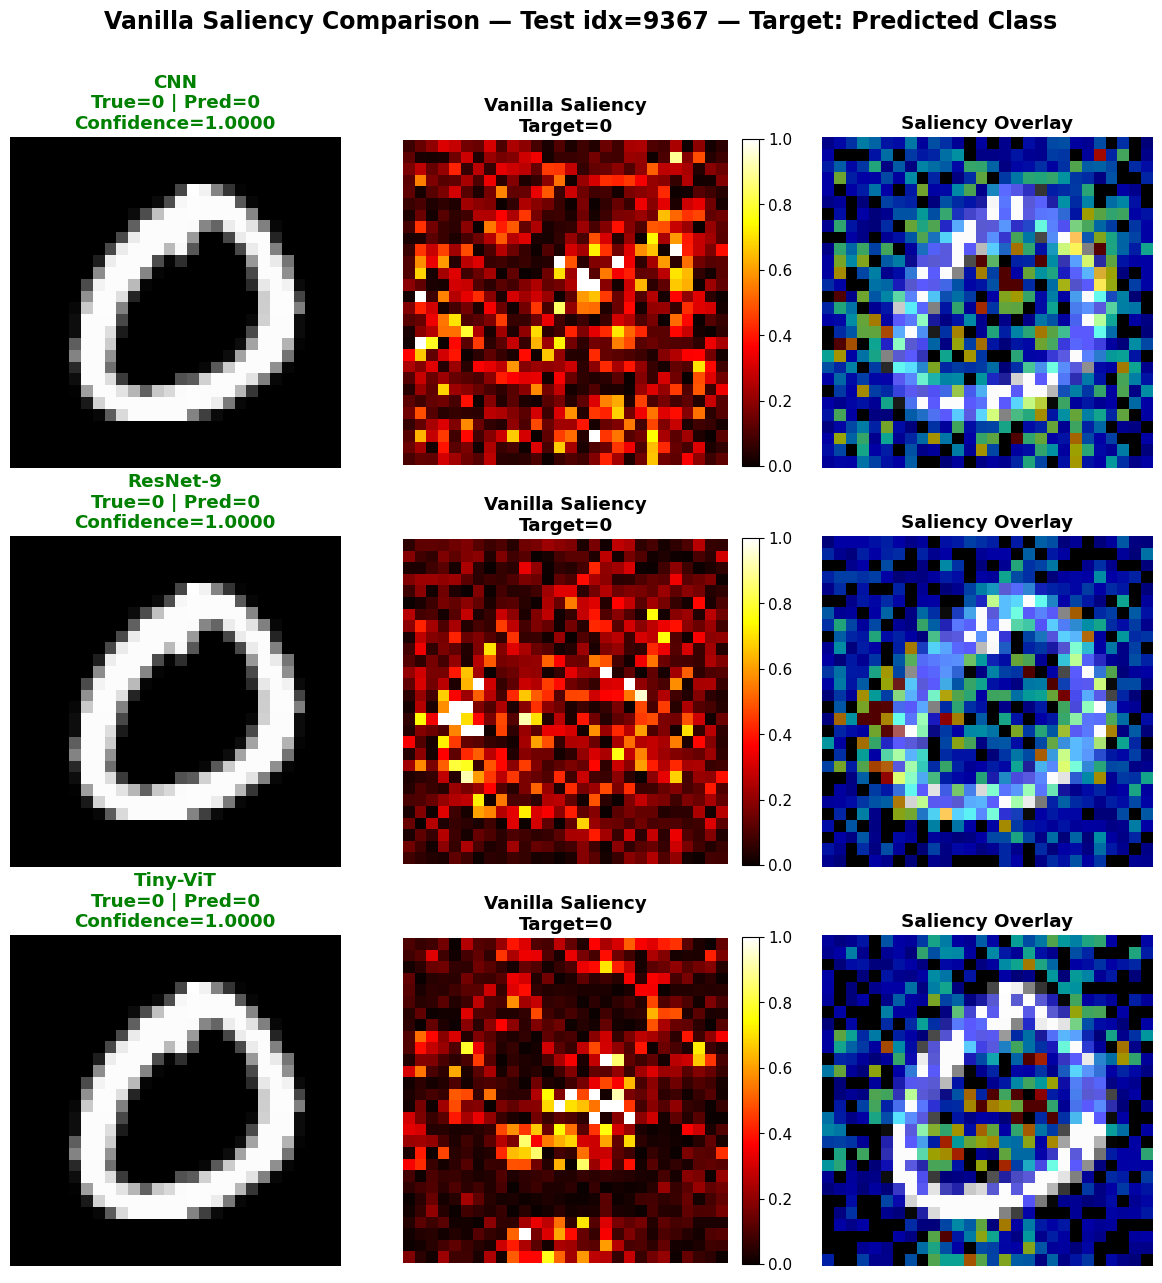

In [66]:
# @title
# Vanilla Saliency
saliency_correct_idx = select_dl_xai_index(
    "high_confidence_correct",
    fallback_category="low_confidence"
)

print(
    f"Selected correct sample: idx={saliency_correct_idx}, "
    f"true={y_test[saliency_correct_idx]}"
)

plot_saliency_comparison(
    test_index=saliency_correct_idx,
    target_mode="predicted"
)


### 5.4.2 Integrated Gradients

In [67]:
# @title
def compute_integrated_gradients(
    model_name,
    image,
    target_class=None,
    baseline=None,
    steps=50
):
    if model_name not in DL_LOGIT_MODELS:
        raise KeyError(
            f"Unknown model: {model_name}. "
            f"Available models: {list(DL_LOGIT_MODELS.keys())}"
        )

    if steps < 2:
        raise ValueError("steps must be at least 2.")

    image_batch = prepare_xai_image(image)
    image_tensor = tf.convert_to_tensor(
        image_batch,
        dtype=tf.float32
    )

    if baseline is None:
        baseline_tensor = tf.zeros_like(
            image_tensor
        )

    else:
        baseline_batch = prepare_xai_image(
            baseline
        )

        baseline_tensor = tf.convert_to_tensor(
            baseline_batch,
            dtype=tf.float32
        )

    prediction_info = get_dl_prediction(
        model_name,
        image
    )

    prediction = prediction_info["prediction"]
    confidence = prediction_info["confidence"]

    if target_class is None:
        target_class = prediction

    target_class = int(target_class)

    alphas = tf.linspace(
        start=0.0,
        stop=1.0,
        num=steps + 1
    )

    alphas = tf.reshape(
        alphas,
        (steps + 1, 1, 1, 1)
    )

    image_difference = (
        image_tensor - baseline_tensor
    )

    interpolated_images = (
        baseline_tensor
        + alphas * image_difference
    )

    logit_model = DL_LOGIT_MODELS[model_name]

    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)

        interpolated_logits = logit_model(
            interpolated_images,
            training=False
        )

        target_scores = interpolated_logits[
            :,
            target_class
        ]

    gradients = tape.gradient(
        target_scores,
        interpolated_images
    )

    if gradients is None:
        raise RuntimeError(
            f"Integrated Gradients could not be computed for {model_name}."
        )

    trapezoidal_gradients = (
        gradients[:-1] + gradients[1:]
    ) / 2.0

    average_gradients = tf.reduce_mean(
        trapezoidal_gradients,
        axis=0,
        keepdims=True
    )

    integrated_gradients = (
        image_difference * average_gradients
    )

    integrated_gradients = (
        integrated_gradients.numpy()[0].squeeze()
    )

    image_logits = logit_model(
        image_tensor,
        training=False
    ).numpy()[0]

    baseline_logits = logit_model(
        baseline_tensor,
        training=False
    ).numpy()[0]

    logit_difference = float(
        image_logits[target_class]
        - baseline_logits[target_class]
    )

    attribution_sum = float(
        np.sum(integrated_gradients)
    )

    completeness_error = abs(
        logit_difference - attribution_sum
    )

    positive_attribution = np.maximum(
        integrated_gradients,
        0
    )

    negative_attribution = np.maximum(
        -integrated_gradients,
        0
    )

    absolute_attribution = np.abs(
        integrated_gradients
    )

    return {
        "model_name": model_name,
        "image": image_batch[0].squeeze(),
        "baseline": baseline_tensor.numpy()[0].squeeze(),
        "prediction": prediction,
        "confidence": confidence,
        "target_class": target_class,
        "integrated_gradients": integrated_gradients,
        "positive_attribution": positive_attribution,
        "negative_attribution": negative_attribution,
        "absolute_attribution": absolute_attribution,
        "normalized_positive": normalize_xai_map(
            positive_attribution
        ),
        "normalized_negative": normalize_xai_map(
            negative_attribution
        ),
        "normalized_absolute": normalize_xai_map(
            absolute_attribution
        ),
        "logit_difference": logit_difference,
        "attribution_sum": attribution_sum,
        "completeness_error": completeness_error,
        "steps": int(steps),
    }

In [68]:
# @title
def plot_integrated_gradients_comparison(
    test_index,
    target_mode="predicted",
    steps=50
):
    test_index = int(test_index)

    image = X_test_cnn[test_index]
    true_label = int(y_test[test_index])

    fig, axes = plt.subplots(
        len(DL_MODEL_NAMES),
        4,
        figsize=(16, 4.2 * len(DL_MODEL_NAMES))
    )

    results = {}

    for row, model_name in enumerate(DL_MODEL_NAMES):
        prediction_info = get_dl_prediction(
            model_name,
            image
        )

        prediction = prediction_info["prediction"]
        confidence = prediction_info["confidence"]

        if target_mode == "predicted":
            target_class = prediction

        elif target_mode == "true":
            target_class = true_label

        elif isinstance(target_mode, int):
            target_class = int(target_mode)

        else:
            raise ValueError(
                "target_mode must be 'predicted', 'true', or an integer class."
            )

        explanation = compute_integrated_gradients(
            model_name=model_name,
            image=image,
            target_class=target_class,
            baseline=None,
            steps=steps
        )

        results[model_name] = explanation

        correct = prediction == true_label
        title_color = "green" if correct else "red"

        axes[row, 0].imshow(
            explanation["image"],
            cmap="gray"
        )

        axes[row, 0].set_title(
            f"{model_name}\n"
            f"True={true_label} | Pred={prediction}\n"
            f"Confidence={confidence:.4f}",
            color=title_color,
            fontweight="bold"
        )

        axes[row, 0].axis("off")

        signed_scale = get_signed_scale(
            explanation["integrated_gradients"]
        )

        signed_display = axes[row, 1].imshow(
            explanation["integrated_gradients"],
            cmap="RdBu_r",
            vmin=-signed_scale,
            vmax=signed_scale
        )

        axes[row, 1].set_title(
            f"Signed Integrated Gradients\n"
            f"Target={target_class}",
            fontweight="bold"
        )

        axes[row, 1].axis("off")

        fig.colorbar(
            signed_display,
            ax=axes[row, 1],
            fraction=0.046,
            pad=0.04
        )

        axes[row, 2].imshow(
            explanation["image"],
            cmap="gray"
        )

        positive_masked = np.ma.masked_where(
            explanation["normalized_positive"] < 0.05,
            explanation["normalized_positive"]
        )

        axes[row, 2].imshow(
            positive_masked,
            cmap="Reds",
            alpha=0.7,
            vmin=0,
            vmax=1
        )

        axes[row, 2].set_title(
            "Positive Attribution\nSupports Target",
            color="green",
            fontweight="bold"
        )

        axes[row, 2].axis("off")

        axes[row, 3].imshow(
            explanation["image"],
            cmap="gray"
        )

        negative_masked = np.ma.masked_where(
            explanation["normalized_negative"] < 0.05,
            explanation["normalized_negative"]
        )

        axes[row, 3].imshow(
            negative_masked,
            cmap="Blues",
            alpha=0.7,
            vmin=0,
            vmax=1
        )

        axes[row, 3].set_title(
            "Negative Attribution\nOpposes Target",
            color="red",
            fontweight="bold"
        )

        axes[row, 3].axis("off")

        print(
            f"{model_name:<10} | "
            f"idx={test_index} | "
            f"target={target_class} | "
            f"logit difference={explanation['logit_difference']:.6f} | "
            f"attribution sum={explanation['attribution_sum']:.6f} | "
            f"completeness error={explanation['completeness_error']:.6f}"
        )

    target_description = (
        "Predicted Class"
        if target_mode == "predicted"
        else "True Class"
        if target_mode == "true"
        else f"Class {target_mode}"
    )

    fig.suptitle(
        f"Integrated Gradients Comparison — "
        f"Test idx={test_index} — "
        f"Target: {target_description} — "
        f"Steps={steps}",
        fontsize=17,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()

    return results

Selected correct sample: idx=9367, true=0
CNN        | idx=9367 | target=0 | logit difference=15.291393 | attribution sum=15.373155 | completeness error=0.081761
ResNet-9   | idx=9367 | target=0 | logit difference=25.097395 | attribution sum=25.117460 | completeness error=0.020065
Tiny-ViT   | idx=9367 | target=0 | logit difference=12.127316 | attribution sum=12.107153 | completeness error=0.020163


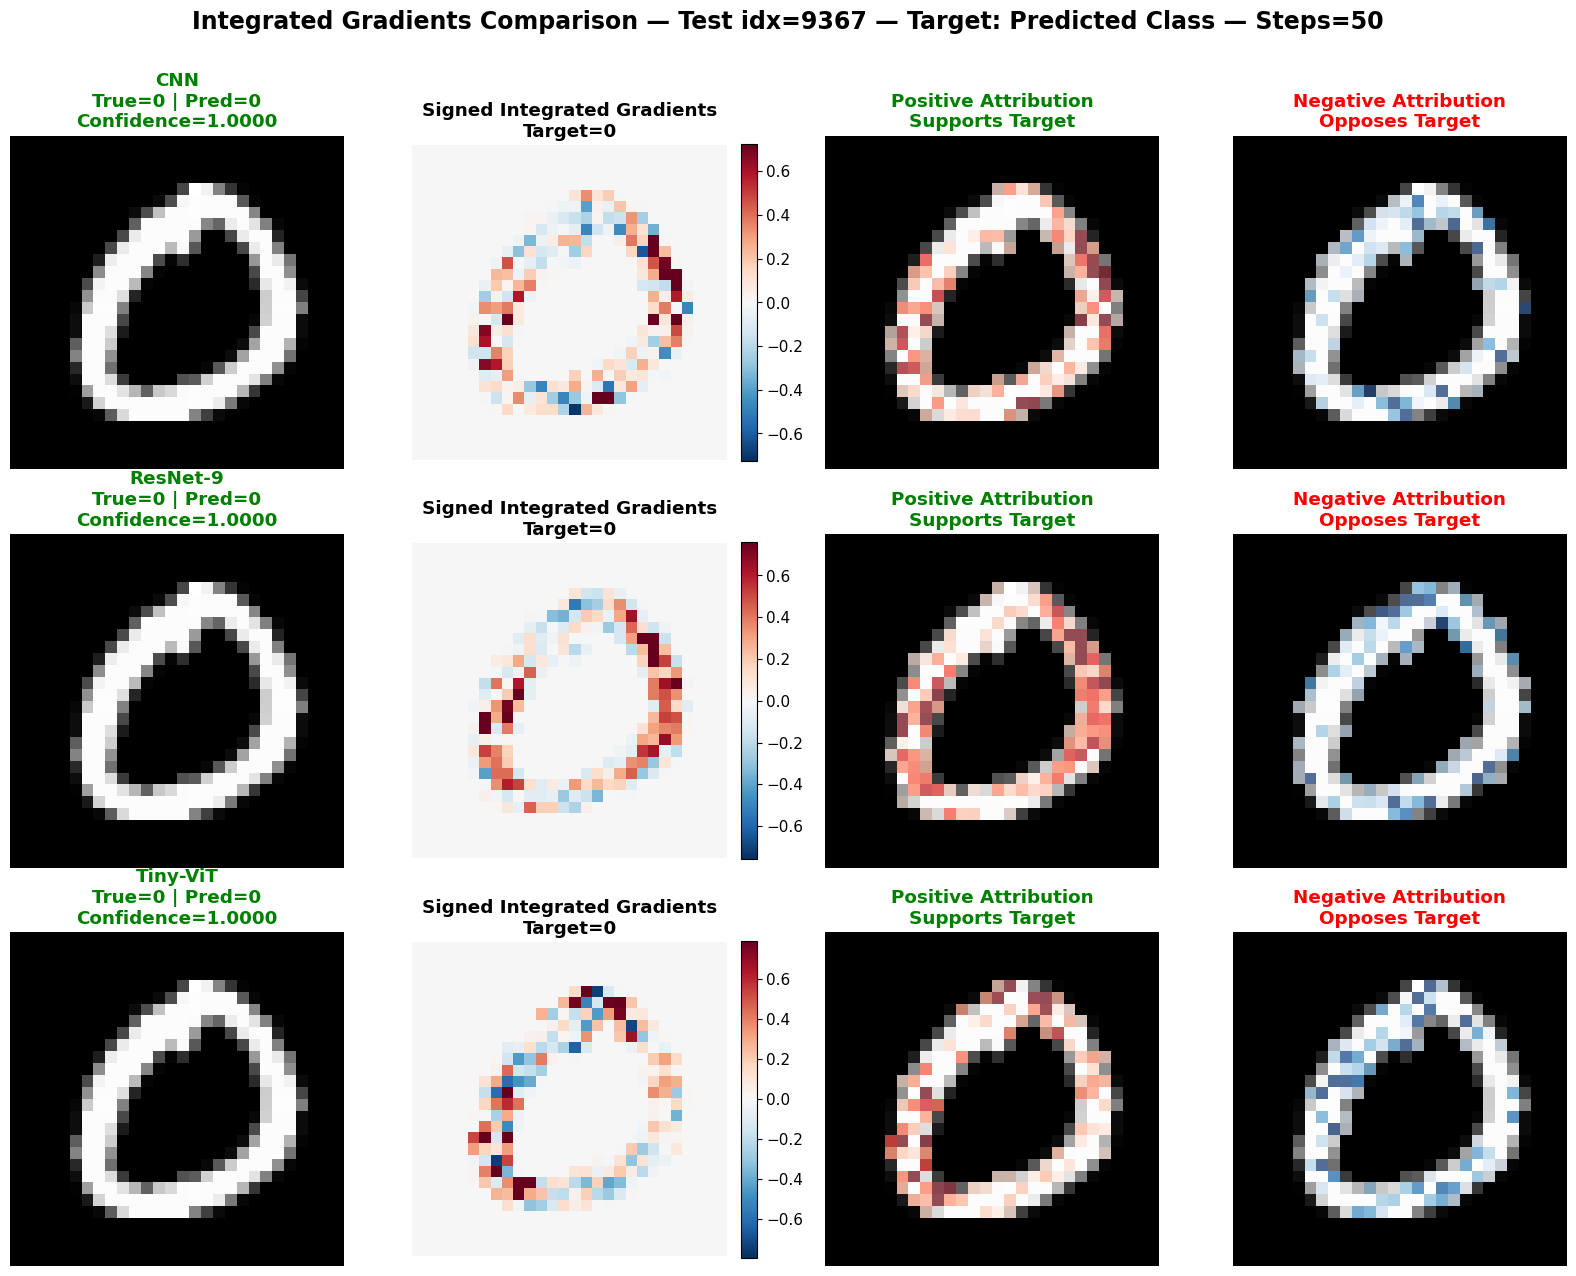

Selected error/disagreement sample: idx=3558, true=5
CNN        | idx=3558 | target=0 | logit difference=3.494519 | attribution sum=3.486351 | completeness error=0.008169
ResNet-9   | idx=3558 | target=5 | logit difference=8.451767 | attribution sum=8.269995 | completeness error=0.181772
Tiny-ViT   | idx=3558 | target=0 | logit difference=3.350291 | attribution sum=3.344093 | completeness error=0.006198


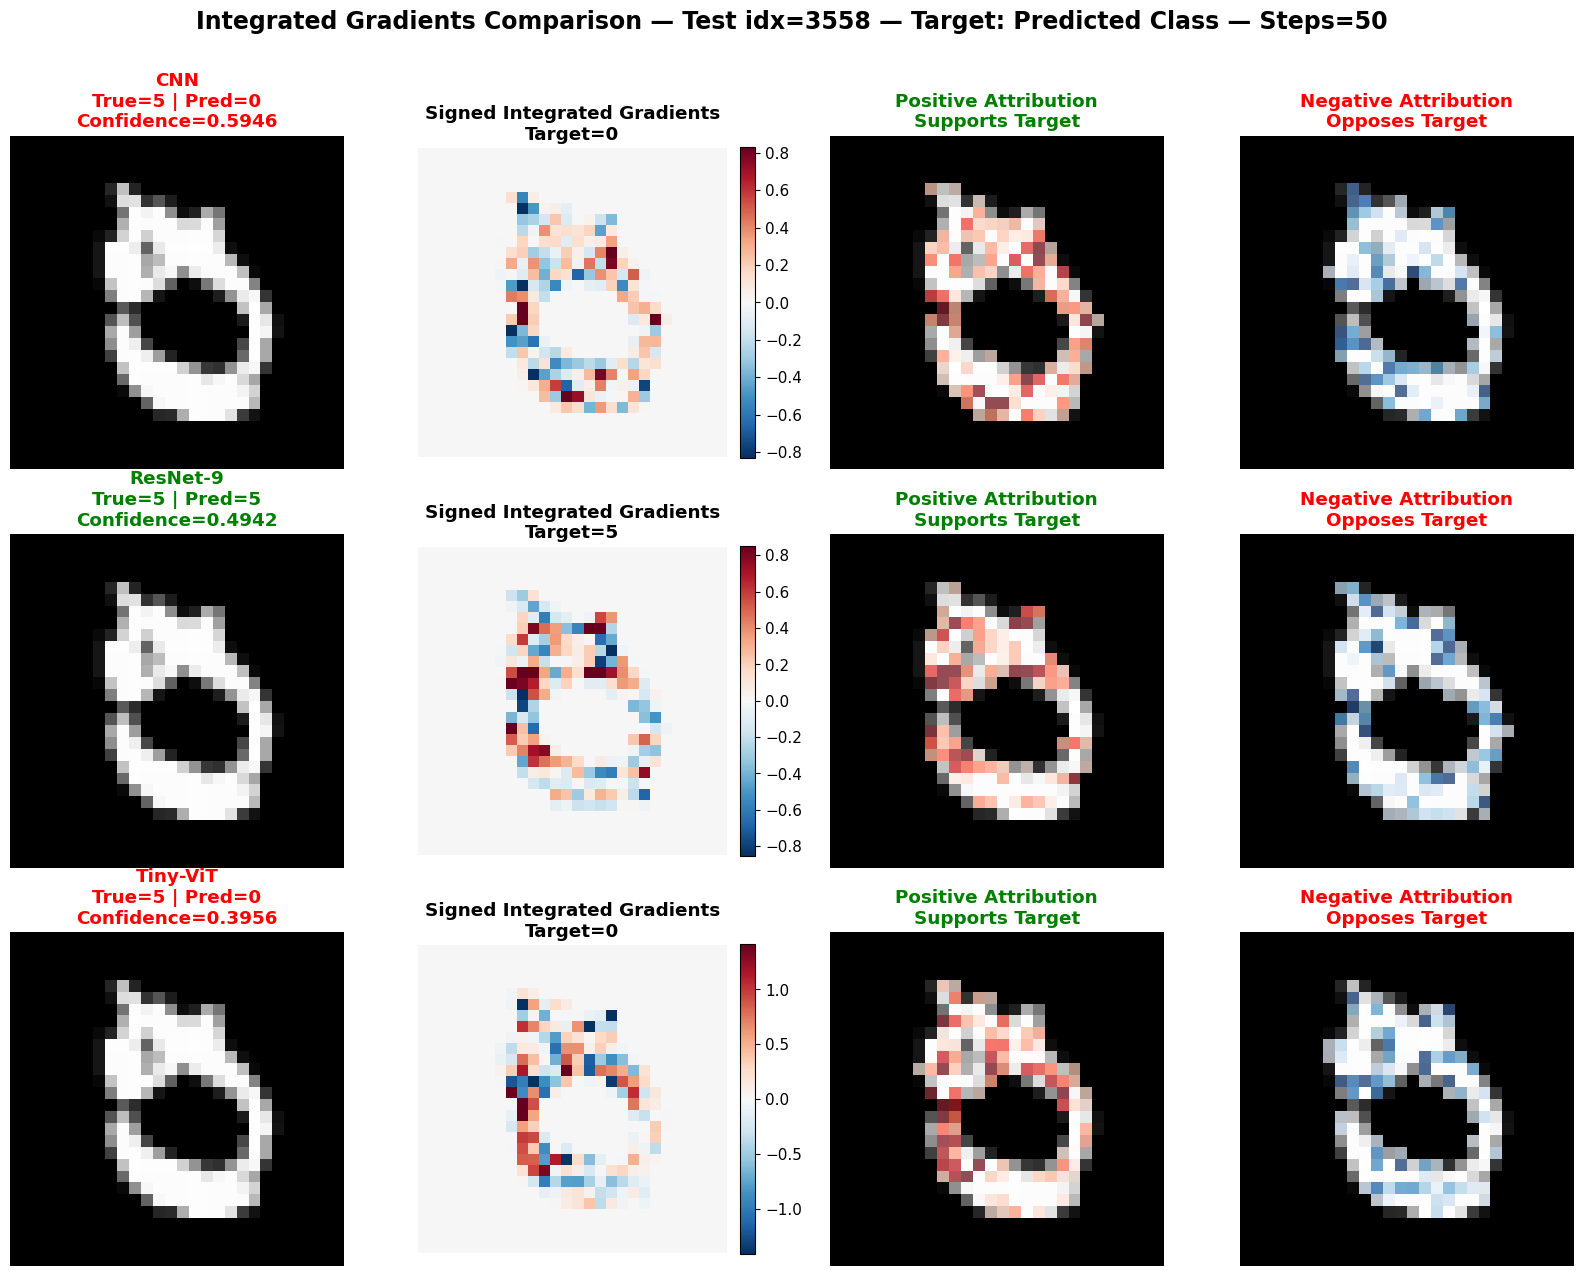

In [69]:
# @title
ig_correct_idx = select_dl_xai_index(
    "high_confidence_correct",
    fallback_category="low_confidence"
)

ig_error_idx = select_dl_xai_index(
    "model_disagreement",
    fallback_category="misclassified"
)

print(
    f"Selected correct sample: idx={ig_correct_idx}, "
    f"true={y_test[ig_correct_idx]}"
)

ig_correct_results = plot_integrated_gradients_comparison(
    test_index=ig_correct_idx,
    target_mode="predicted",
    steps=50
)

print(
    f"Selected error/disagreement sample: idx={ig_error_idx}, "
    f"true={y_test[ig_error_idx]}"
)

ig_error_predicted_results = plot_integrated_gradients_comparison(
    test_index=ig_error_idx,
    target_mode="predicted",
    steps=50
)

## 5.5 CNN and ResNet Grad-CAM

In [70]:
# @title
GRADCAM_LAYERS = {
    "CNN": "target_activation",
    "ResNet-9": globals().get("RESNET_GRADCAM_LAYER", "res_block_2_out"),
}


def compute_gradcam(model_name, image, target_class=None):
    model = DL_MODELS[model_name]
    logit_model = DL_LOGIT_MODELS[model_name]
    target_layer_name = GRADCAM_LAYERS[model_name]

    image_batch = prepare_xai_image(image)
    image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

    prediction_info = get_dl_prediction(model_name, image)
    prediction = prediction_info["prediction"]
    confidence = prediction_info["confidence"]

    if target_class is None:
        target_class = prediction

    target_class = int(target_class)
    target_layer = model.get_layer(target_layer_name)

    feature_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            target_layer.output,
            logit_model.output
        ]
    )

    with tf.GradientTape() as tape:
        feature_maps, logits = feature_model(
            image_tensor,
            training=False
        )
        target_score = logits[:, target_class]

    gradients = tape.gradient(target_score, feature_maps)

    if gradients is None:
        raise RuntimeError(
            f"Could not compute Grad-CAM gradients for {model_name}."
        )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    heatmap = tf.reduce_sum(
        feature_maps * channel_weights[:, None, None, :],
        axis=-1
    )

    heatmap = tf.nn.relu(heatmap)[0]

    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    heatmap = tf.image.resize(
        heatmap[..., None],
        (28, 28)
    ).numpy().squeeze()

    return {
        "model_name": model_name,
        "image": image_batch[0].squeeze(),
        "prediction": prediction,
        "confidence": confidence,
        "target_class": target_class,
        "target_layer": target_layer_name,
        "heatmap": heatmap,
    }

In [71]:
# @title
def plot_gradcam_comparison(test_index, target_mode="predicted"):
    image = X_test_cnn[test_index]
    true_label = int(y_test[test_index])

    model_names = ["CNN", "ResNet-9"]

    fig, axes = plt.subplots(
        len(model_names),
        3,
        figsize=(11, 7.5)
    )

    for row, model_name in enumerate(model_names):
        prediction_info = get_dl_prediction(model_name, image)
        prediction = prediction_info["prediction"]
        confidence = prediction_info["confidence"]

        if target_mode == "predicted":
            target_class = prediction
        elif target_mode == "true":
            target_class = true_label
        elif isinstance(target_mode, int):
            target_class = int(target_mode)
        else:
            raise ValueError(
                "target_mode must be 'predicted', 'true', or an integer."
            )

        result = compute_gradcam(
            model_name=model_name,
            image=image,
            target_class=target_class
        )

        title_color = (
            "green" if prediction == true_label else "red"
        )

        axes[row, 0].imshow(
            result["image"],
            cmap="gray"
        )
        axes[row, 0].set_title(
            f"{model_name}\n"
            f"True={true_label} | Pred={prediction}\n"
            f"Confidence={confidence:.4f}",
            color=title_color,
            fontweight="bold"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(
            result["heatmap"],
            cmap="jet",
            vmin=0,
            vmax=1
        )
        axes[row, 1].set_title(
            f"Grad-CAM\n"
            f"Target={target_class}\n"
            f"Layer={result['target_layer']}",
            fontweight="bold"
        )
        axes[row, 1].axis("off")

        axes[row, 2].imshow(
            result["image"],
            cmap="gray"
        )
        axes[row, 2].imshow(
            np.ma.masked_where(
                result["heatmap"] < 0.05,
                result["heatmap"]
            ),
            cmap="jet",
            alpha=0.6,
            vmin=0,
            vmax=1
        )
        axes[row, 2].set_title(
            "Grad-CAM Overlay",
            fontweight="bold"
        )
        axes[row, 2].axis("off")

    target_text = (
        "Predicted Class"
        if target_mode == "predicted"
        else "True Class"
        if target_mode == "true"
        else f"Class {target_mode}"
    )

    fig.suptitle(
        f"CNN vs ResNet-9 Grad-CAM\n"
        f"Test idx={test_index} | Target={target_text}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

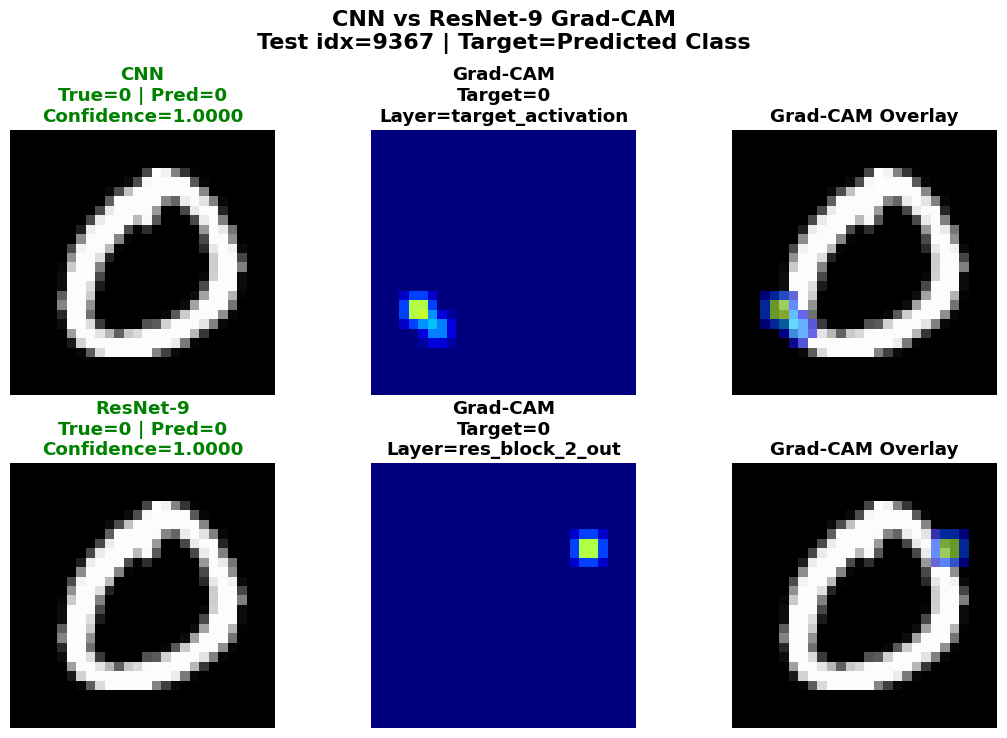

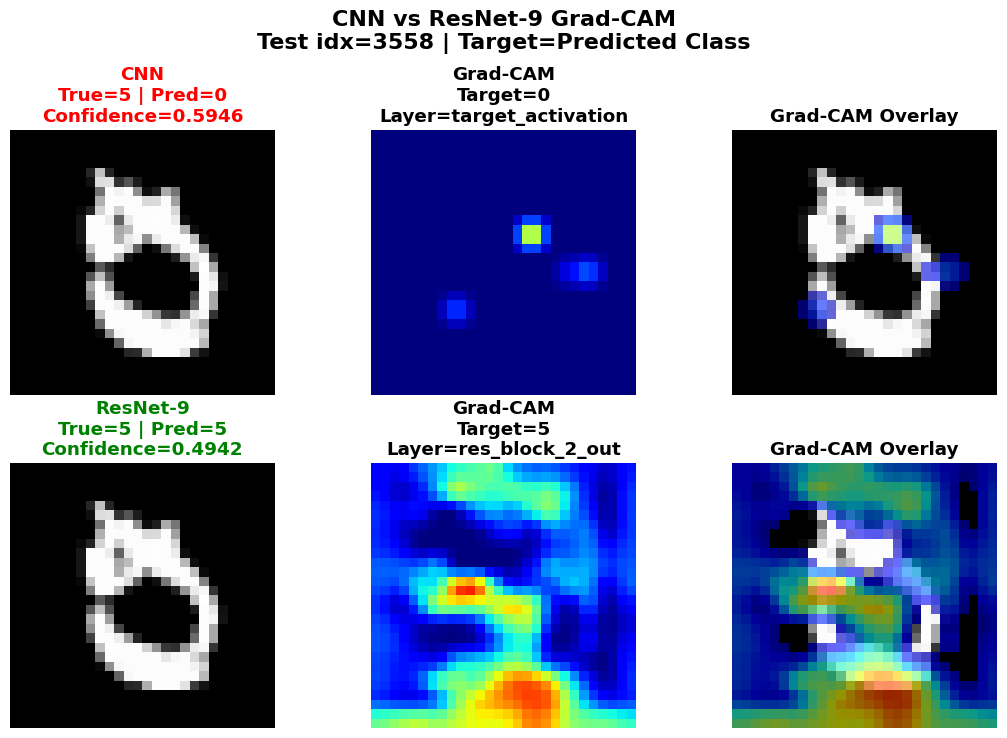

In [72]:
# @title
gradcam_correct_idx = select_dl_xai_index(
    "high_confidence_correct",
    fallback_category="low_confidence"
)

gradcam_error_idx = select_dl_xai_index(
    "model_disagreement",
    fallback_category="misclassified"
)

plot_gradcam_comparison(
    gradcam_correct_idx,
    target_mode="predicted"
)

plot_gradcam_comparison(
    gradcam_error_idx,
    target_mode="predicted"
)

## 5.6 Tiny-ViT Attention Visualization

Attention rollout visualizes patch interactions across Transformer blocks. Attention weights are not necessarily equivalent to causal or class-specific explanations.


In [73]:
# @title
# Attention Score
VIT_MODEL = DL_MODELS["Tiny-ViT"]


def get_vit_attention_layers(model=VIT_MODEL):
    layers = [
        layer for layer in model.layers
        if isinstance(layer, tf.keras.layers.MultiHeadAttention)
    ]

    if not layers:
        raise RuntimeError(
            "Không tìm thấy MultiHeadAttention layer trong Tiny-ViT."
        )

    return layers


VIT_ATTENTION_LAYERS = get_vit_attention_layers()

print(
    "Attention layers:",
    [layer.name for layer in VIT_ATTENTION_LAYERS]
)


def extract_vit_attention_scores(image):
    image_batch = prepare_xai_image(image)
    image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

    attention_scores = []

    for attention_layer in VIT_ATTENTION_LAYERS:
        input_extractor = tf.keras.Model(
            inputs=VIT_MODEL.inputs,
            outputs=attention_layer.input
        )

        layer_inputs = input_extractor(
            image_tensor,
            training=False
        )

        if not isinstance(layer_inputs, (list, tuple)):
            layer_inputs = [layer_inputs]

        query = layer_inputs[0]
        value = layer_inputs[1] if len(layer_inputs) > 1 else query
        key = layer_inputs[2] if len(layer_inputs) > 2 else value

        _, scores = attention_layer(
            query=query,
            value=value,
            key=key,
            return_attention_scores=True,
            training=False
        )

        attention_scores.append(scores.numpy()[0])

    return attention_scores

Attention layers: ['multi_head_attention_10', 'multi_head_attention_11']


In [74]:
# @title
# Attention Rollout
def compute_attention_rollout(image):
    scores_per_layer = extract_vit_attention_scores(image)

    rollout = None
    layer_maps = []

    for scores in scores_per_layer:
        attention = scores.mean(axis=0)

        attention += np.eye(
            attention.shape[0],
            dtype=np.float32
        )

        attention /= attention.sum(
            axis=-1,
            keepdims=True
        )

        rollout = (
            attention
            if rollout is None
            else attention @ rollout
        )

        token_importance = rollout.mean(axis=0)

        grid_size = int(np.sqrt(len(token_importance)))

        if grid_size ** 2 != len(token_importance):
            raise ValueError(
                f"Token count {len(token_importance)} "
                "cannot be reshaped into a square grid."
            )

        token_map = token_importance.reshape(
            grid_size,
            grid_size
        )

        token_map -= token_map.min()

        if token_map.max() > 0:
            token_map /= token_map.max()

        token_map = tf.image.resize(
            token_map[..., np.newaxis],
            (28, 28),
            method="bilinear"
        ).numpy().squeeze()

        layer_maps.append(token_map)

    return {
        "attention_scores": scores_per_layer,
        "layer_maps": layer_maps,
        "rollout_map": layer_maps[-1],
    }

In [75]:
# @title
# Compare through each Transformer block
def plot_vit_layer_rollout(test_index):
    image = X_test_cnn[test_index]
    result = compute_attention_rollout(image)

    layer_maps = result["layer_maps"]
    n_layers = len(layer_maps)

    fig, axes = plt.subplots(
        1,
        n_layers + 2,
        figsize=(4 * (n_layers + 2), 4)
    )

    axes[0].imshow(image.squeeze(), cmap="gray")
    axes[0].set_title("Original", fontweight="bold")
    axes[0].axis("off")

    for index, layer_map in enumerate(layer_maps):
        axes[index + 1].imshow(
            layer_map,
            cmap="jet",
            vmin=0,
            vmax=1
        )

        axes[index + 1].set_title(
            f"Rollout after Block {index + 1}",
            fontweight="bold"
        )

        axes[index + 1].axis("off")

    axes[-1].imshow(image.squeeze(), cmap="gray")
    axes[-1].imshow(
        np.ma.masked_where(
            result["rollout_map"] < 0.05,
            result["rollout_map"]
        ),
        cmap="jet",
        alpha=0.6,
        vmin=0,
        vmax=1
    )

    axes[-1].set_title(
        "Final Overlay",
        fontweight="bold"
    )
    axes[-1].axis("off")

    fig.suptitle(
        f"Tiny-ViT Layer-wise Attention Rollout — idx={test_index}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    return result

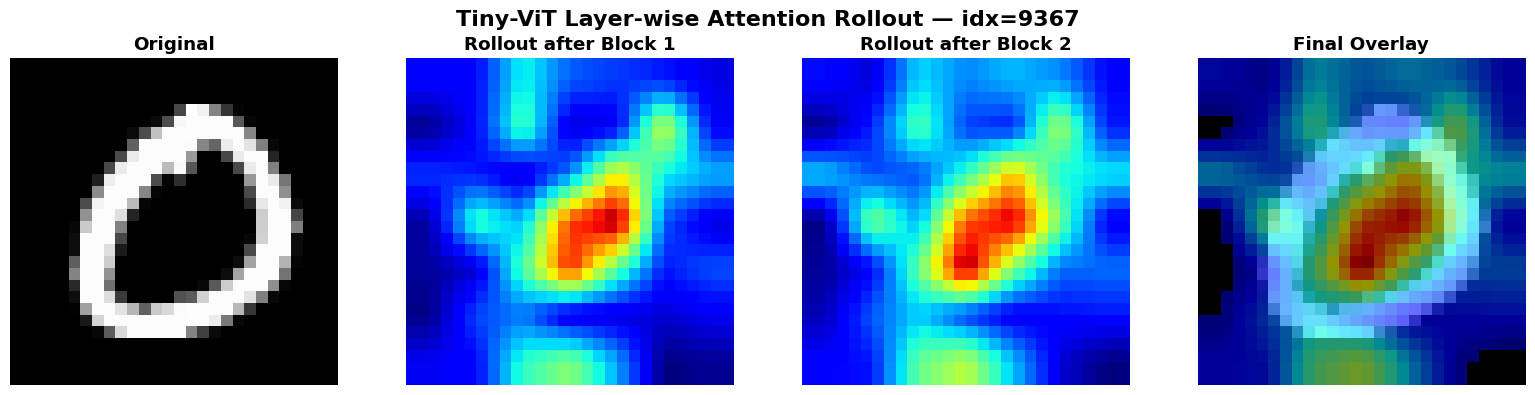

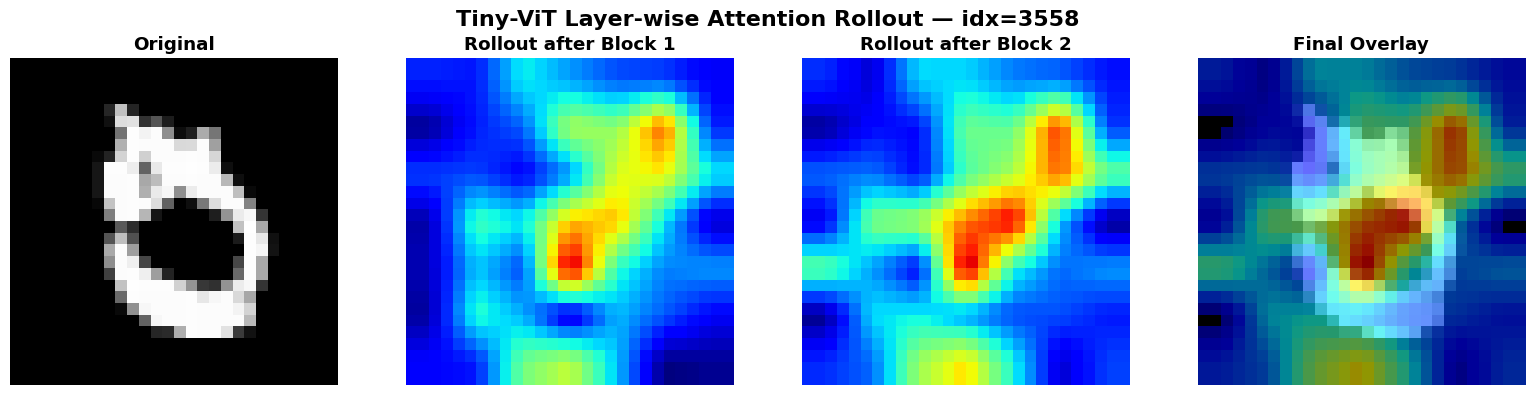

In [76]:
# @title
# Visualize layer-wise attention rollout
vit_attention_correct_idx = select_dl_xai_index(
    "high_confidence_correct",
    fallback_category="low_confidence"
)

vit_attention_error_idx = select_dl_xai_index(
    "model_disagreement",
    fallback_category="misclassified"
)

vit_correct_rollout = plot_vit_layer_rollout(
    vit_attention_correct_idx
)

vit_error_rollout = plot_vit_layer_rollout(
    vit_attention_error_idx
)


## 5.7 Cross-Model Error Analysis

In [77]:
# @title
def plot_cross_model_error(test_index, steps=32):
    image = X_test_cnn[test_index]
    true_label = int(y_test[test_index])

    fig, axes = plt.subplots(
        len(DL_MODEL_NAMES), 3,
        figsize=(12, 4 * len(DL_MODEL_NAMES))
    )

    for row, model_name in enumerate(DL_MODEL_NAMES):
        info = get_dl_prediction(model_name, image)
        pred, conf = info["prediction"], info["confidence"]

        pred_ig = compute_integrated_gradients(
            model_name, image,
            target_class=pred,
            steps=steps
        )

        true_ig = (
            pred_ig if pred == true_label
            else compute_integrated_gradients(
                model_name, image,
                target_class=true_label,
                steps=steps
            )
        )

        axes[row, 0].imshow(image.squeeze(), cmap="gray")
        axes[row, 0].set_title(
            f"{model_name}\nTrue={true_label} | Pred={pred}\n"
            f"Confidence={conf:.4f}",
            color="green" if pred == true_label else "red",
            fontweight="bold"
        )
        axes[row, 0].axis("off")

        for ax, result, title in [
            (axes[row, 1], pred_ig, f"Predicted Class: {pred}"),
            (axes[row, 2], true_ig, f"True Class: {true_label}")
        ]:
            ax.imshow(image.squeeze(), cmap="gray")

            attribution = np.ma.masked_where(
                result["normalized_positive"] < 0.05,
                result["normalized_positive"]
            )

            ax.imshow(
                attribution,
                cmap="Reds",
                alpha=0.7,
                vmin=0,
                vmax=1
            )
            ax.set_title(title, fontweight="bold")
            ax.axis("off")

    fig.suptitle(
        f"Cross-Model Error Analysis — Test idx={test_index}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

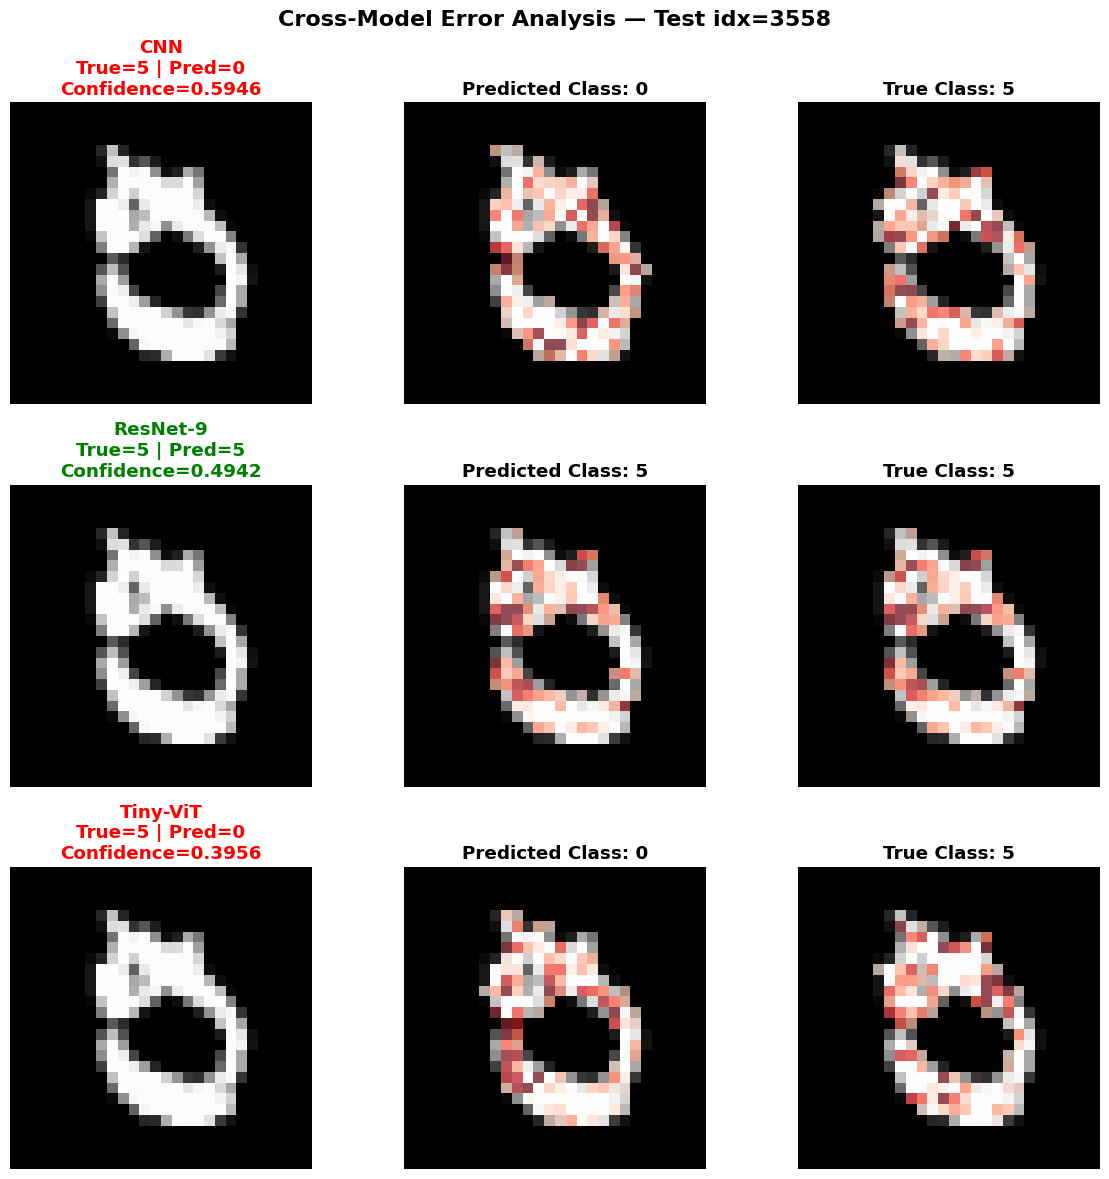

In [78]:
# @title
cross_model_error_idx = select_dl_xai_index(
    "model_disagreement",
    fallback_category="misclassified"
)

plot_cross_model_error(cross_model_error_idx)

## 5.8 Explanation Faithfulness Demonstration


The deletion test is demonstrated on one representative high-confidence sample. The results illustrate explanation behavior for this case and should not be interpreted as dataset-wide evidence.


In [79]:
# @title
def target_probability(model_name, image, target_class):
    return float(
        DL_MODELS[model_name](
            prepare_xai_image(image),
            training=False
        ).numpy()[0, target_class]
    )


def evaluate_faithfulness(
    test_index,
    fractions=(0, 0.05, 0.10, 0.20, 0.30),
    steps=32,
    random_runs=5
):
    image = X_test_cnn[test_index].copy()
    rng = np.random.default_rng(42)
    rows = []

    for model_name in DL_MODEL_NAMES:
        prediction = get_dl_prediction(
            model_name, image
        )["prediction"]

        ig = compute_integrated_gradients(
            model_name,
            image,
            target_class=prediction,
            steps=steps
        )

        attribution = ig["absolute_attribution"]
        order = np.argsort(attribution.ravel())[::-1]

        foreground = image.squeeze() > 0.1
        total_attr = attribution.sum() + 1e-12

        foreground_ratio = float(
            attribution[foreground].sum() / total_attr
        )

        baseline_probability = target_probability(
            model_name, image, prediction
        )

        for fraction in fractions:
            k = int(fraction * image.size)

            guided = image.copy().reshape(-1)
            guided[order[:k]] = 0
            guided = guided.reshape(image.shape)

            guided_probability = target_probability(
                model_name, guided, prediction
            )

            random_probabilities = []

            for _ in range(random_runs):
                random_masked = image.copy().reshape(-1)

                if k > 0:
                    random_indices = rng.choice(
                        image.size,
                        size=k,
                        replace=False
                    )
                    random_masked[random_indices] = 0

                random_probabilities.append(
                    target_probability(
                        model_name,
                        random_masked.reshape(image.shape),
                        prediction
                    )
                )

            rows.append({
                "model": model_name,
                "fraction": fraction,
                "foreground_ratio": foreground_ratio,
                "guided_drop":
                    baseline_probability - guided_probability,
                "random_drop":
                    baseline_probability - np.mean(random_probabilities)
            })

    return pd.DataFrame(rows)

In [80]:
# @title
def plot_faithfulness(results):
    fig, axes = plt.subplots(
        1, len(DL_MODEL_NAMES),
        figsize=(15, 4)
    )

    for ax, model_name in zip(axes, DL_MODEL_NAMES):
        subset = results[
            results["model"] == model_name
        ]

        percentages = subset["fraction"] * 100

        ax.plot(
            percentages,
            subset["guided_drop"],
            marker="o",
            label="Attribution-guided"
        )

        ax.plot(
            percentages,
            subset["random_drop"],
            marker="o",
            linestyle="--",
            label="Random"
        )

        ax.set_title(model_name, fontweight="bold")
        ax.set_xlabel("Removed pixels (%)")
        ax.set_ylabel("Confidence drop")
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(
        "Explanation Faithfulness: Guided vs Random Deletion",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

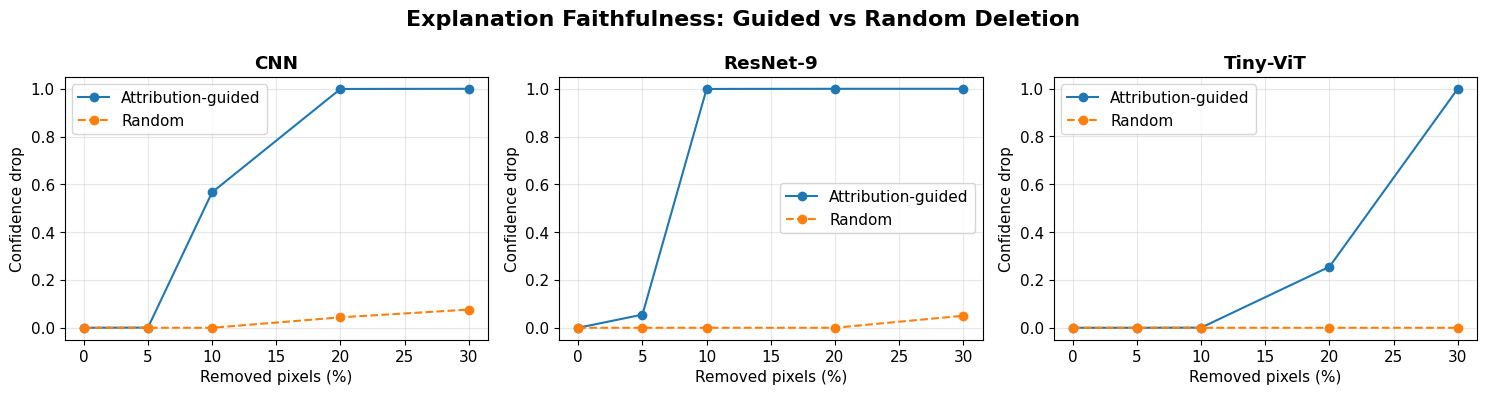

In [81]:
# @title
faithfulness_idx = select_dl_xai_index(
    "high_confidence_correct",
    fallback_category="low_confidence"
)

faithfulness_results = evaluate_faithfulness(
    faithfulness_idx
)

plot_faithfulness(faithfulness_results)

In [82]:
# @title
faithfulness_summary = (
    faithfulness_results[
        faithfulness_results["fraction"] == 0.20
    ][
        [
            "model",
            "foreground_ratio",
            "guided_drop",
            "random_drop"
        ]
    ]
    .reset_index(drop=True)
)

faithfulness_summary["faithfulness_gain"] = (
    faithfulness_summary["guided_drop"]
    - faithfulness_summary["random_drop"]
)

display(
    faithfulness_summary.style.format({
        "foreground_ratio": "{:.3f}",
        "guided_drop": "{:.3f}",
        "random_drop": "{:.3f}",
        "faithfulness_gain": "{:.3f}"
    })
)

faithfulness_all_positive = bool(
    (faithfulness_summary["faithfulness_gain"] > 0).all()
)

if faithfulness_all_positive:
    print(
        "At 20% deletion, attribution-guided deletion caused a larger "
        "confidence reduction than random deletion for every DL model."
    )
else:
    print(
        "At 20% deletion, attribution-guided deletion did not consistently "
        "cause a larger confidence reduction than random deletion."
    )


,model,foreground_ratio,guided_drop,random_drop,faithfulness_gain
0,CNN,0.990,0.999,0.044,0.955
1,ResNet-9,0.992,1.000,0.000,1.000
2,Tiny-ViT,0.996,0.255,0.000,0.255


At 20% deletion, attribution-guided deletion caused a larger confidence reduction than random deletion for every DL model.


## 5.9 Findings and Limitations

### Key findings

- KNN predictions are interpretable through the nearest training samples, while ambiguous digits may produce neighbors from competing classes.
- Random Forest global importance is concentrated mainly around central stroke regions.
- SVM occlusion identifies stroke segments that influence the nonlinear decision score.
- CNN and ResNet-9 Grad-CAM maps highlight spatial stroke structures.
- Tiny-ViT attention rollout shows how information is distributed across image patches and Transformer blocks.
- Integrated Gradients provides a consistent class-specific attribution method for CNN, ResNet-9, and Tiny-ViT.
- Misclassified samples often contain visual patterns shared by multiple digit classes.
- For the selected faithfulness sample, attribution-guided deletion caused a larger confidence reduction than random deletion.

### Limitations

- MNIST consists of centered grayscale images with simple backgrounds, making explanation easier than real-world image classification.
- Most qualitative results are based on a small number of representative samples.
- Vanilla Saliency may be noisy and sensitive to local gradients.
- Grad-CAM resolution depends on the spatial resolution of the selected convolutional feature map.
- Attention weights describe token interactions but are not necessarily causal or class-specific explanations.
- Integrated Gradients depends on the selected baseline; this notebook uses a black image.
- Occlusion results depend on patch size, stride, and replacement value.
- The faithfulness test is demonstrated on selected samples rather than evaluated across the complete test set.
